In [2]:
import awkward as ak
from coffea import processor
from coffea.nanoevents.methods import candidate
import uproot
from coffea.nanoevents import NanoEventsFactory, BaseSchema
import json
import hist
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
import pickle, glob
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)


In [3]:
import awkward as ak
import hist
from coffea import processor


class MyProcessor(processor.ProcessorABC):

    def __init__(self):
        pass

    def process(self, events):
        dataset = events.metadata["dataset"]

        # Flatten jagged fields directly to 1D arrays for histogram filling
        # Using ak.flatten handles variable numbers of objects per event safely
        scores = ak.flatten(events.classifier_score, axis=None)
        mass_raw = ak.flatten(events.mass_A_raw, axis=None)
        mass_a = ak.flatten(events.mass_A, axis=None)
        pt = ak.flatten(events.jetpT, axis=None)

        # ---------------------------------------------------------------------
        # Histograms
        # ---------------------------------------------------------------------

        # 1. Classifier Score
        h_classifier = hist.Hist(
            hist.axis.Regular(
                30, 0.0, 1.0, name="score", label="Classifier Score"
            ),
            storage=hist.storage.Double(),
        )
        h_classifier.fill(score=scores)

        # 2. Raw A Mass
        h_mass_raw = hist.Hist(
            hist.axis.Regular(
                63, 0.0, 25.0, name="mass", label=r"Raw $m_{A}$ [GeV]"
            ),
            storage=hist.storage.Double(),
        )
        h_mass_raw.fill(mass=mass_raw)


        # 3. A Mass
        h_mass = hist.Hist(
            hist.axis.Regular(
                63, 0.0, 25.0, name="mass", label=r"$m_{A}$ [GeV]"
            ),
            storage=hist.storage.Double(),
        )
        h_mass.fill(mass=mass_a)

        # 4. Jet pT
        h_jet_pt = hist.Hist(
            hist.axis.Regular(
                50, 0.0, 300.0, name="pt", label=r"Jet $p_{T}$ [GeV]"
            ),
            storage=hist.storage.Double(),
        )
        h_jet_pt.fill(pt=pt)

        # ---------------------------------------------------------------------
        # Accumulator Output
        # ---------------------------------------------------------------------
        return {
            dataset: {
                "entries": len(events),
                "Classifier_score": h_classifier,
                "mass_A_raw": h_mass_raw,
                "mass_A": h_mass,
                "jetpT": h_jet_pt,
            }
        }

    def postprocess(self, accumulator):
        return accumulator

In [44]:
with open("Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)


with open("Background_Wjets_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_Wjets_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_TTBar_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_TTBar_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_QCD_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_QCD_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)


with open("list_Ntuples_data_miniAOD_Aug_5_2026_inference_root_to_root.json", "r") as fin:
    data_miniAOD_Aug_5_2026_inference_root_to_root = json.load(fin)


fileset = {
    'Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15


    ,'Background_Wjets_with_mass_classifier_infernce_miniAOD_June15': Background_Wjets_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15': Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15': Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_TTBar_with_mass_classifier_infernce_miniAOD_June15': Background_TTBar_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_QCD_with_mass_classifier_infernce_miniAOD_June15': Background_QCD_with_mass_classifier_infernce_miniAOD_June15
    ,'data_miniAOD_Aug_5_2026_inference_root_to_root':data_miniAOD_Aug_5_2026_inference_root_to_root



}




In [45]:
futures_run = processor.Runner(
    executor = processor.FuturesExecutor(compression=None, workers=4),
    schema=BaseSchema,
    # maxchunks=2,
)

out = futures_run(
    fileset,
    treename='/fevt/RHTree',
    # "RHTree",
    processor_instance=MyProcessor()
)
with open('inference_data_signal_background_mass_clssifier_score.pkl', 'wb') as f:
    pickle.dump(out, f)

out

Output()

Output()

{'data_miniAOD_Aug_5_2026_inference_root_to_root': {'entries': 211970,
  'Classifier_score': Hist(Regular(30, 0, 1, name='score', label='Classifier Score'), storage=Double()) # Sum: 367046.0 (367168.0 with flow),
  'mass_A_raw': Hist(Regular(63, 0, 25, name='mass', label='Raw $m_{A}$ [GeV]'), storage=Double()) # Sum: 366441.0 (367168.0 with flow),
  'mass_A': Hist(Regular(63, 0, 25, name='mass', label='$m_{A}$ [GeV]'), storage=Double()) # Sum: 357866.0 (367168.0 with flow),
  'jetpT': Hist(Regular(50, 0, 300, name='pt', label='Jet $p_{T}$ [GeV]'), storage=Double()) # Sum: 359245.0 (367168.0 with flow)},
 'Background_QCD_with_mass_classifier_infernce_miniAOD_June15': {'entries': 62125,
  'Classifier_score': Hist(Regular(30, 0, 1, name='score', label='Classifier Score'), storage=Double()) # Sum: 107403.0 (107409.0 with flow),
  'mass_A_raw': Hist(Regular(63, 0, 25, name='mass', label='Raw $m_{A}$ [GeV]'), storage=Double()) # Sum: 104203.0 (107409.0 with flow),
  'mass_A': Hist(Regular(63

In [46]:
with open('inference_data_signal_background_mass_clssifier_score.pkl', 'rb') as f:
    out = pickle.load(f)
out

{'data_miniAOD_Aug_5_2026_inference_root_to_root': {'entries': 211970,
  'Classifier_score': Hist(Regular(30, 0, 1, name='score', label='Classifier Score'), storage=Double()) # Sum: 367046.0 (367168.0 with flow),
  'mass_A_raw': Hist(Regular(63, 0, 25, name='mass', label='Raw $m_{A}$ [GeV]'), storage=Double()) # Sum: 366441.0 (367168.0 with flow),
  'mass_A': Hist(Regular(63, 0, 25, name='mass', label='$m_{A}$ [GeV]'), storage=Double()) # Sum: 357866.0 (367168.0 with flow),
  'jetpT': Hist(Regular(50, 0, 300, name='pt', label='Jet $p_{T}$ [GeV]'), storage=Double()) # Sum: 359245.0 (367168.0 with flow)},
 'Background_QCD_with_mass_classifier_infernce_miniAOD_June15': {'entries': 62125,
  'Classifier_score': Hist(Regular(30, 0, 1, name='score', label='Classifier Score'), storage=Double()) # Sum: 107403.0 (107409.0 with flow),
  'mass_A_raw': Hist(Regular(63, 0, 25, name='mass', label='Raw $m_{A}$ [GeV]'), storage=Double()) # Sum: 104203.0 (107409.0 with flow),
  'mass_A': Hist(Regular(63

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f6b28f00650>, errorbar=None, legend_artist=None)]

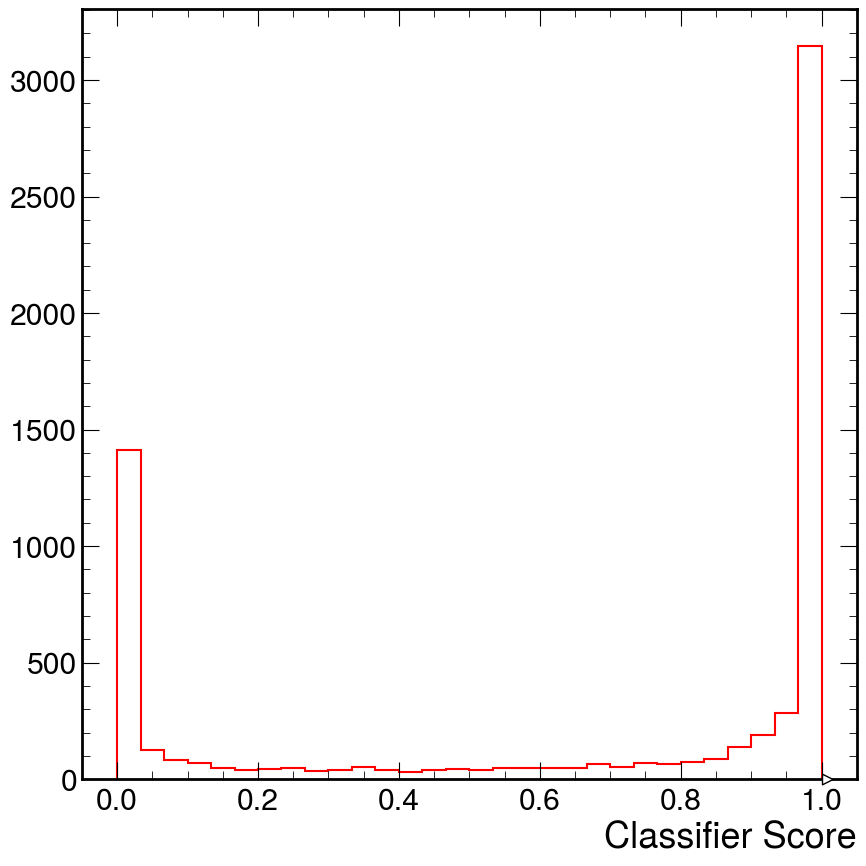

In [47]:
fig, ax = plt.subplots()
out["Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15"]["Classifier_score"].plot1d(ax=ax,histtype='step',color="r")
# out["train_mass"]["tau2_pt"].plot1d(ax=ax,histtype='step',color="b")
# # ax.set_yscale("log")
# ax.legend(title="pT Dist")
# hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)

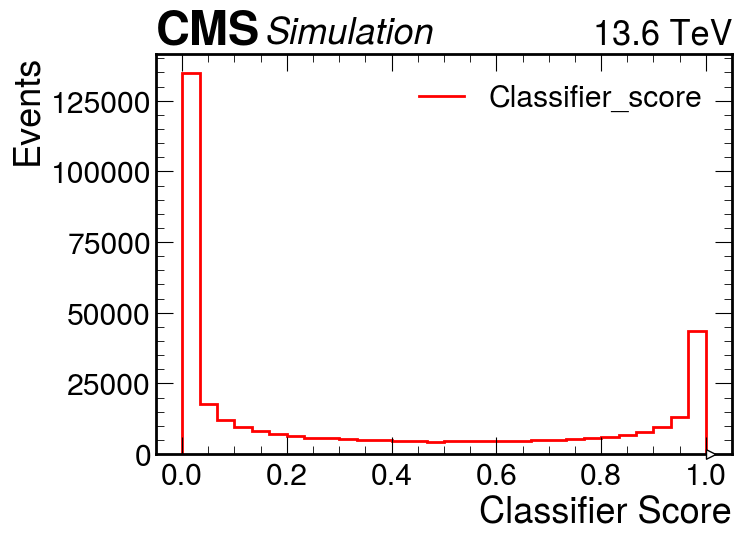

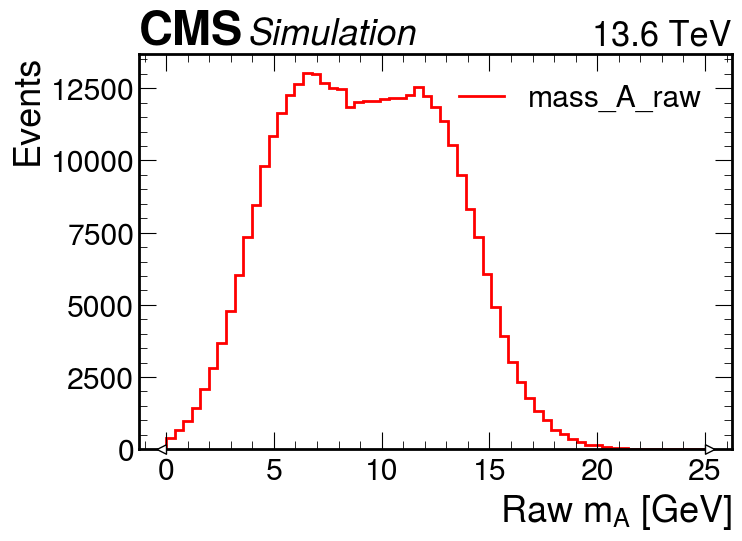

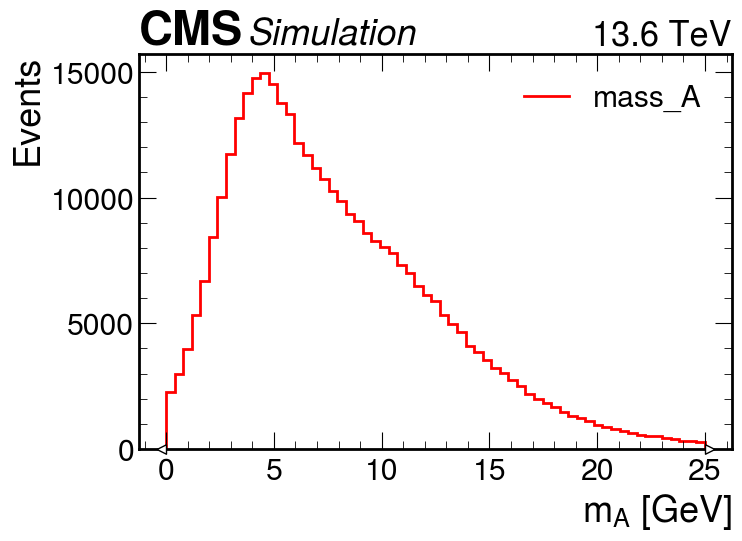

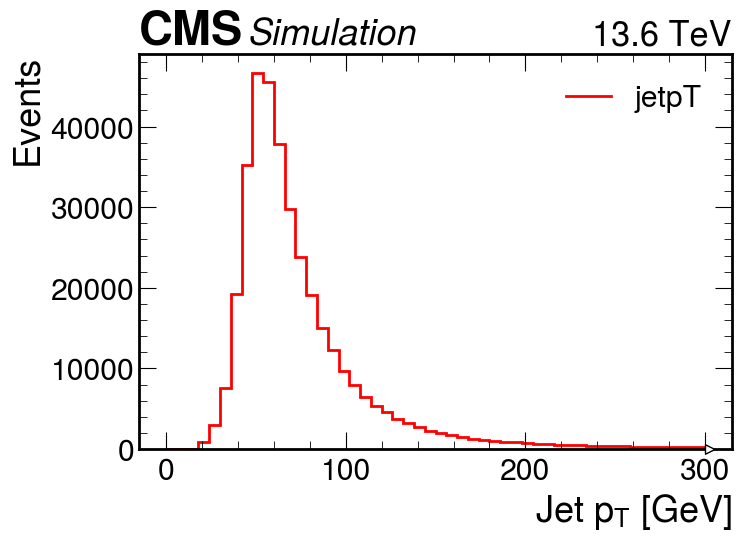

In [49]:


# Use standard High Energy Physics plotting style
plt.style.use(hep.style.CMS)

# Dataset key from your dictionary
dataset_name = "data_miniAOD_Aug_5_2026_inference_root_to_root"
dataset_output = out[dataset_name]

# Create an output directory for saving plots
os.makedirs("plots", exist_ok=True)

# Loop through all items in the dataset dictionary
for name, item in dataset_output.items():
    # Skip non-histogram metadata like 'entries'
    if not hasattr(item, "plot1d"):
        continue

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the histogram
    item.plot1d(ax=ax, histtype="step", color="red", linewidth=2, label=name)

    # Styling and annotations
    ax.set_ylabel("Events")
    ax.legend(loc="upper right")

    # Add HEP experiment label (e.g., CMS Private Work / Simulation)
    hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax)

    # Save and display
    plt.tight_layout()
    plt.savefig(f"plots/{name}.png", dpi=300)
    plt.show()
    plt.close(fig)

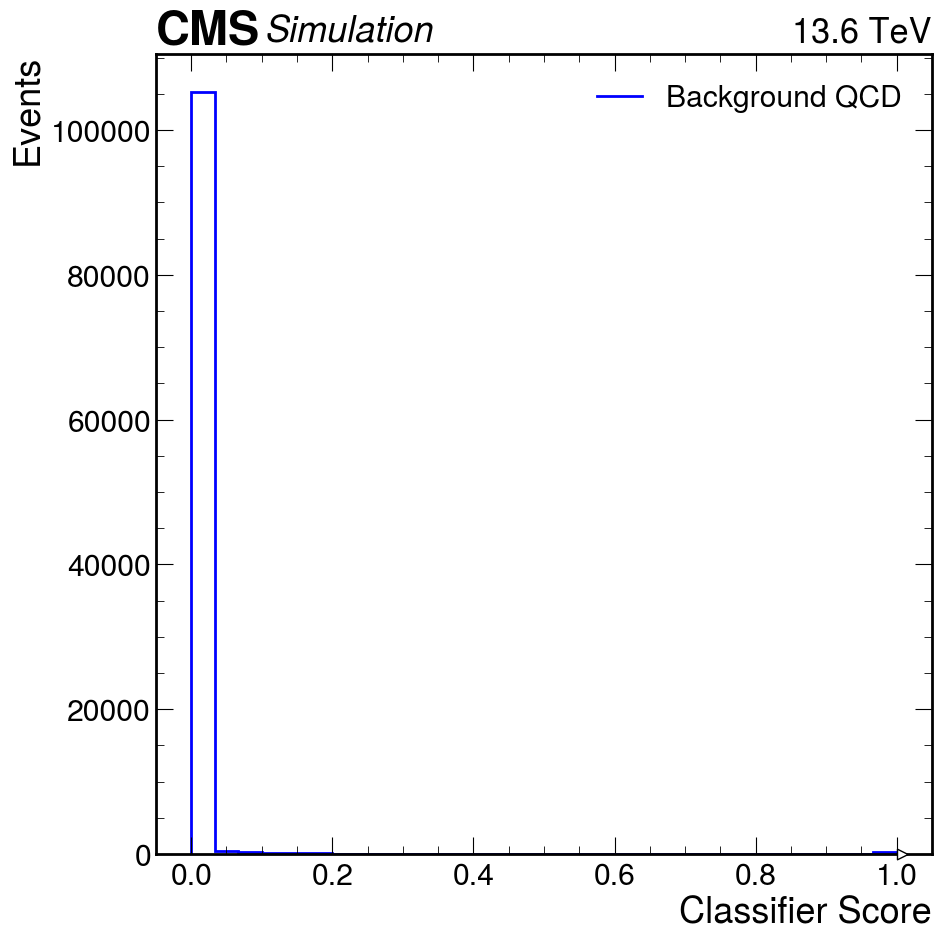

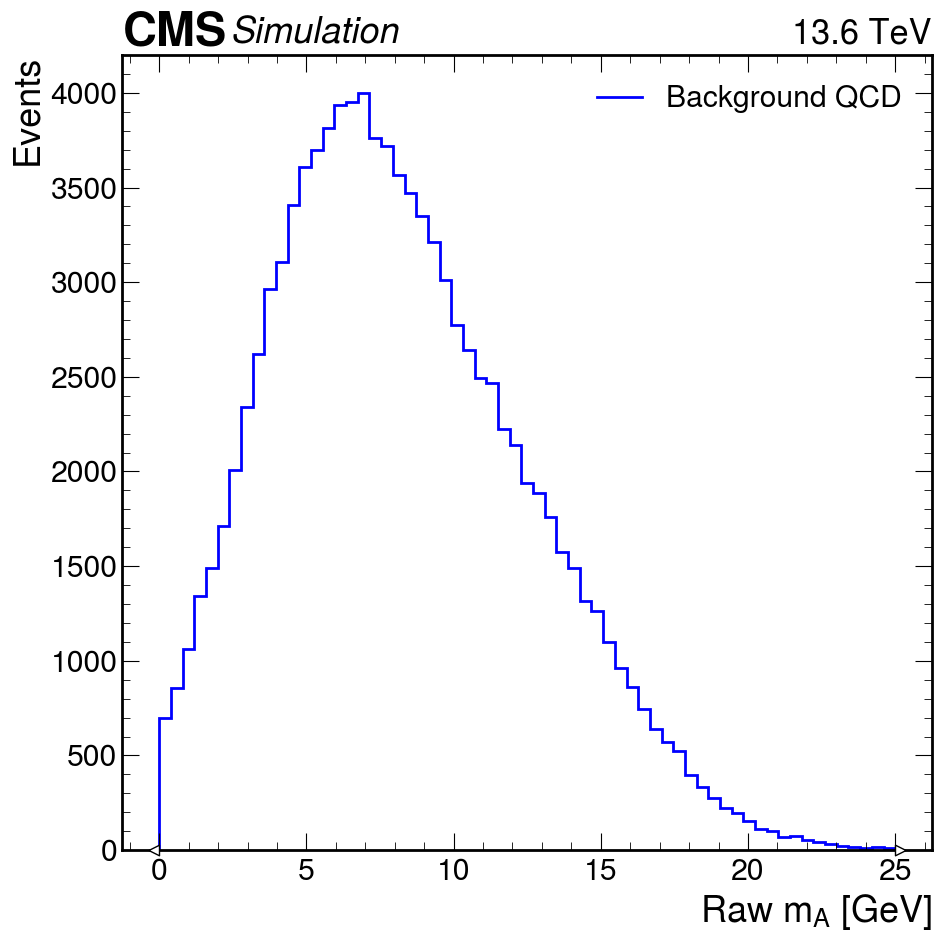

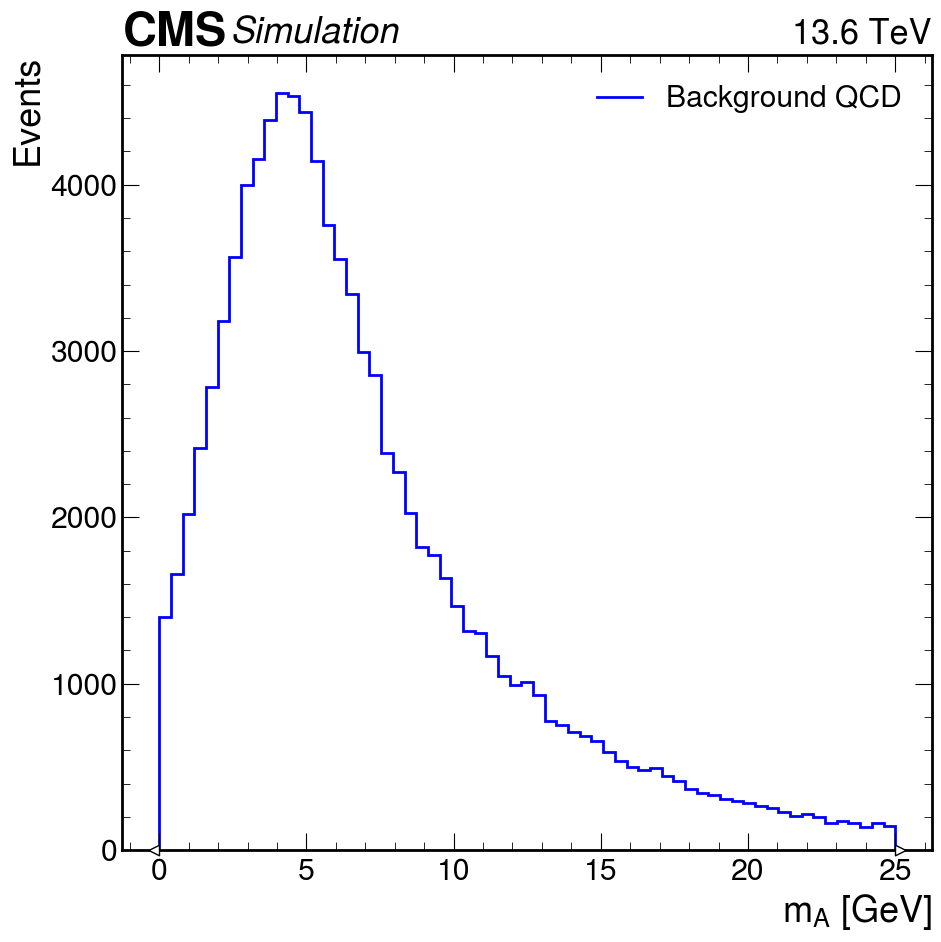

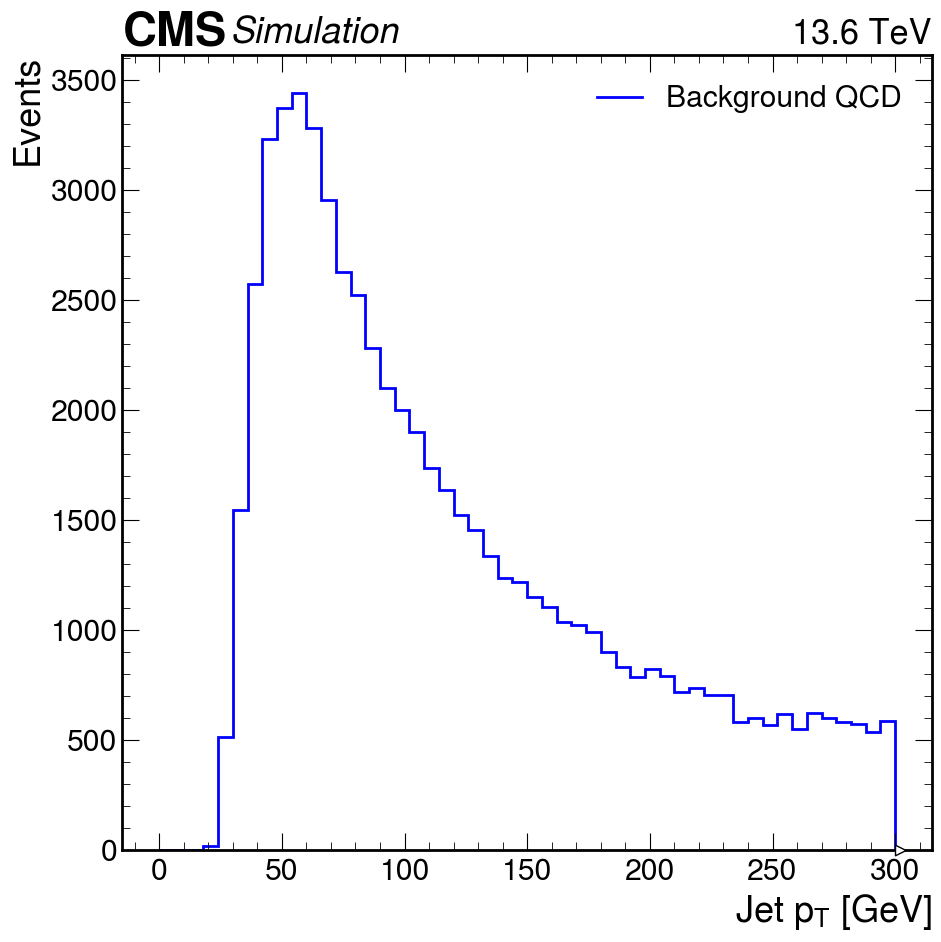

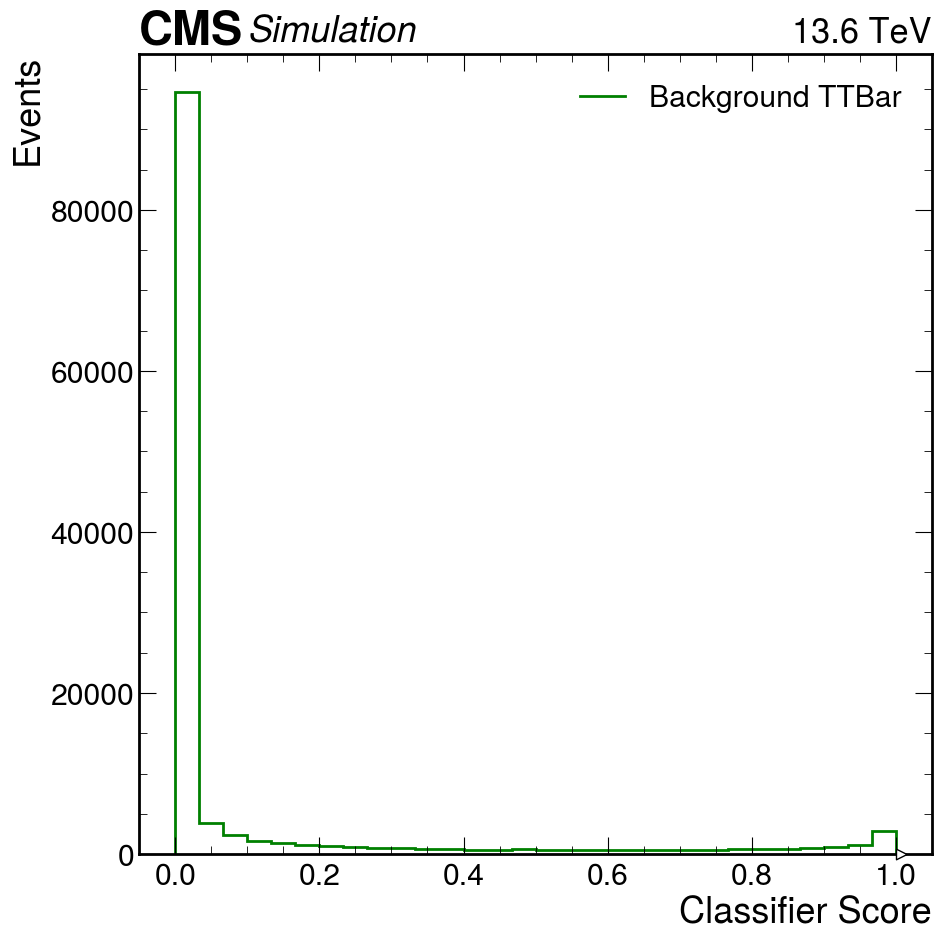

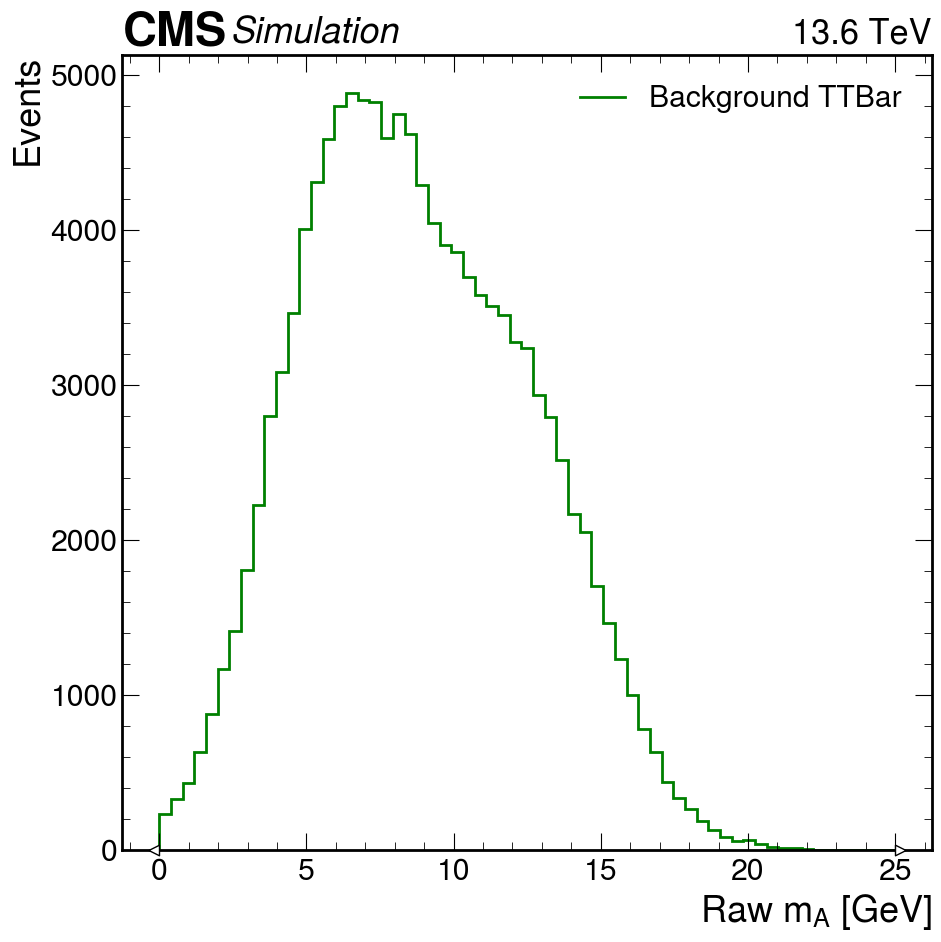

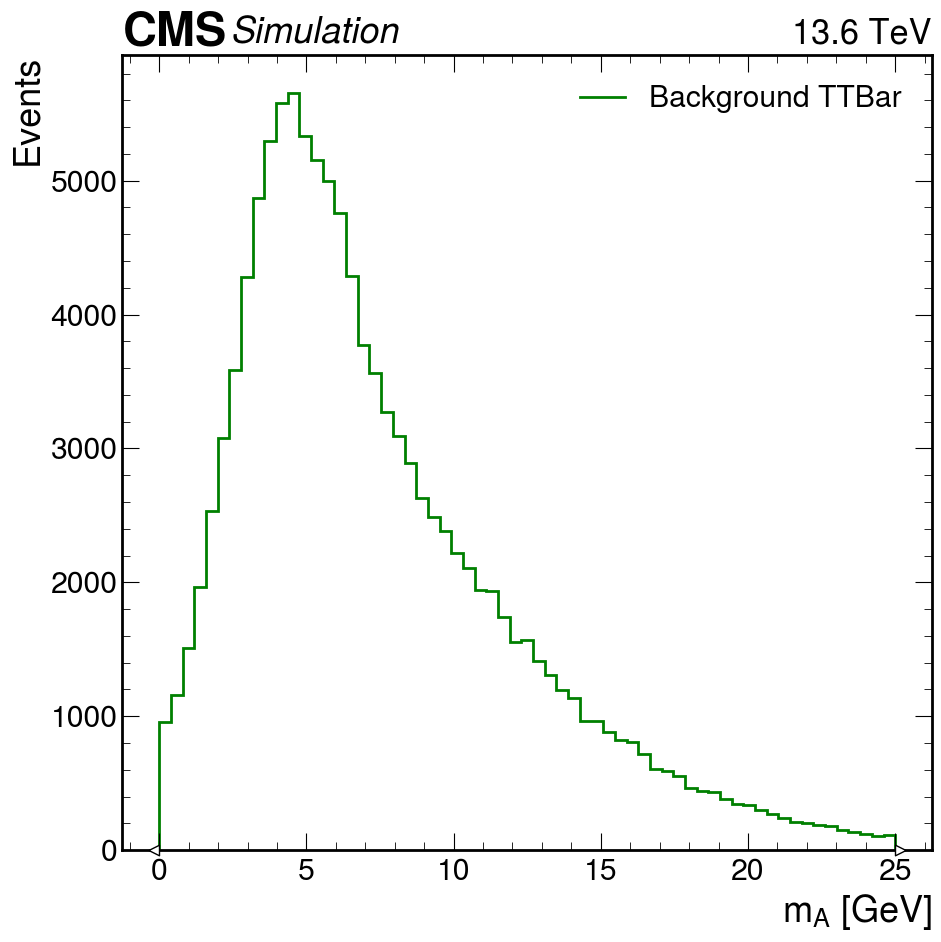

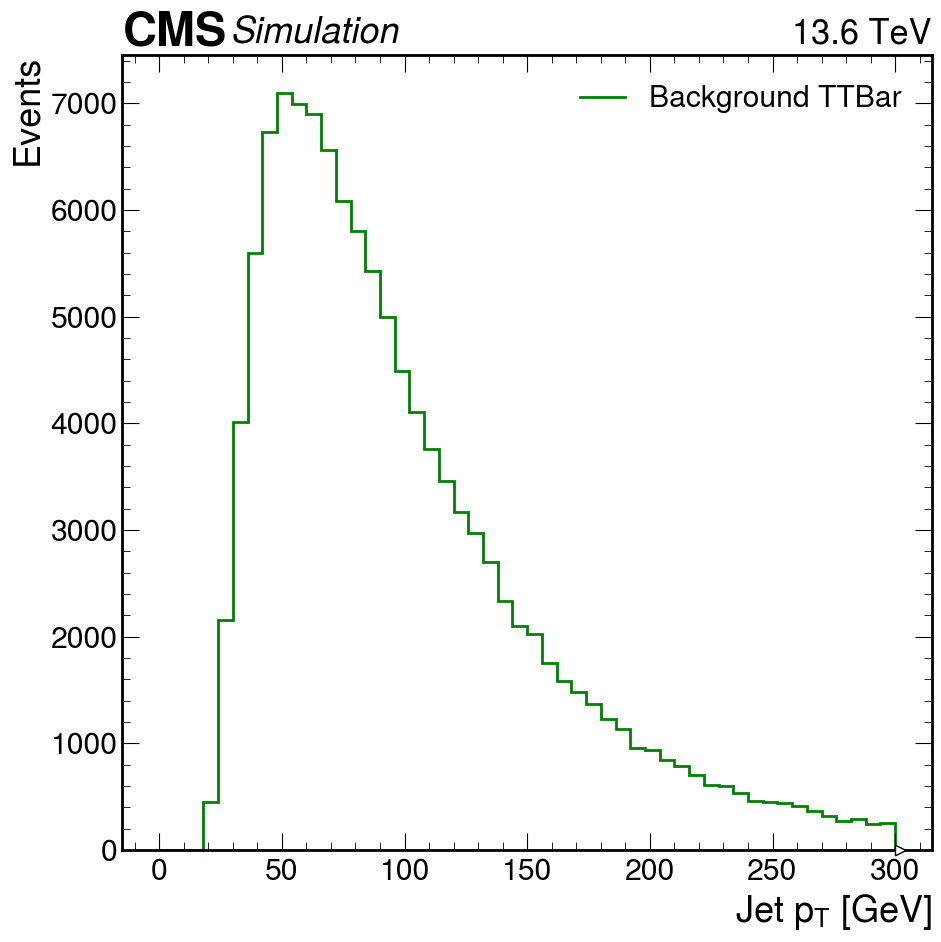

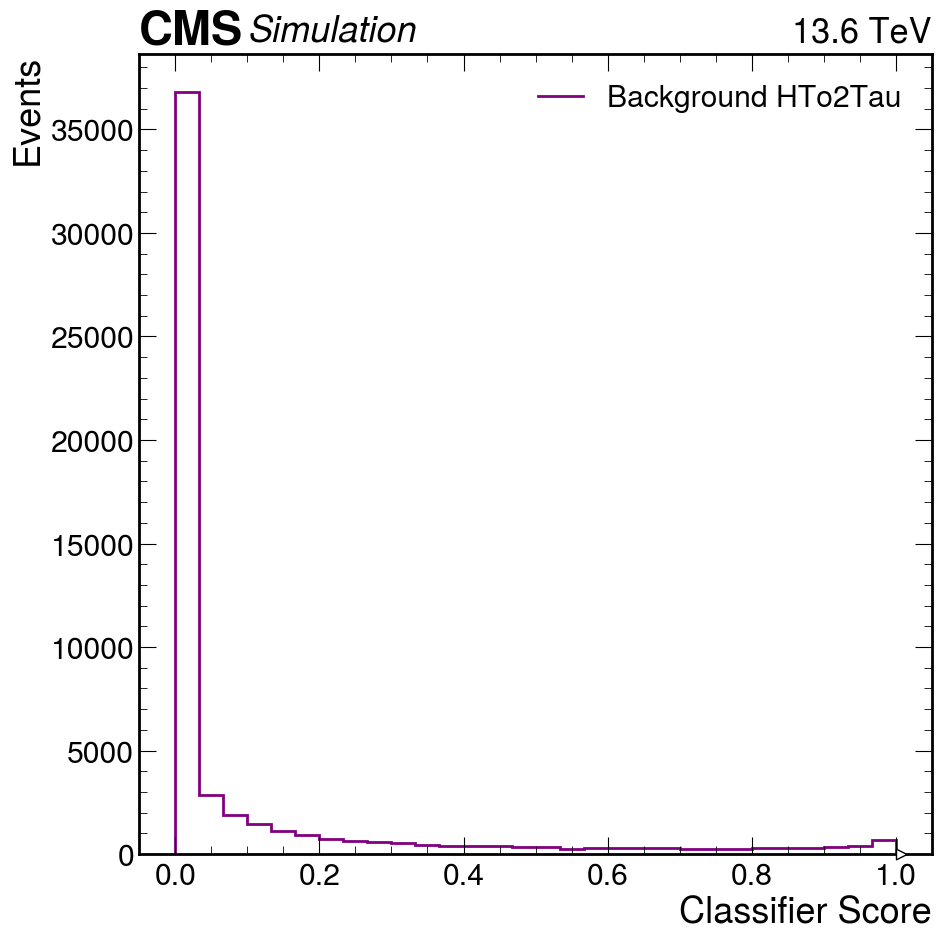

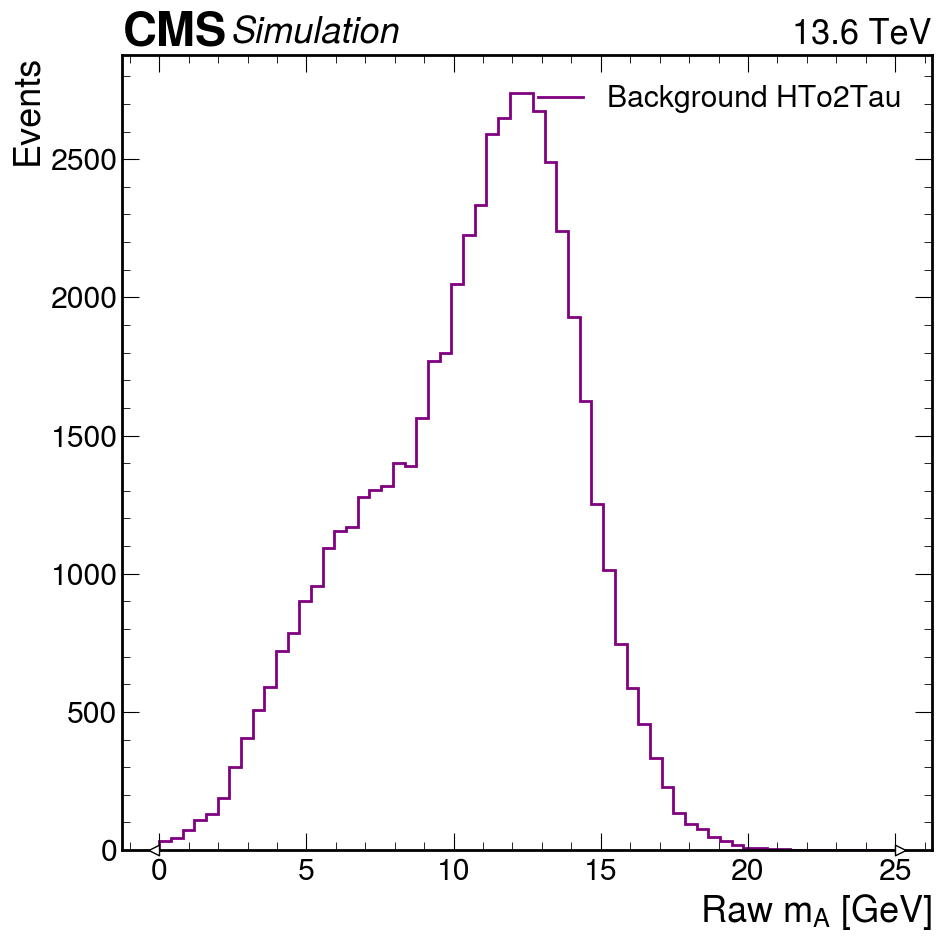

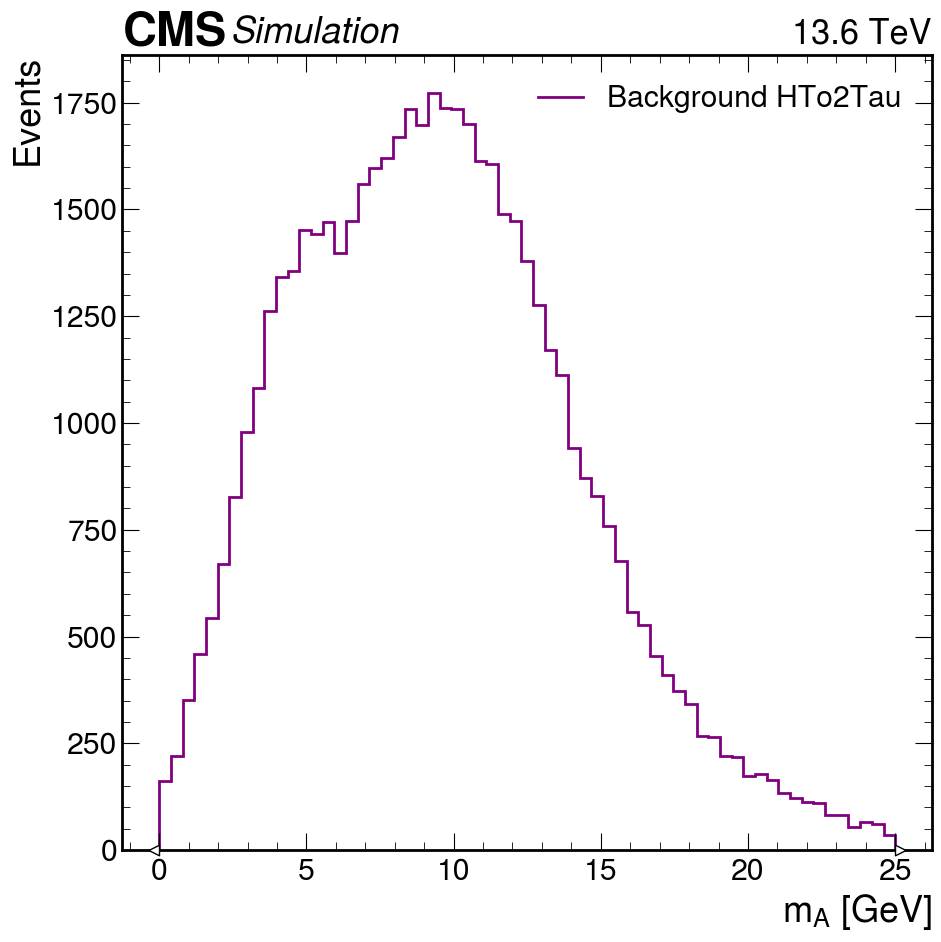

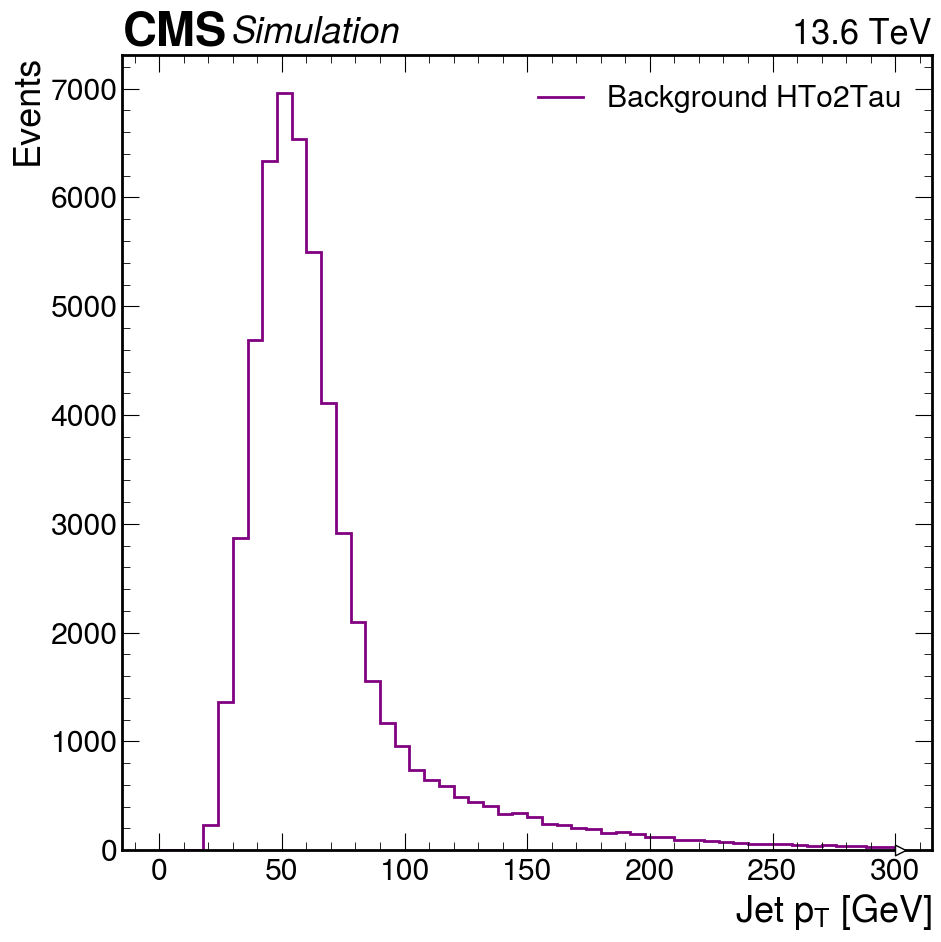

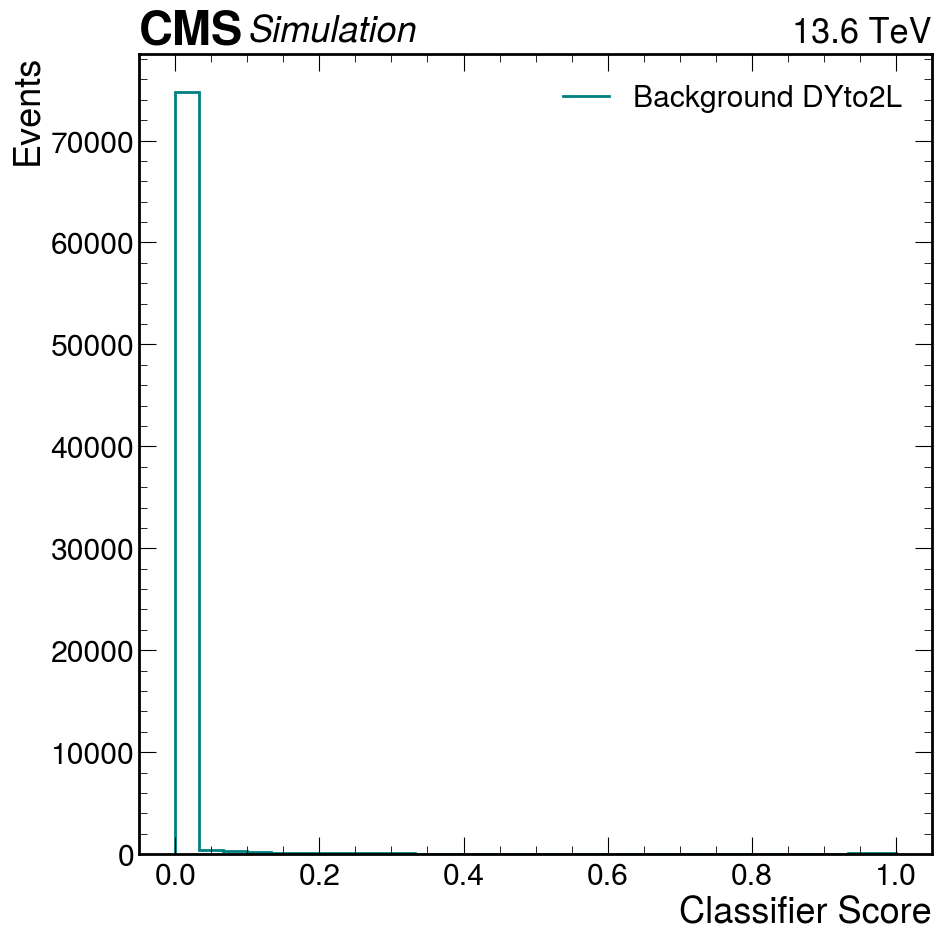

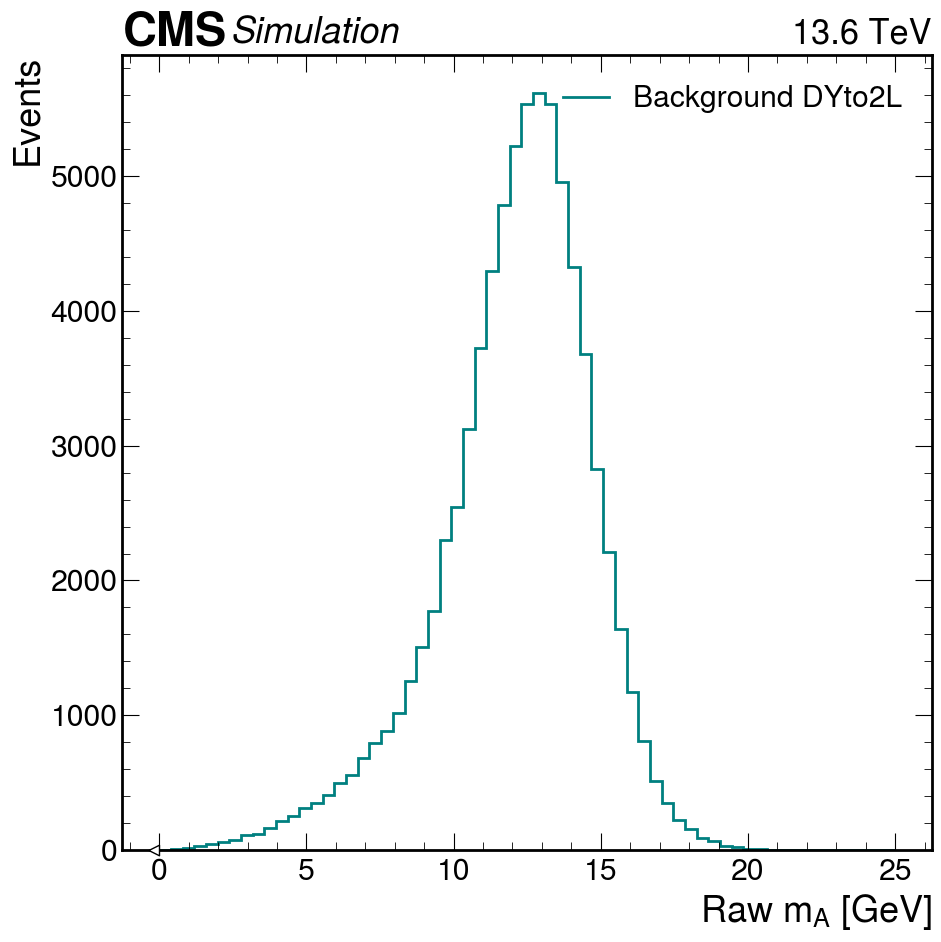

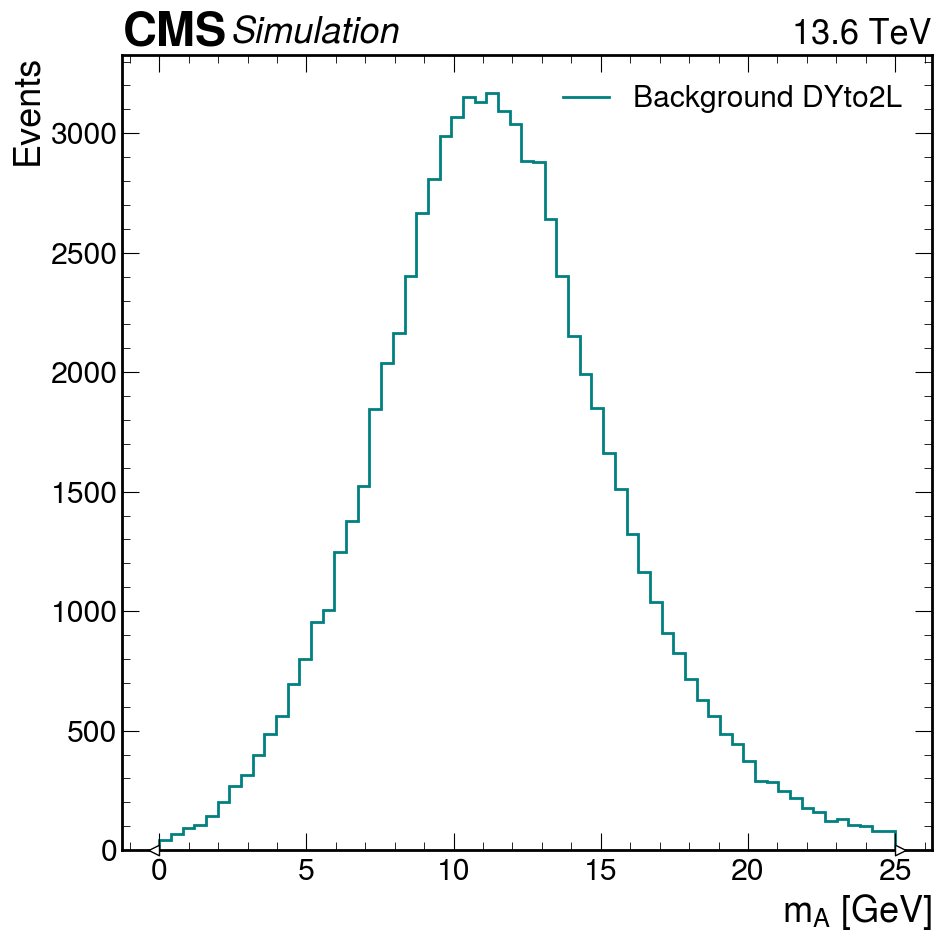

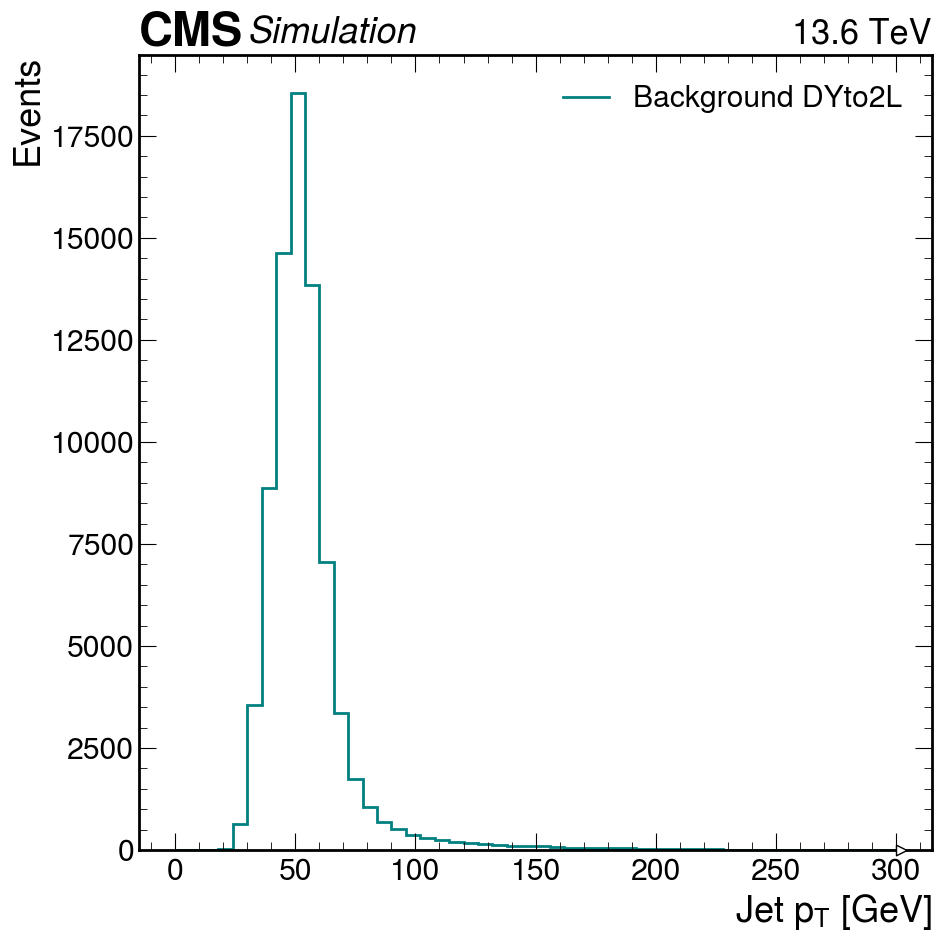

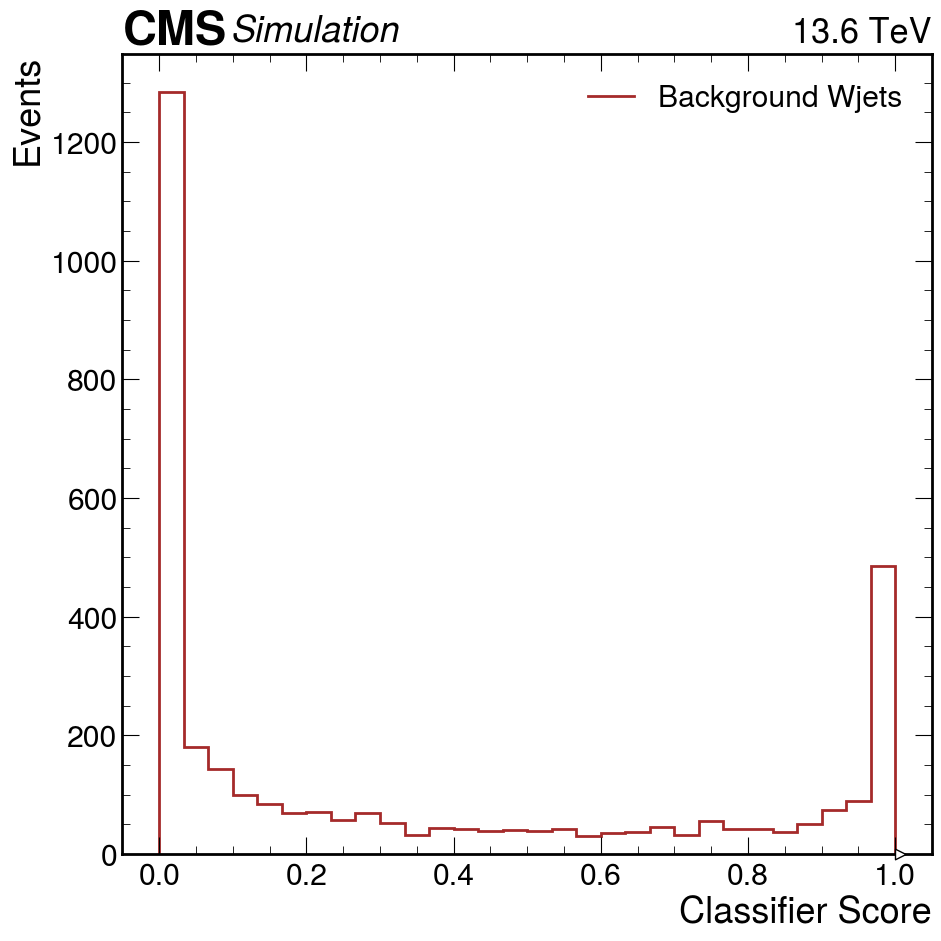

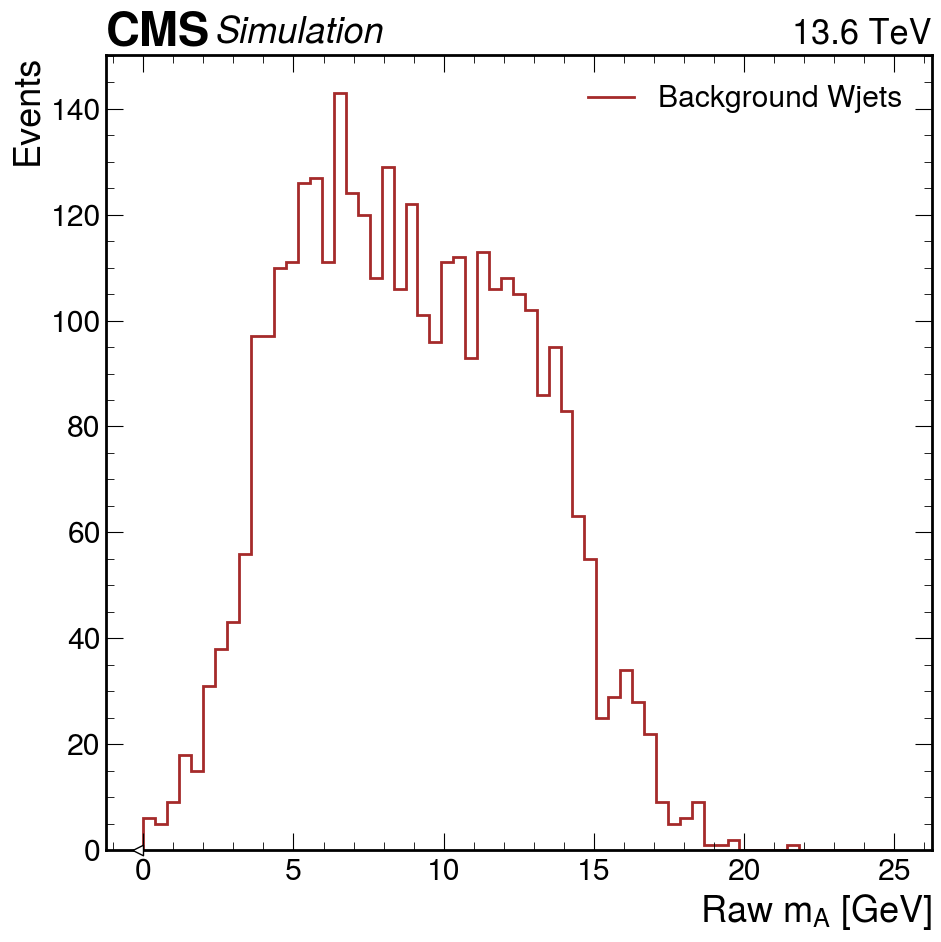

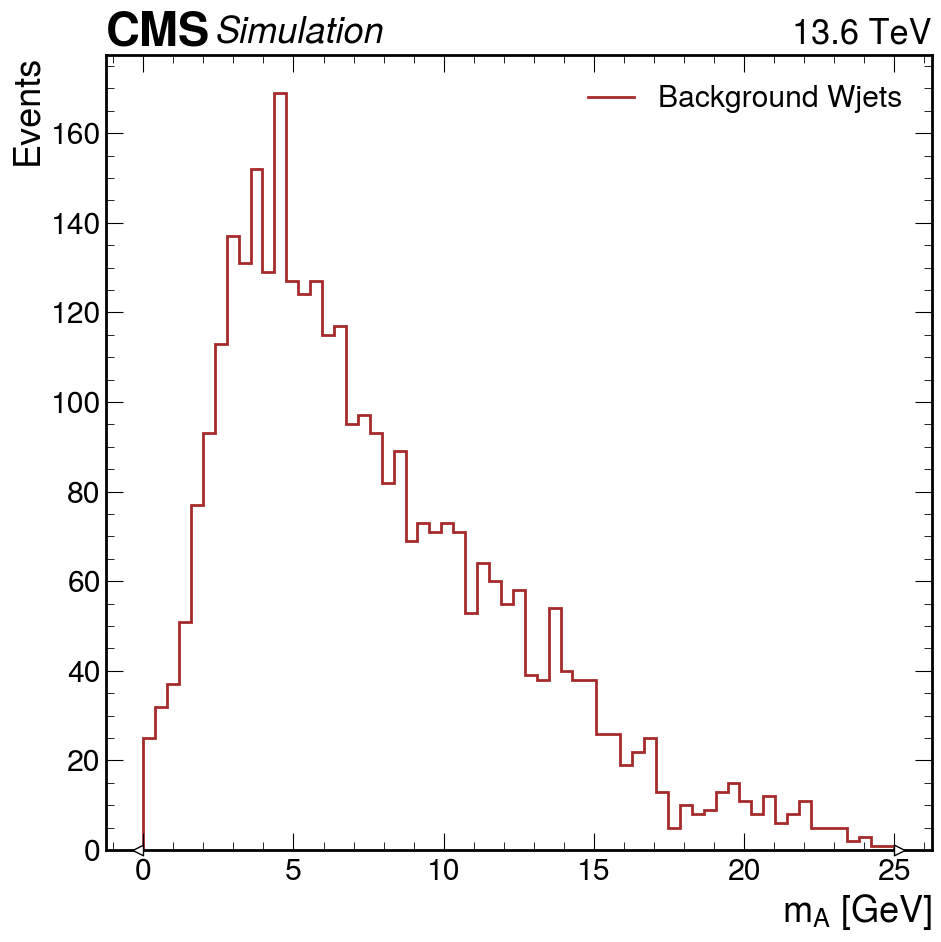

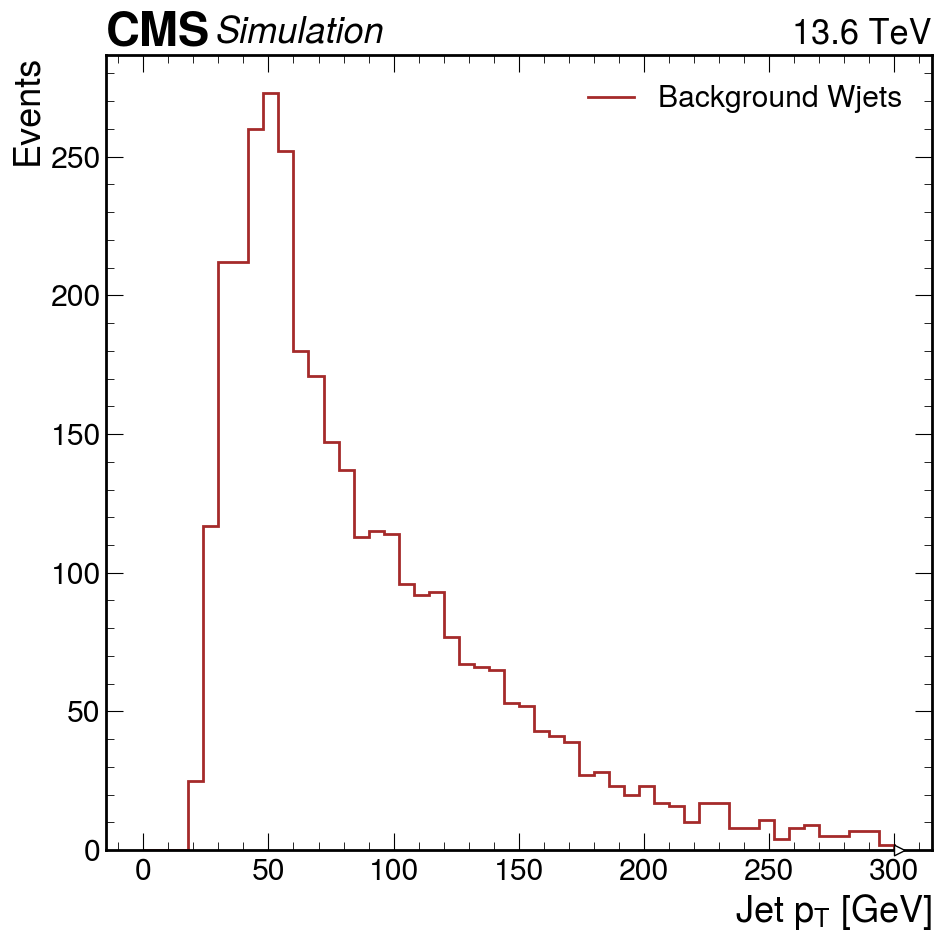

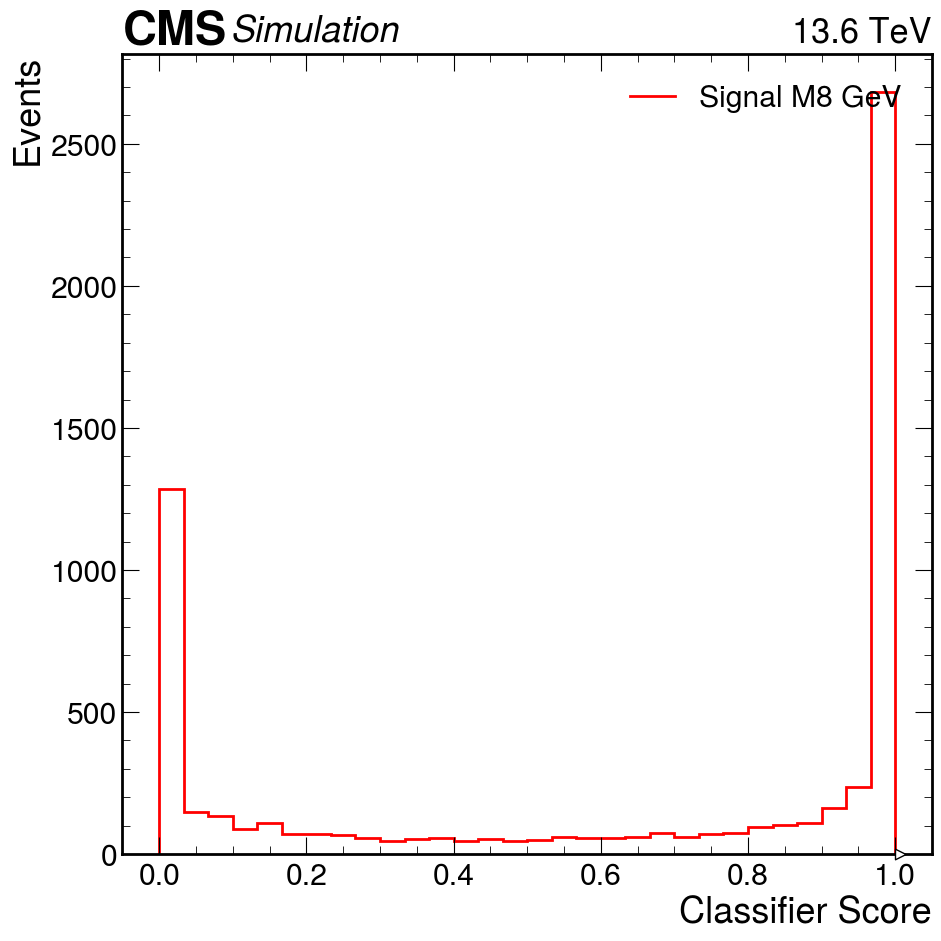

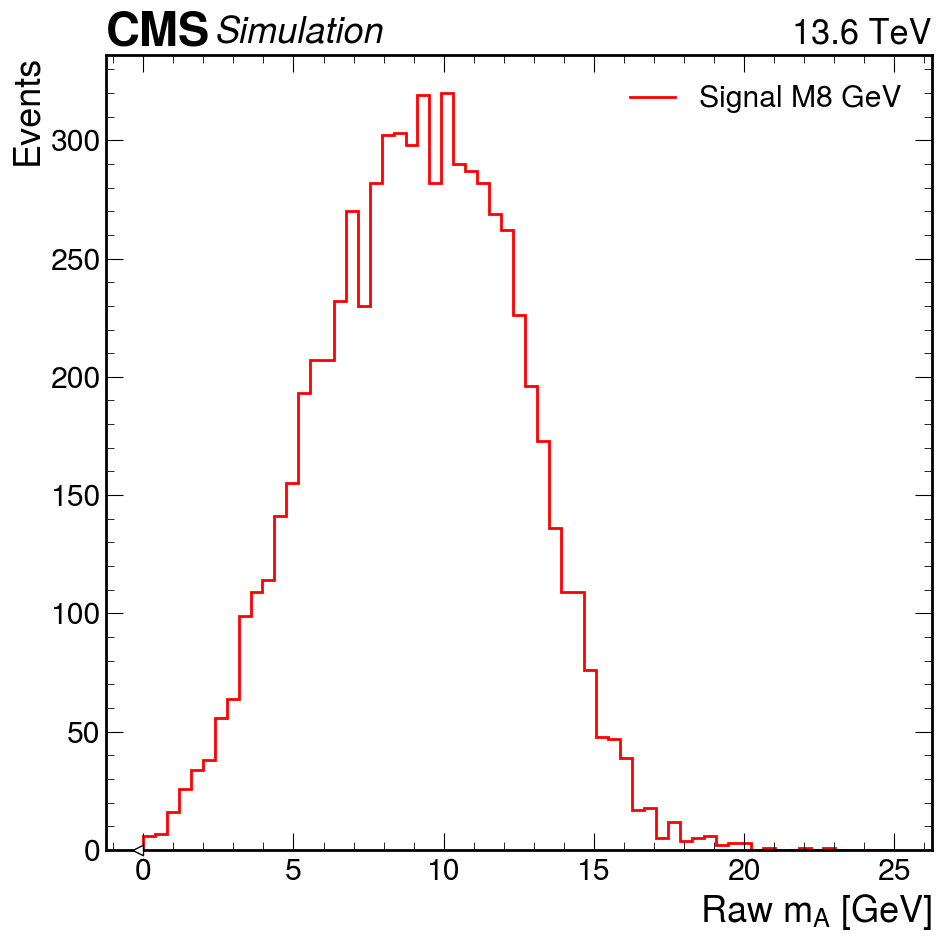

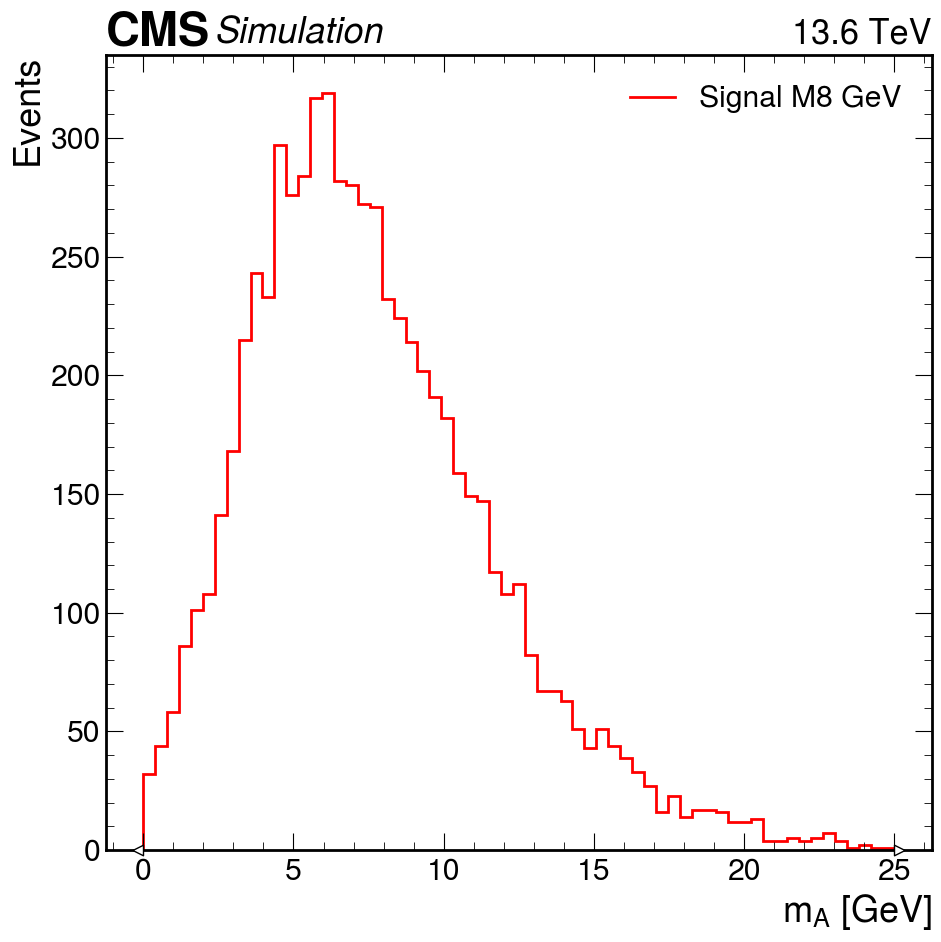

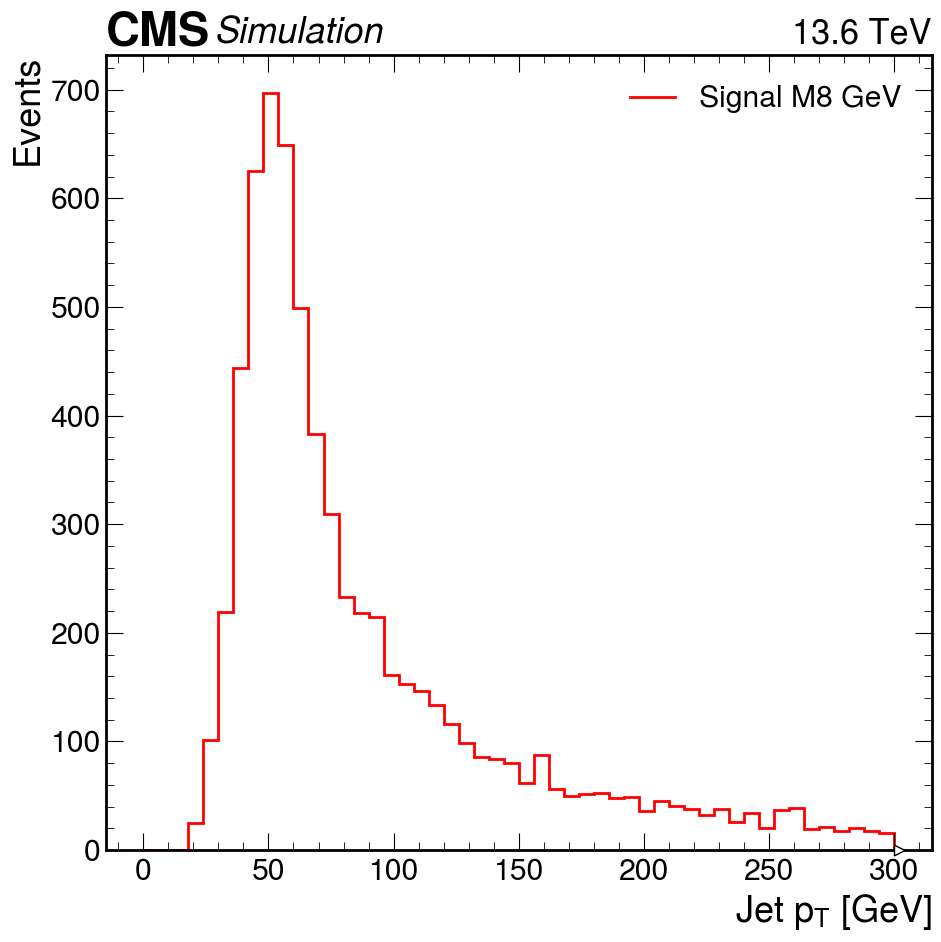

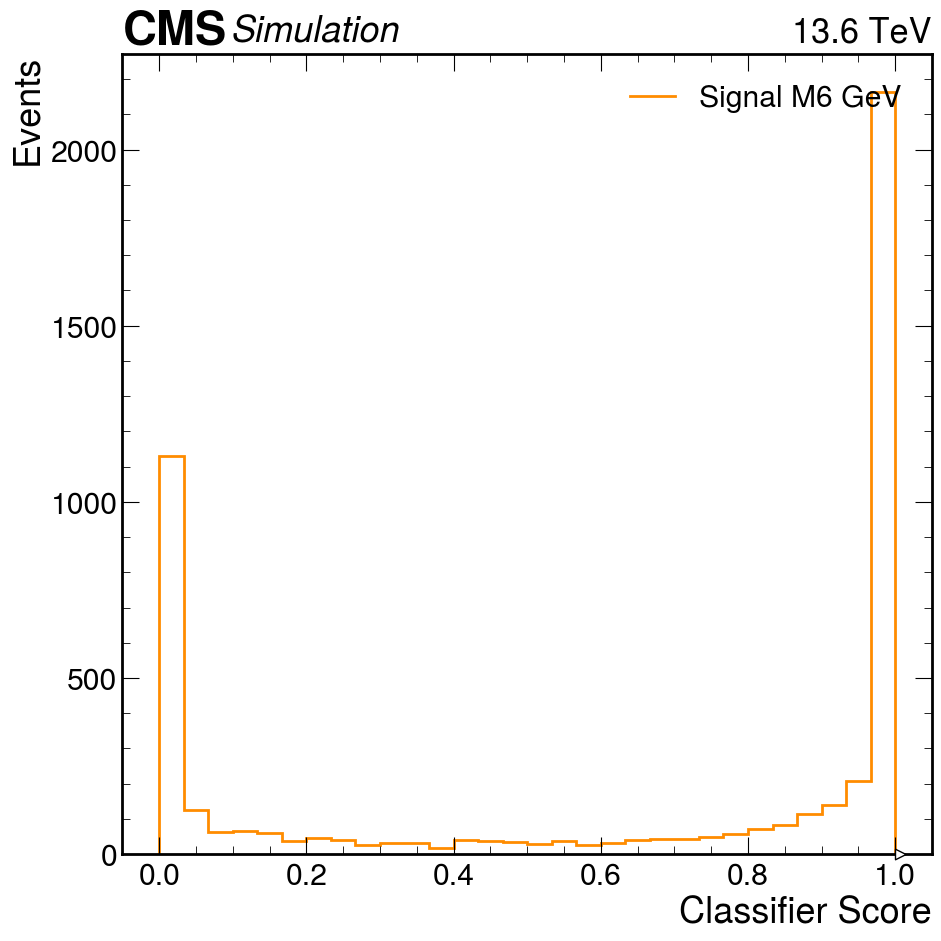

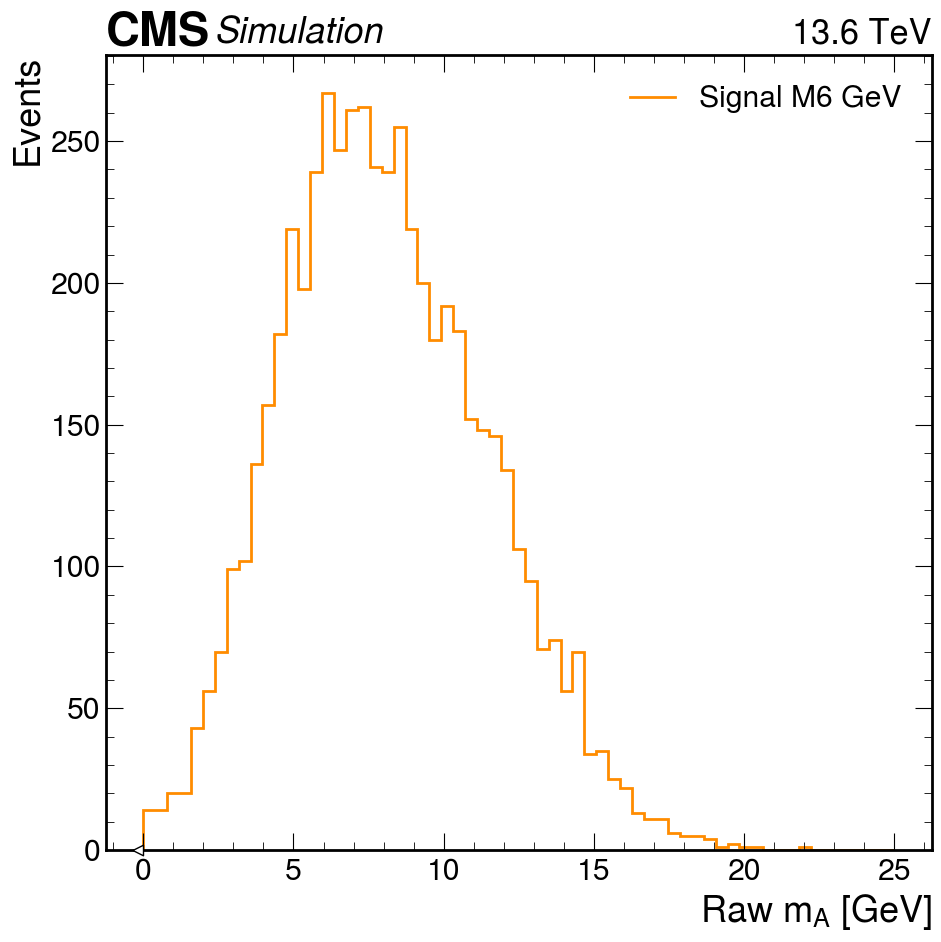

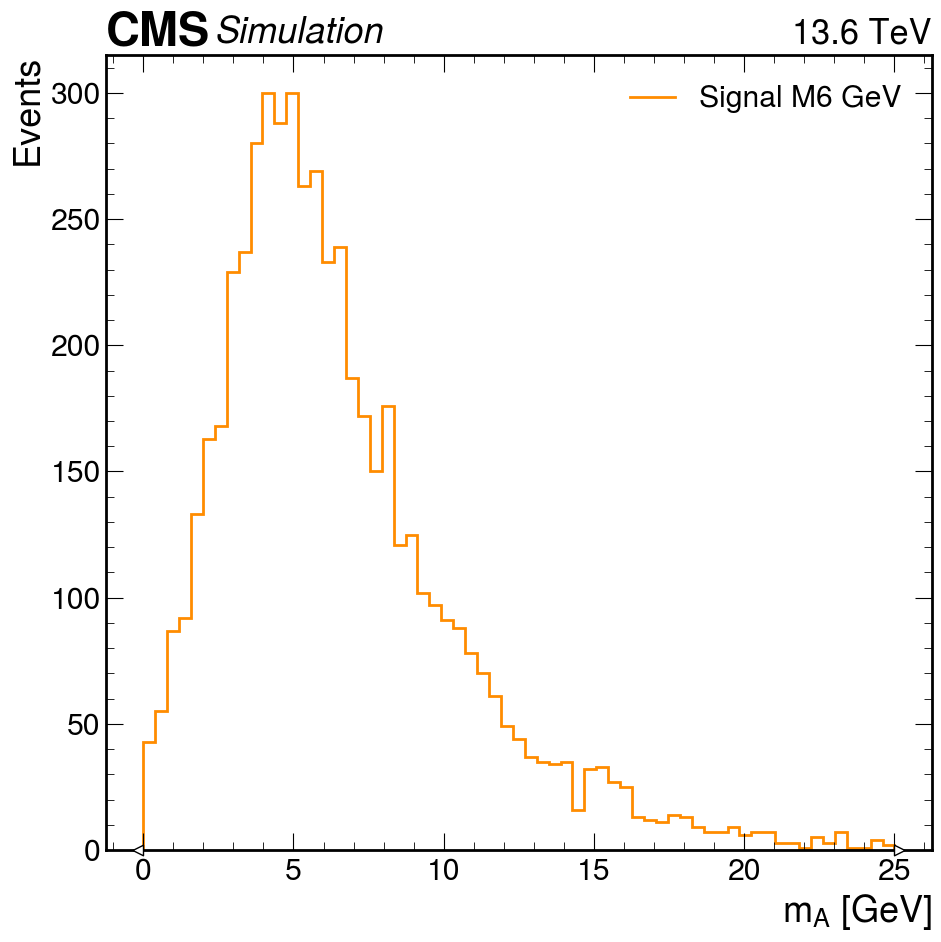

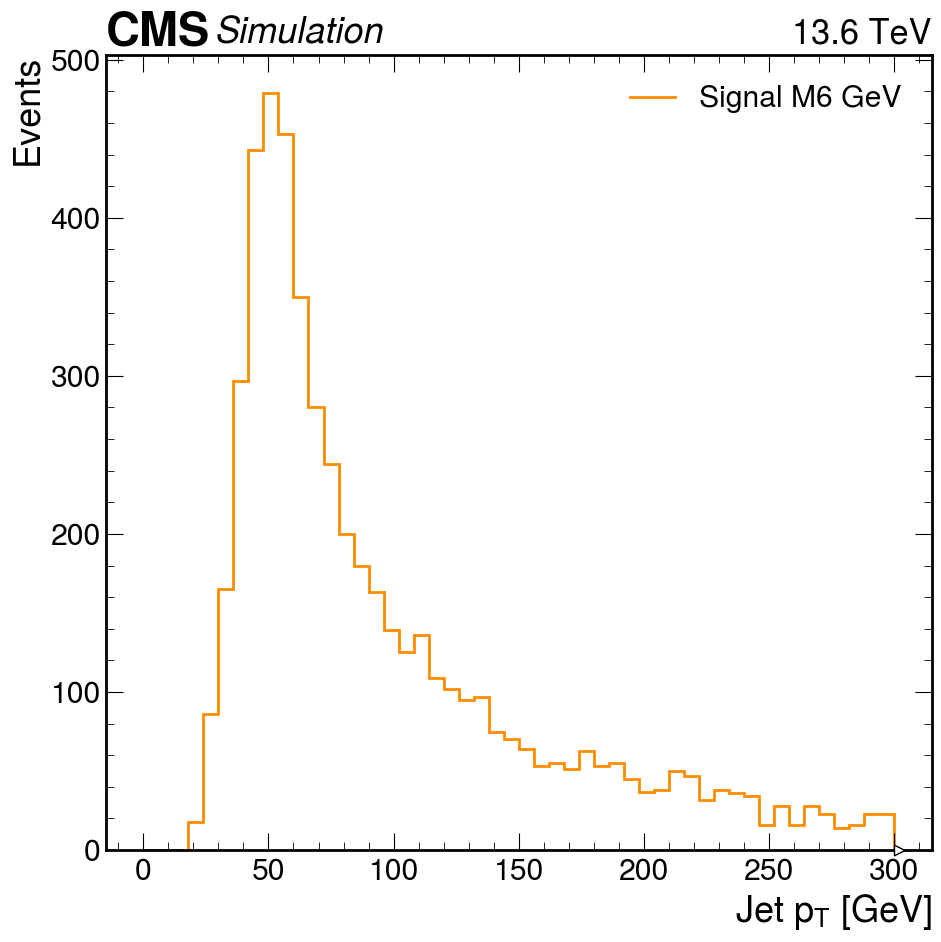

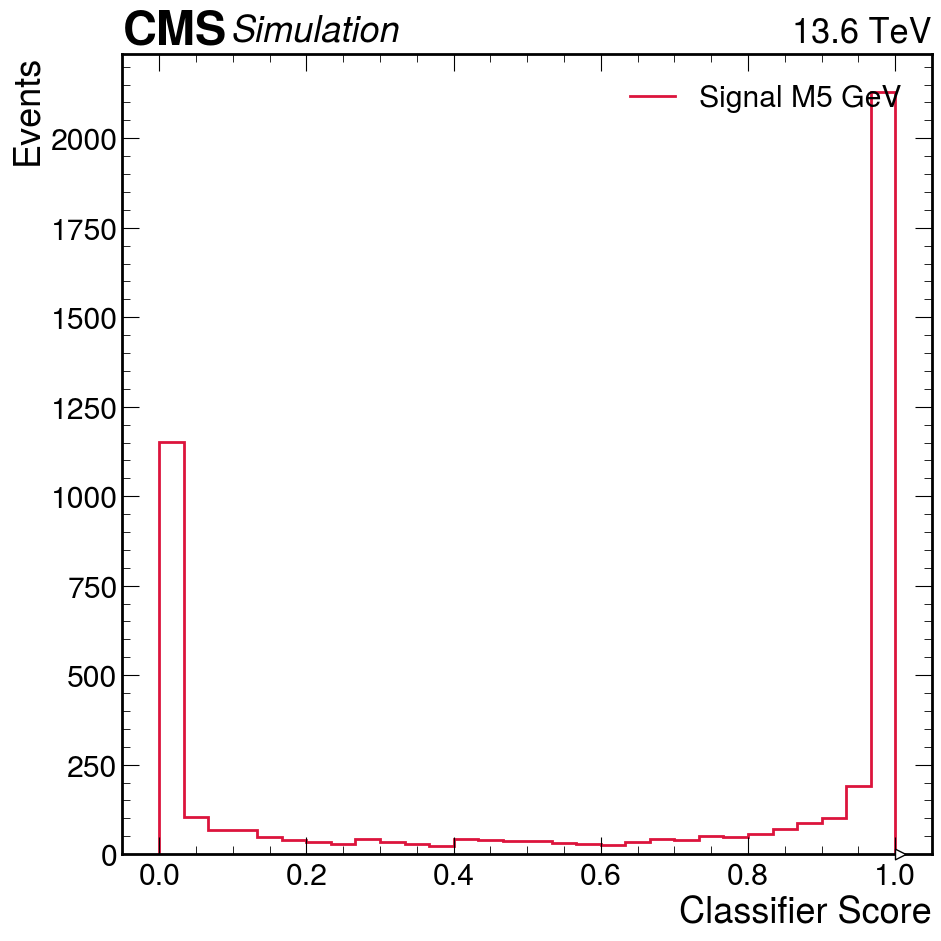

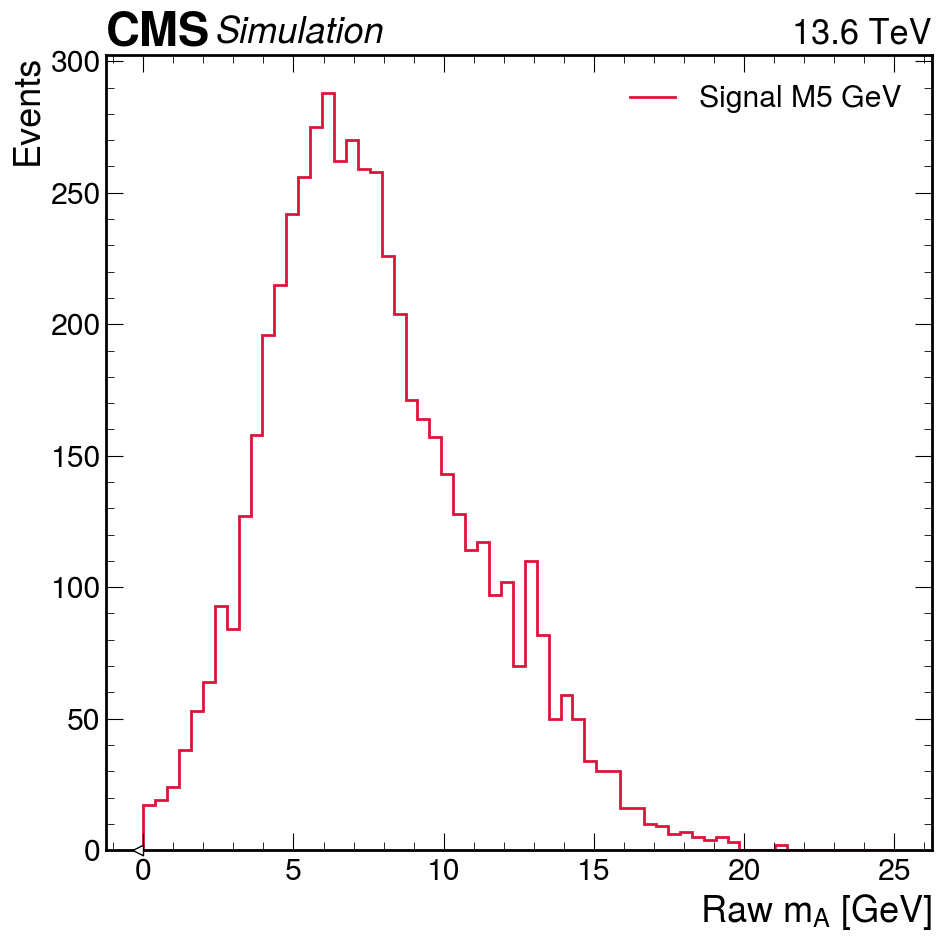

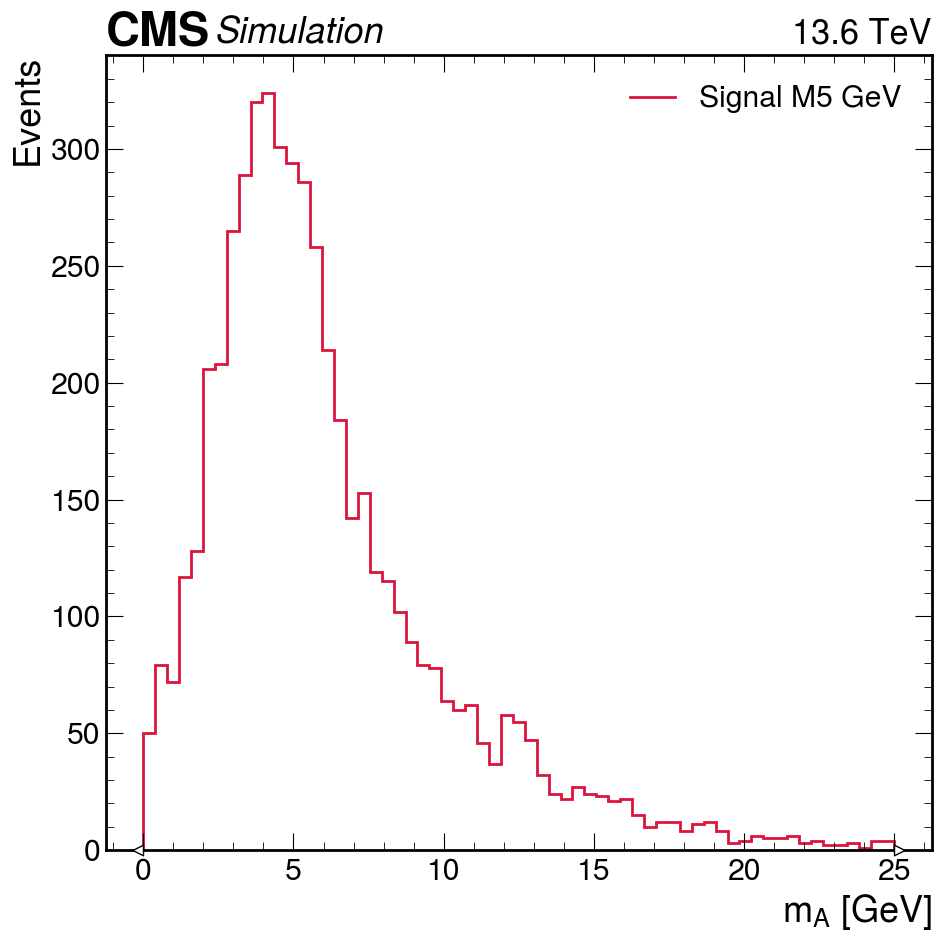

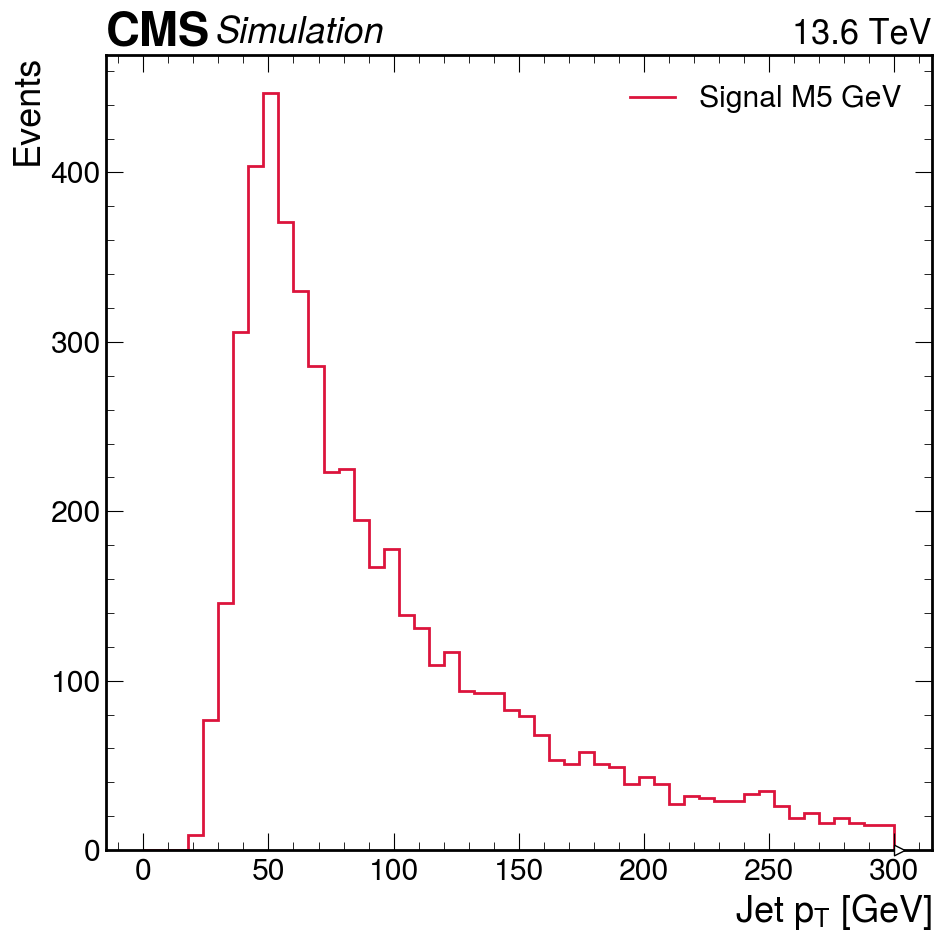

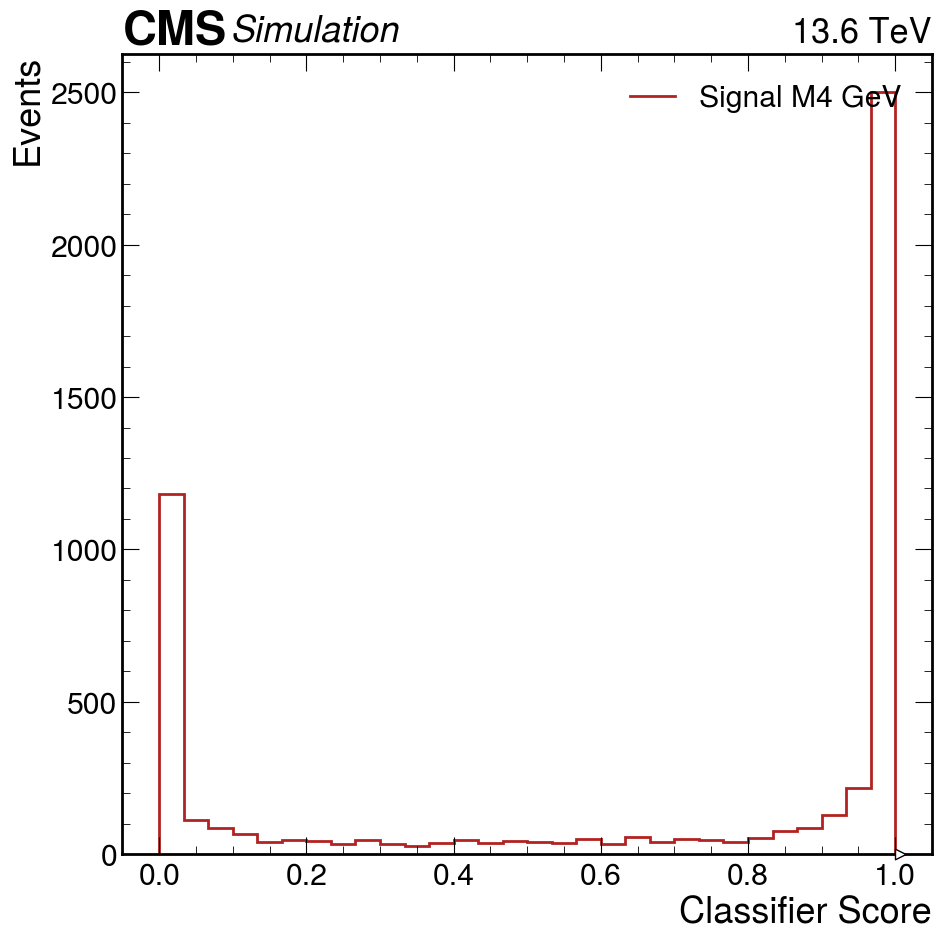

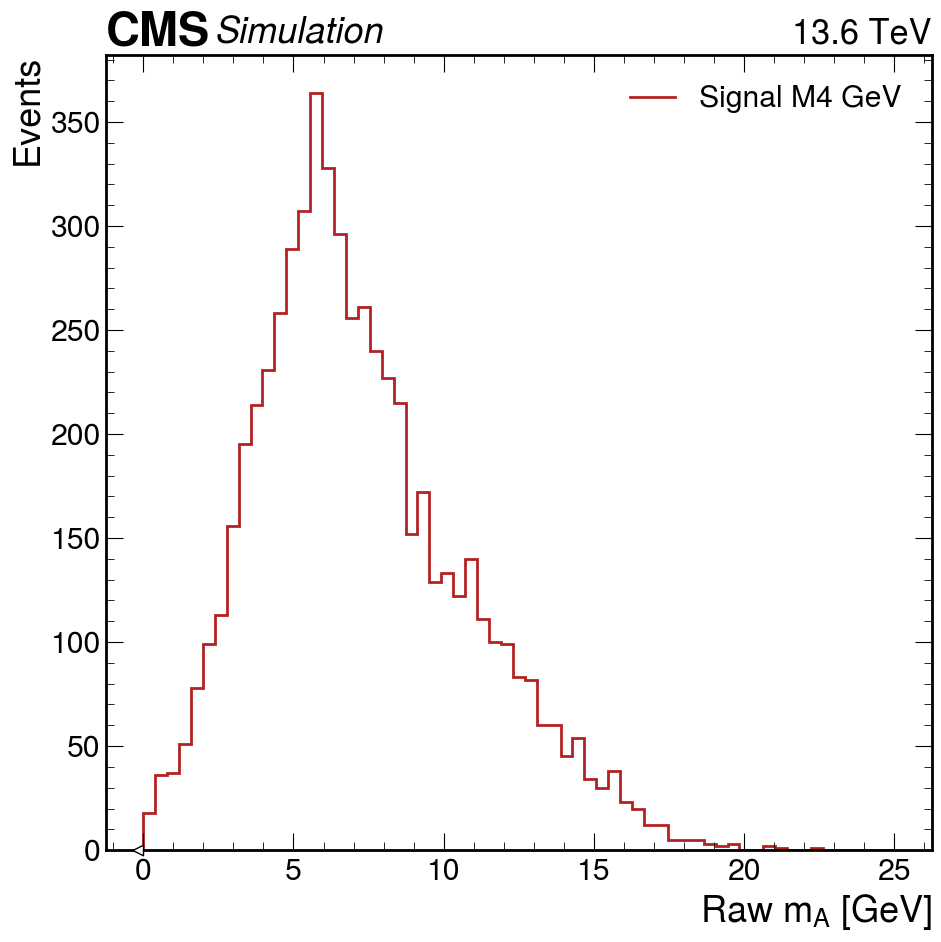

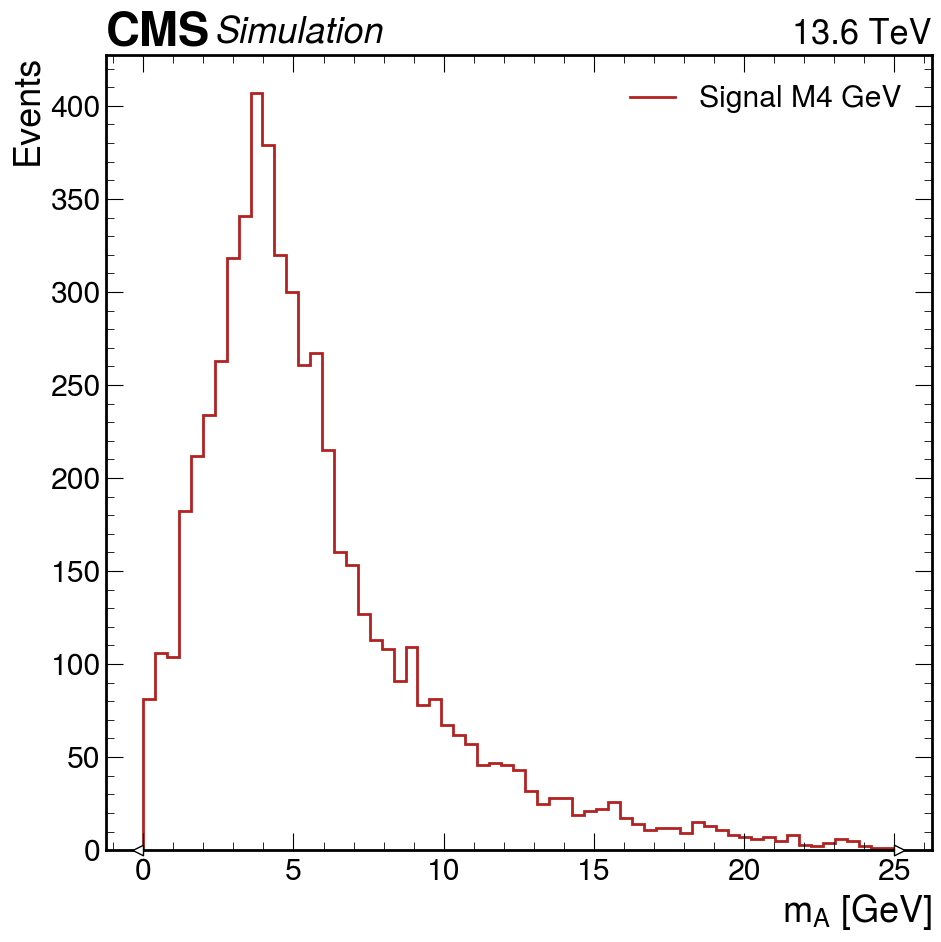

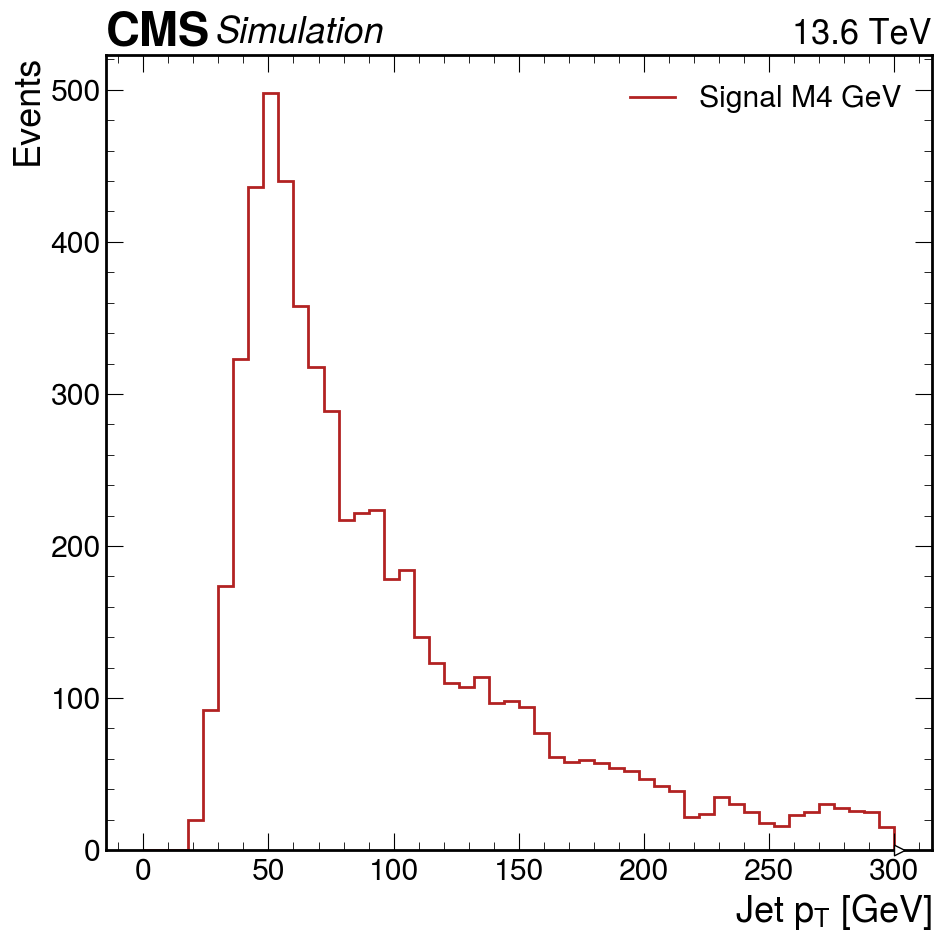

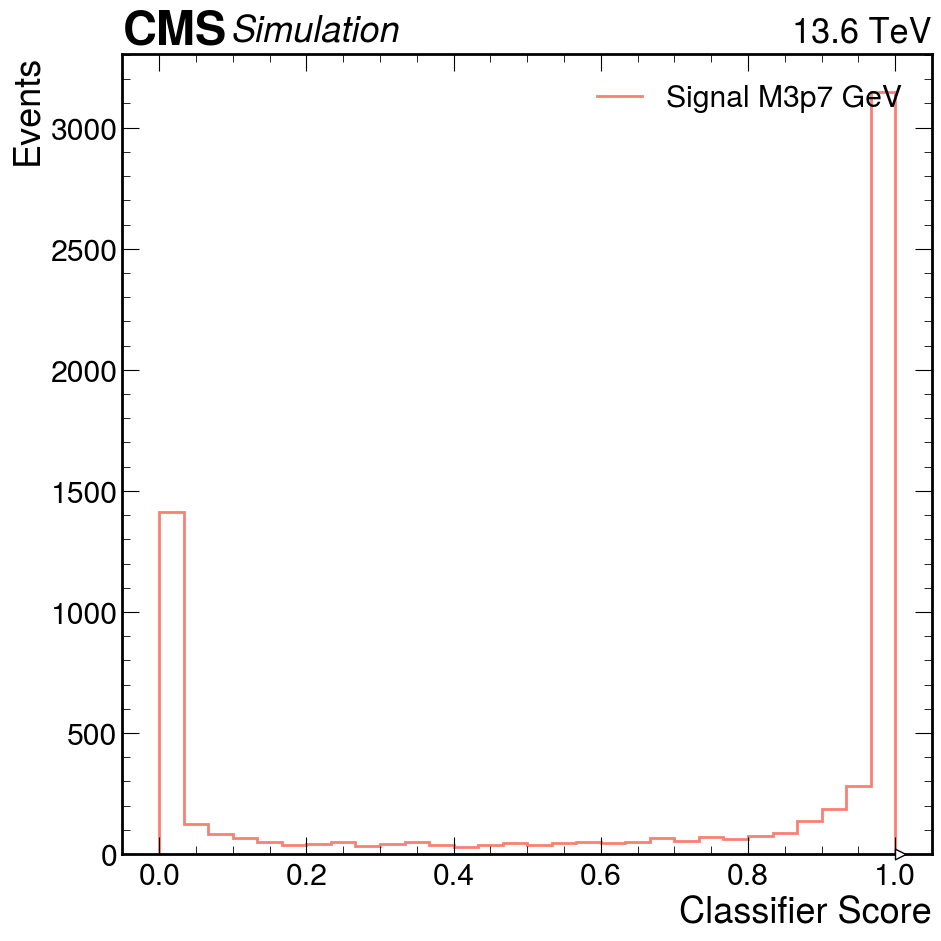

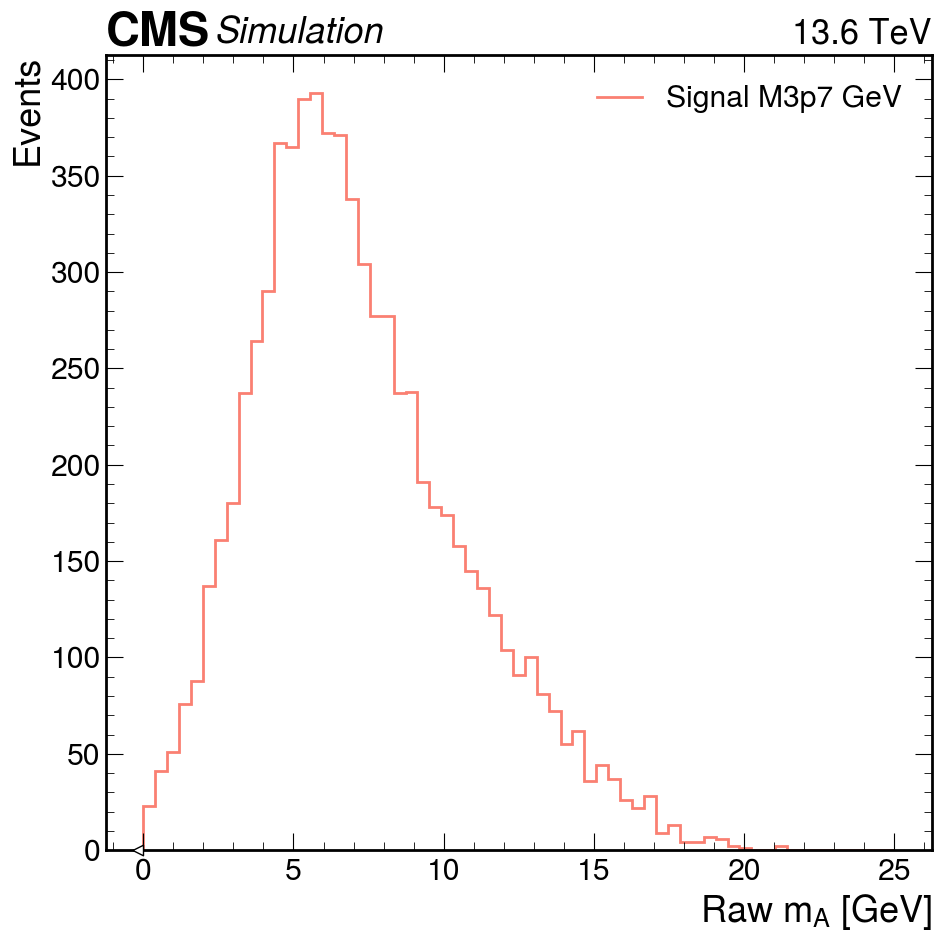

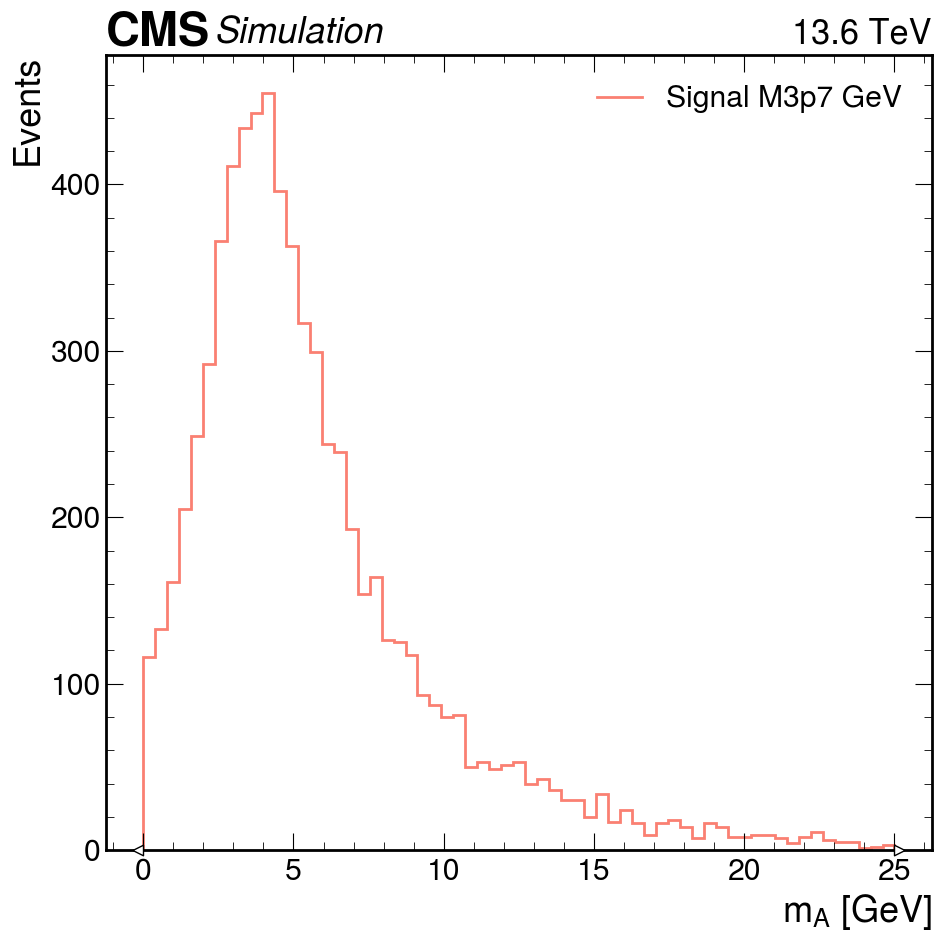

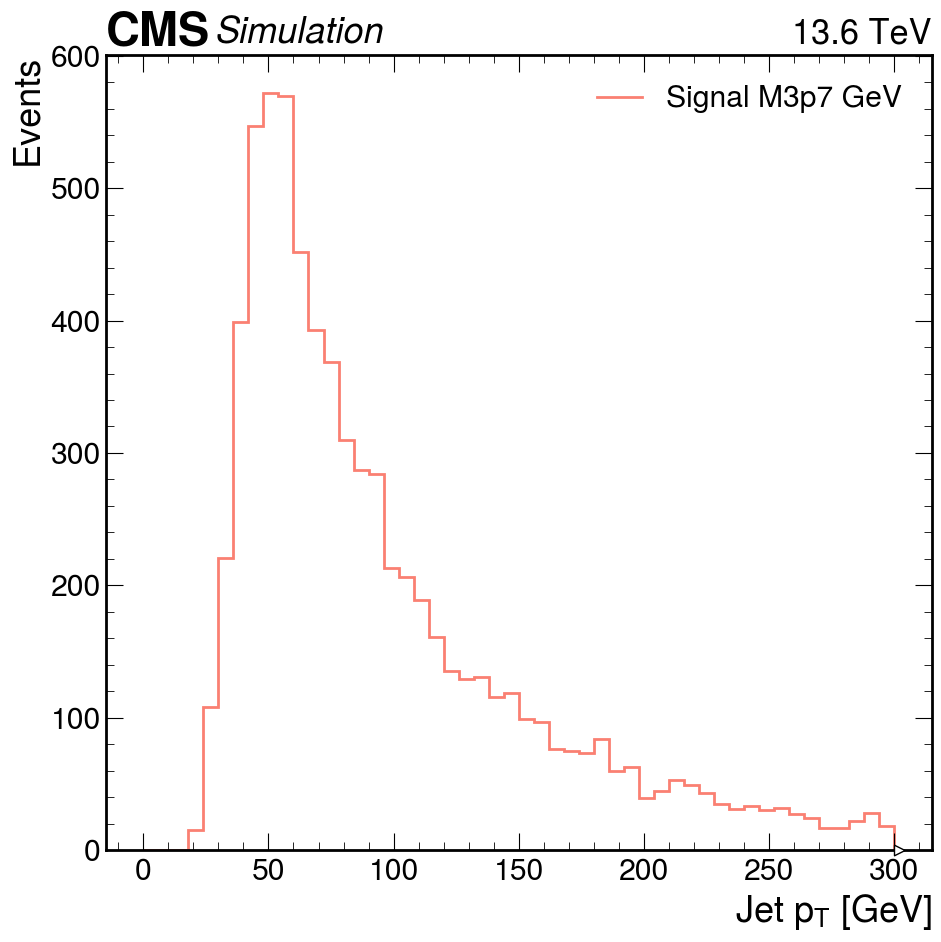

All plots saved under '../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check/', filenames encode dataset + histogram type.


In [11]:
import os
import mplhep as hep
import matplotlib.pyplot as plt

# Use standard High Energy Physics plotting style
plt.style.use(hep.style.CMS)

# Create a single output directory for saving plots
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check"
os.makedirs(outdir, exist_ok=True)

# Color scheme: consistent colors per dataset, distinguishing signal vs background
signal_colors = ["red", "darkorange", "crimson", "firebrick", "salmon", "tomato"]
background_colors = ["blue", "green", "purple", "teal", "brown", "magenta"]
sig_idx = 0
bkg_idx = 0

# Loop through every dataset in the output dictionary
for dataset_name, dataset_output in out.items():
    # Determine if this dataset is signal or background, and assign a color/label
    if dataset_name.startswith("Signal"):
        color = signal_colors[sig_idx % len(signal_colors)]
        sig_idx += 1
        process_label = dataset_name.replace(
            "_with_mass_classifier_infernce_miniAOD_June15", ""
        ).replace("_", " ")
    elif dataset_name.startswith("Background"):
        color = background_colors[bkg_idx % len(background_colors)]
        bkg_idx += 1
        process_label = dataset_name.replace(
            "_with_mass_classifier_infernce_miniAOD_June15", ""
        ).replace("_", " ")
    else:
        # Fallback for any unexpected dataset naming
        color = "black"
        process_label = dataset_name

    # Short, filesystem-friendly dataset tag for filenames
    dataset_tag = dataset_name.replace(
        "_with_mass_classifier_infernce_miniAOD_June15", ""
    )

    # Loop through all items (histograms) in this dataset's dictionary
    for name, item in dataset_output.items():
        # Skip non-histogram metadata like 'entries'
        if not hasattr(item, "plot1d"):
            continue

        fig, ax = plt.subplots()

        # Plot the histogram
        item.plot1d(
            ax=ax,
            histtype="step",
            color=color,
            linewidth=2,
            rasterized=True,
            label=process_label,
        )

        # Styling and annotations
        ax.set_ylabel("Events")
        ax.legend(loc="upper right")

        # Add HEP experiment label (CMS Private Work / Simulation)
        hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax)

        # Save and display
        plt.tight_layout()
        outpath = os.path.join(outdir, f"{dataset_tag}_{name}.pdf")
        plt.savefig(outpath, dpi=300)
        plt.show()
        plt.close(fig)

print(f"All plots saved under '{outdir}/', filenames encode dataset + histogram type.")

In [10]:
out

{'Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15': {'entries': 469,
  'Classifier_score': Hist(
    StrCategory(['classifier_score_'], name='hmassjet'),
    Regular(30, 0, 1, name='massjet', label='classifier score'),
    storage=Int64()) # Sum: 0.0 (804.0 with flow)}}

In [150]:
out_dir='../analysis_run3/AN_Note_Plot/Higgs_Mass'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)

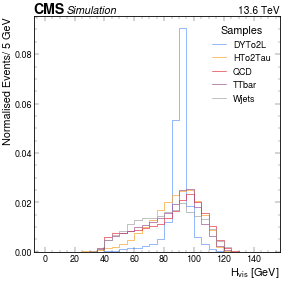

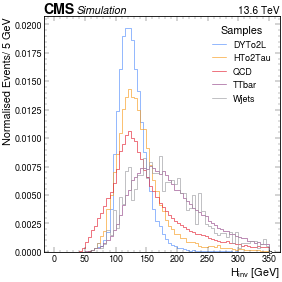

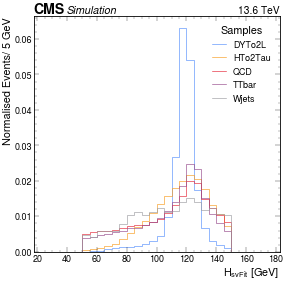

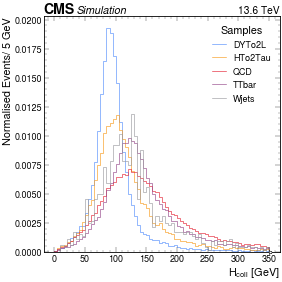

In [155]:
import pickle
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)

with open('Higgs_mass.pkl', 'rb') as f:
    out = pickle.load(f)

samples = [
    # 'Higgs_mass_M3p7_GeV',
    # 'Higgs_mass_M4_GeV',
    # 'Higgs_mass_M5_GeV',
    # 'Higgs_mass_M6_GeV',
    # 'Higgs_mass_M8_GeV',
    'Higgs_mass_DYTo2L_GeV',
    'Higgs_mass_HTo2Tau_GeV',
    'Higgs_mass_QCD_GeV',
    'Higgs_mass_TTbar_GeV',
    'Higgs_mass_Wjets_GeV'
]

dpi_ = 30

fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["TauMvis"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{vis}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_visible_bakground.pdf',facecolor='w',dpi=300)
#


fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["TauMtautau"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{inv}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_inv_bakground.pdf',facecolor='w',dpi=300)


fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["TauMtautau_svFit"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{svFit}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_svFit_approxmation_bakground.pdf',facecolor='w',dpi=300)

fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["Taumcoll"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{coll}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_coliner_approxmation_bakground.pdf',facecolor='w',dpi=300)





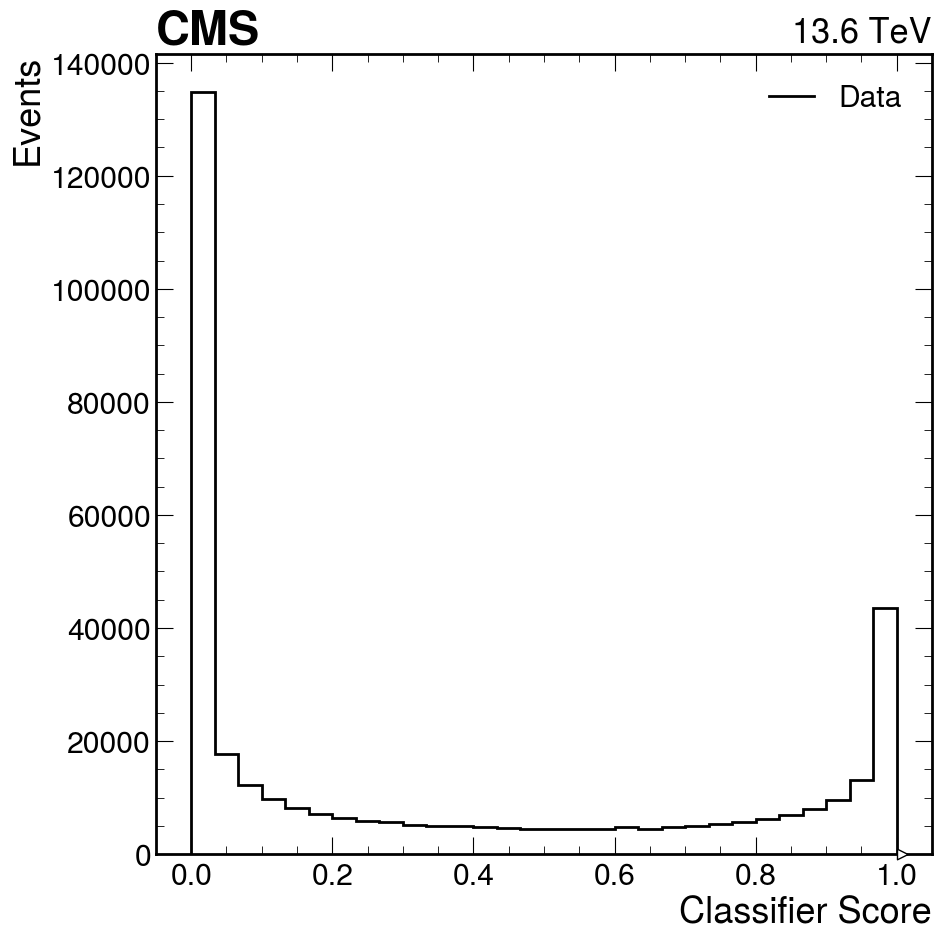

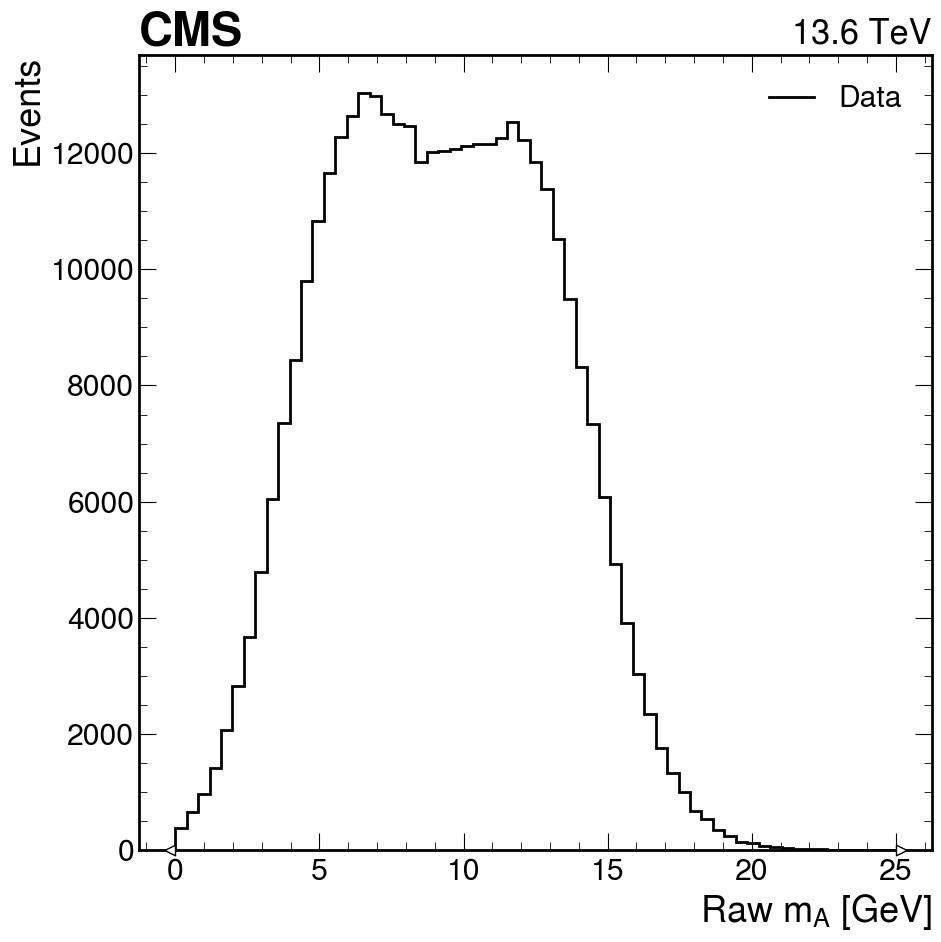

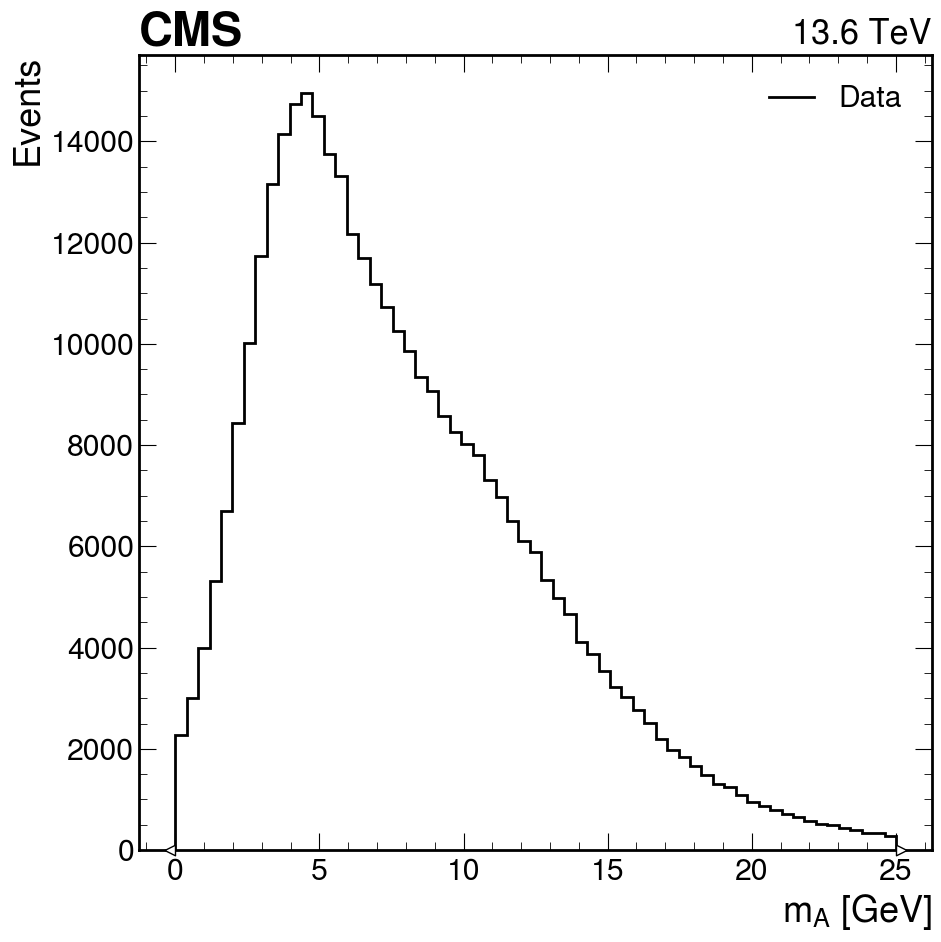

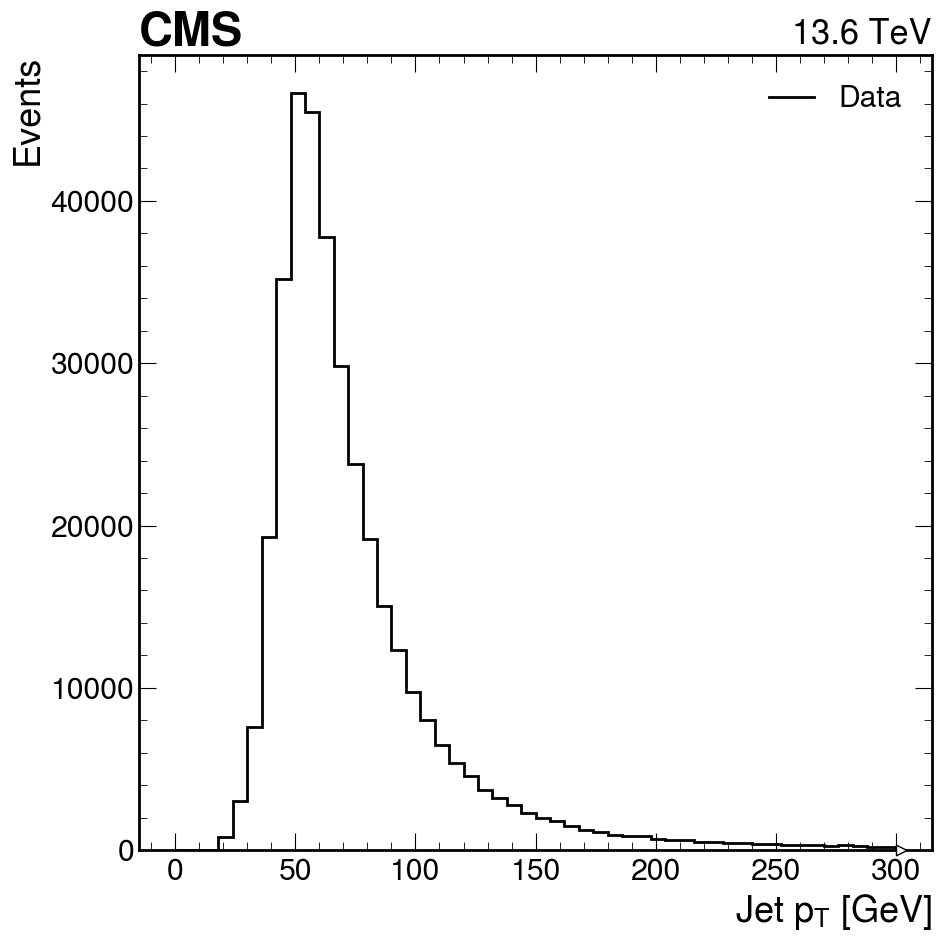

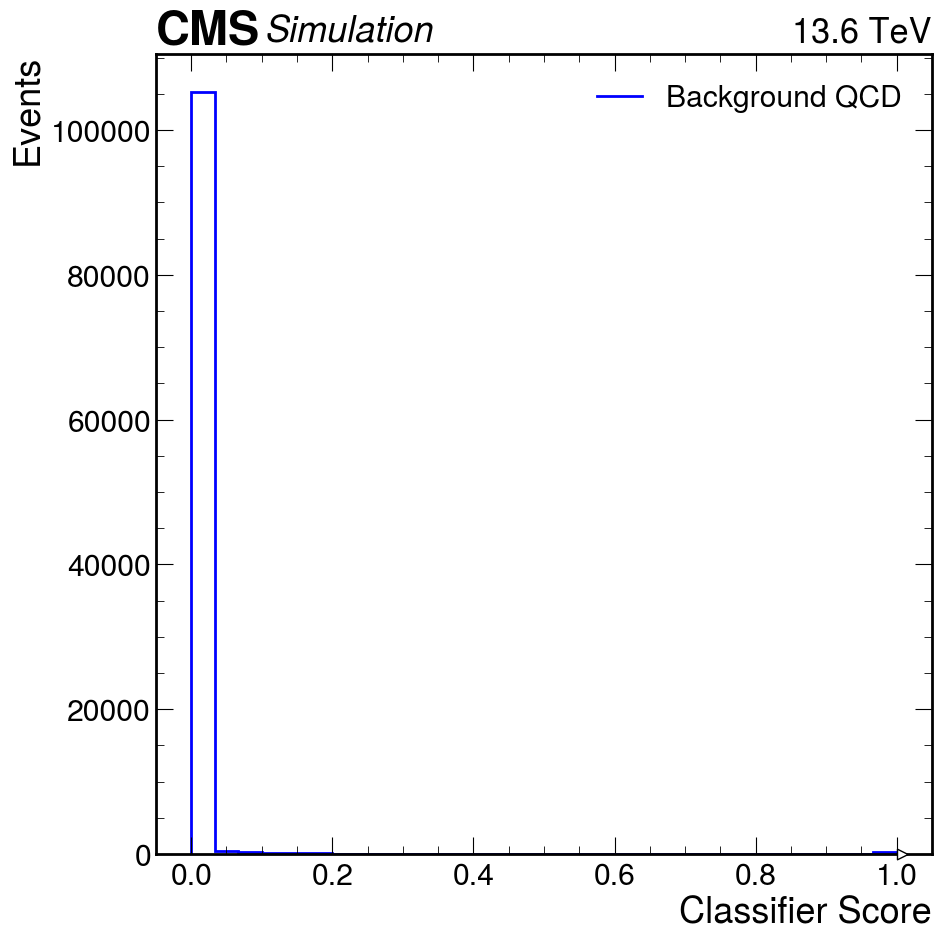

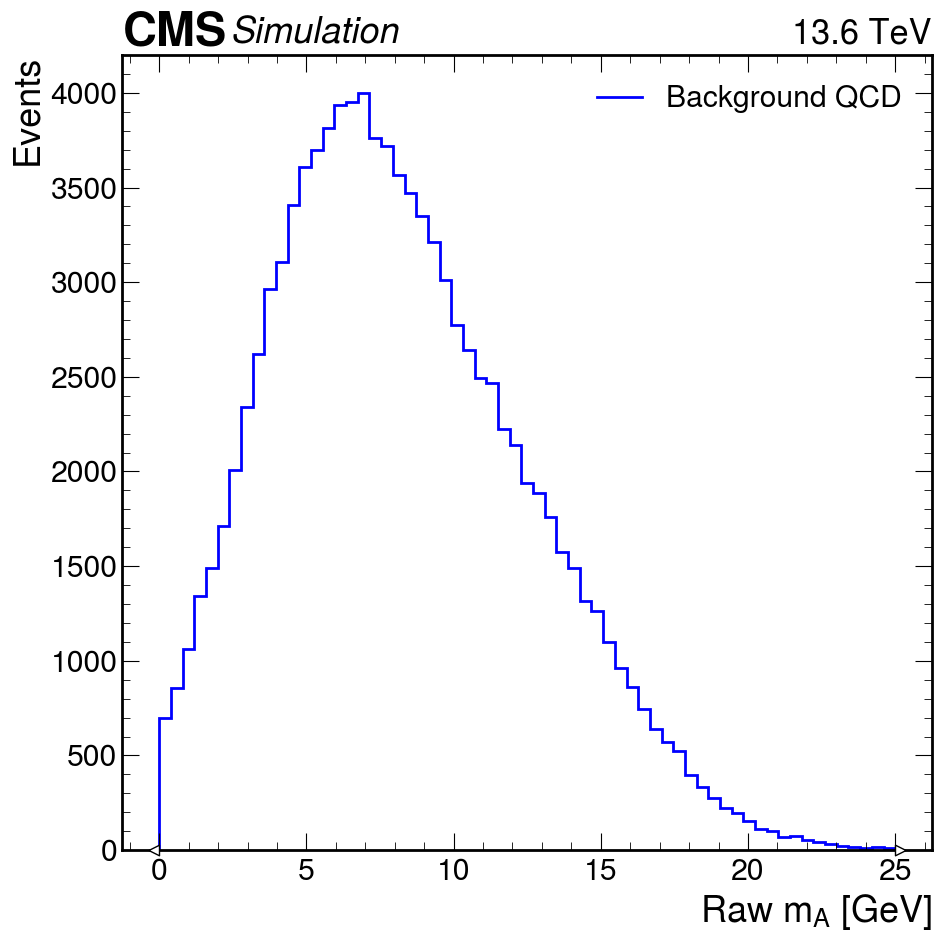

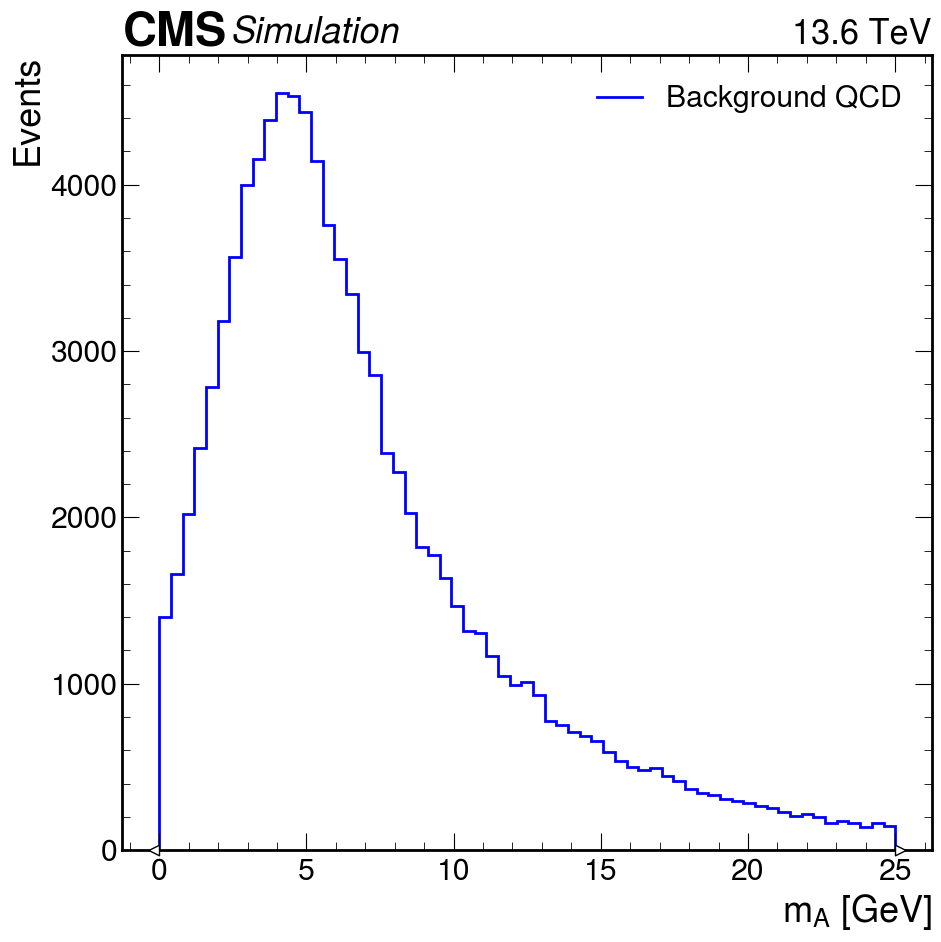

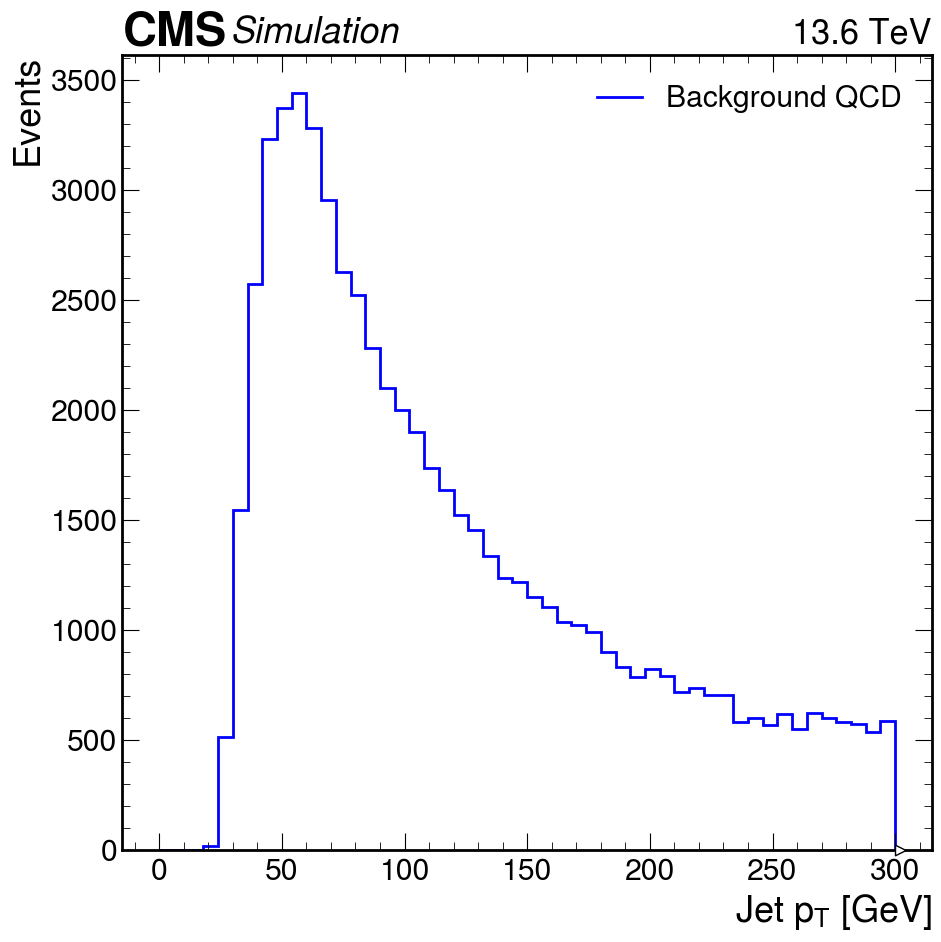

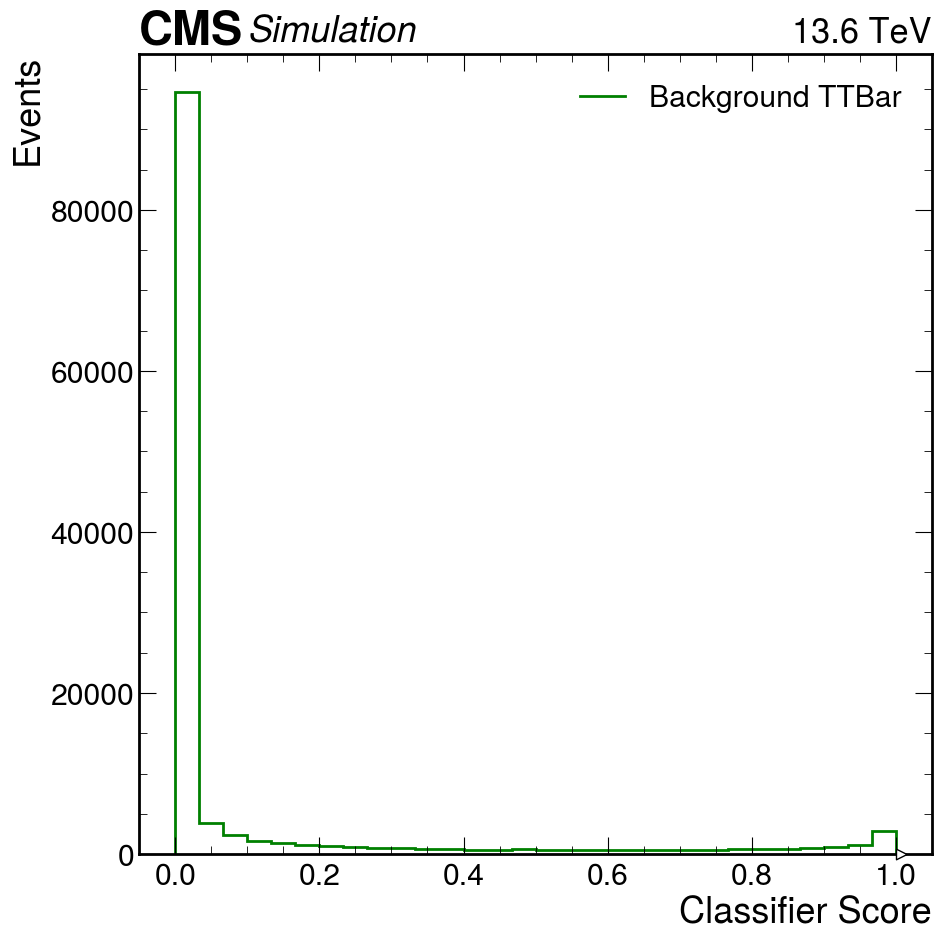

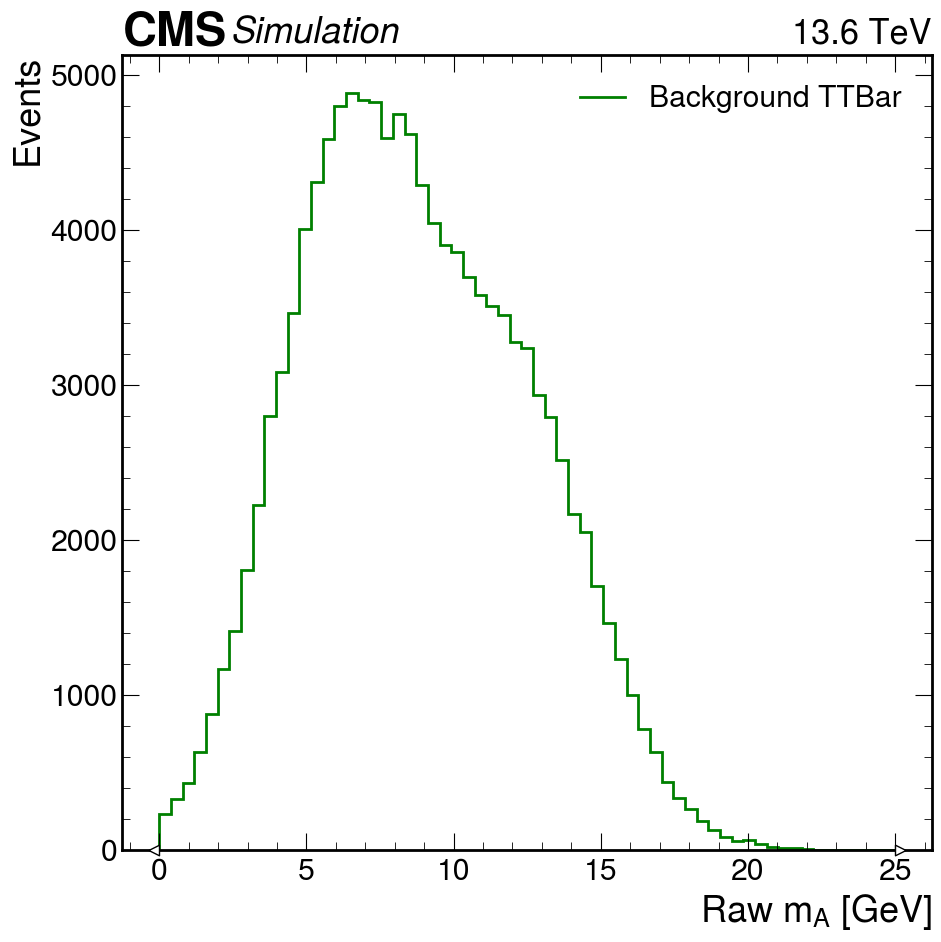

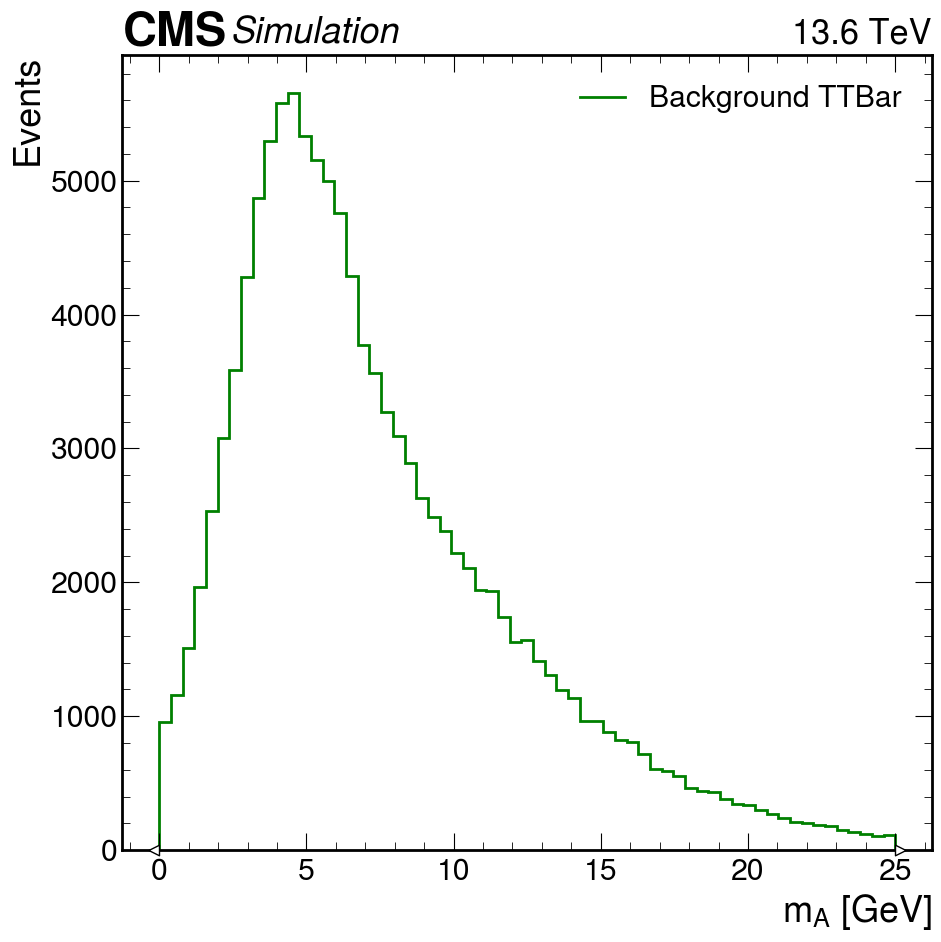

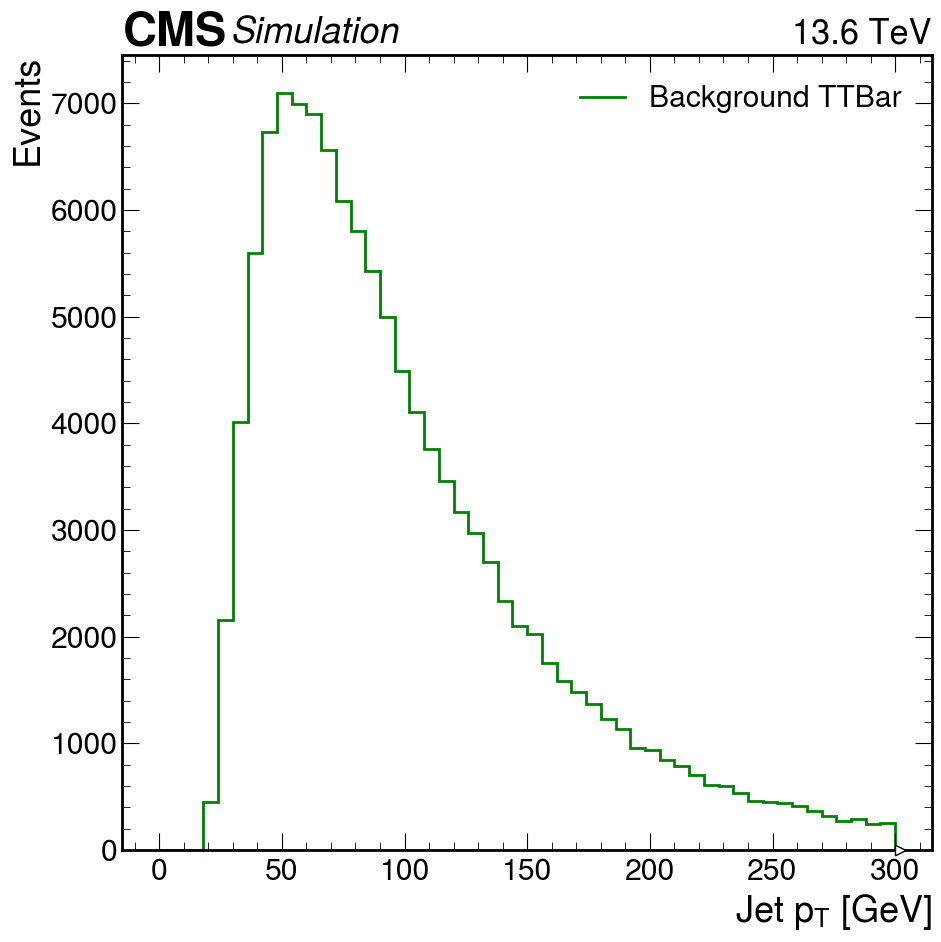

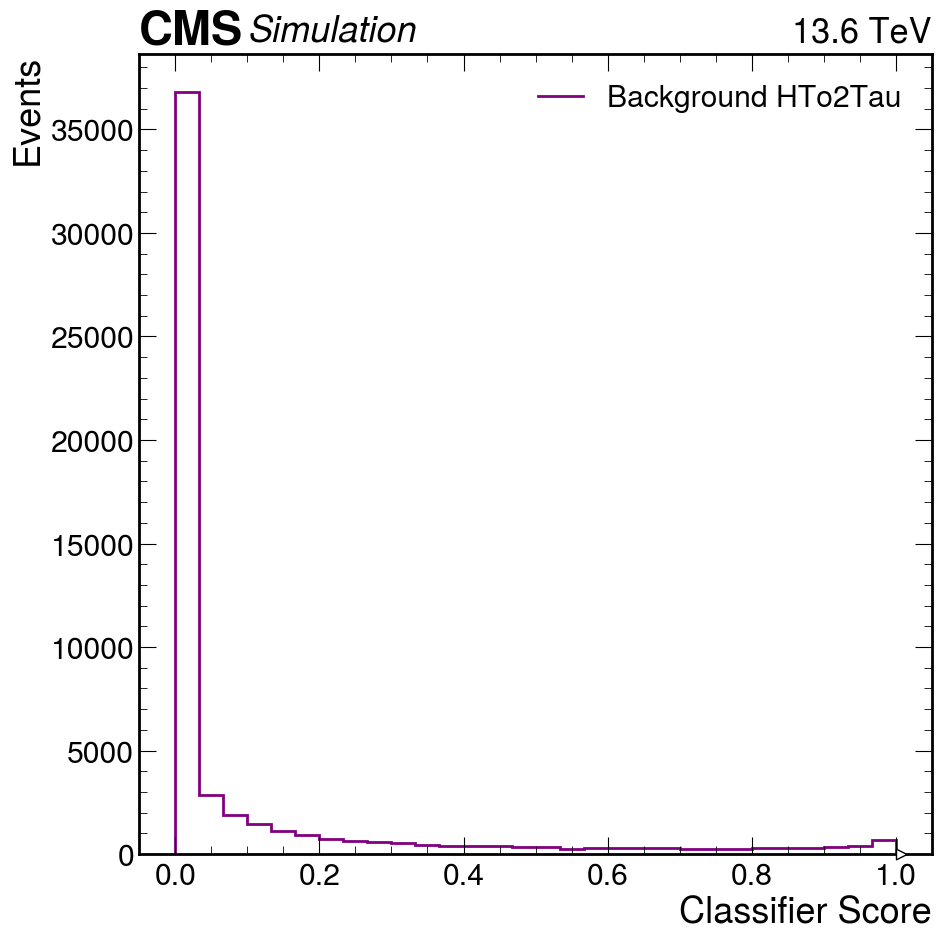

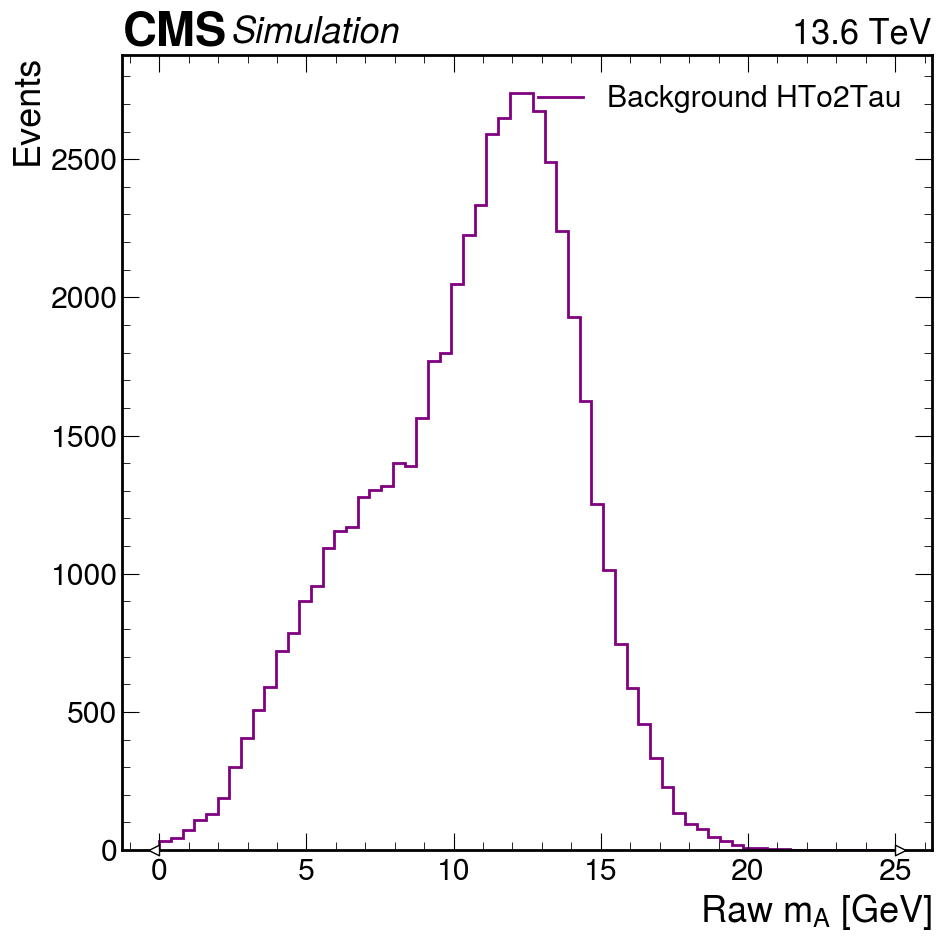

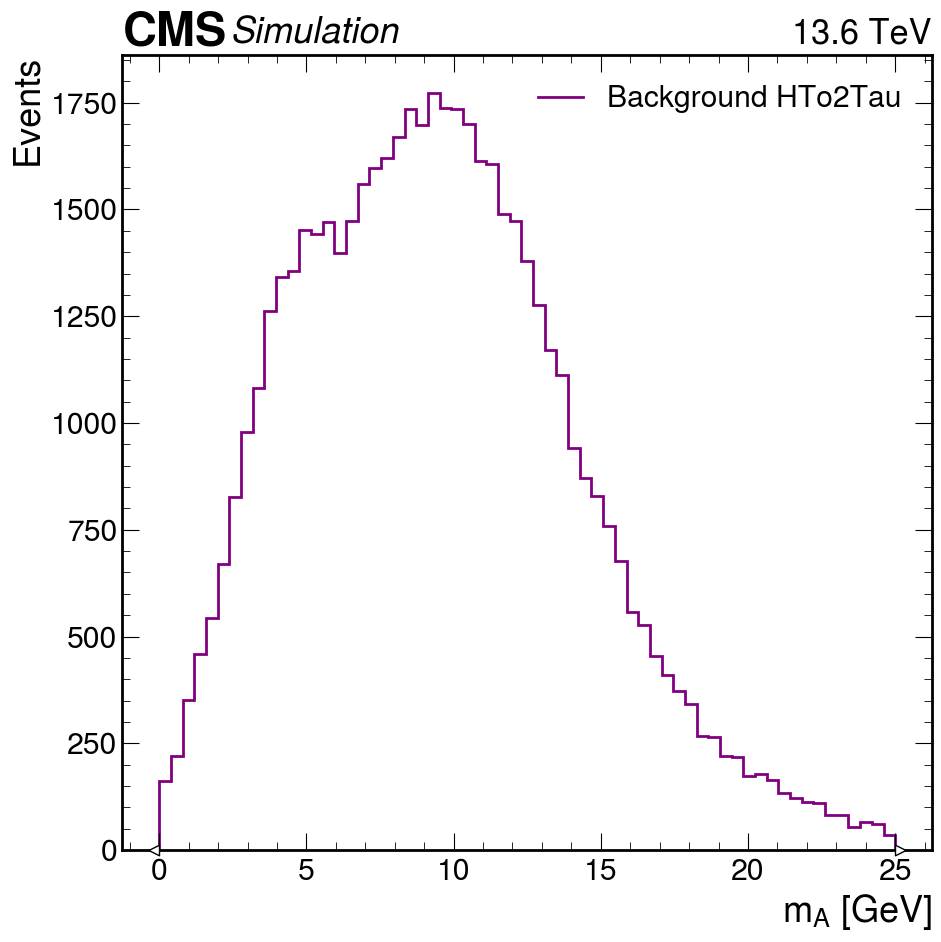

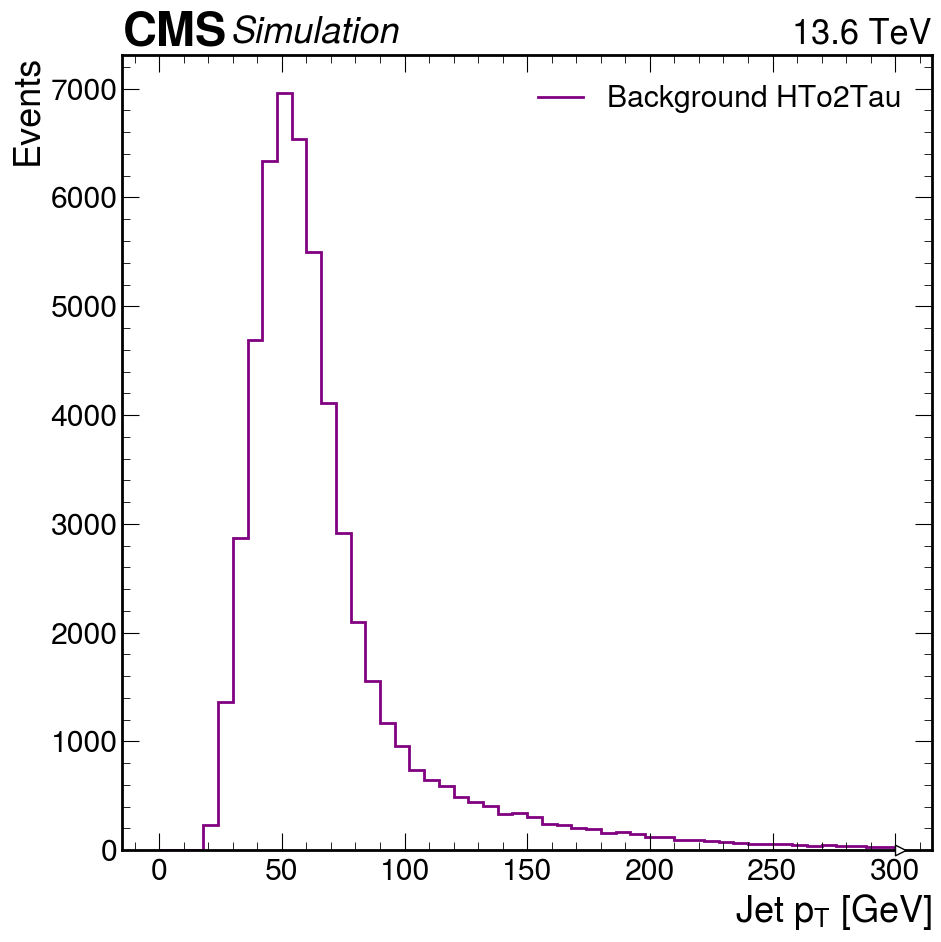

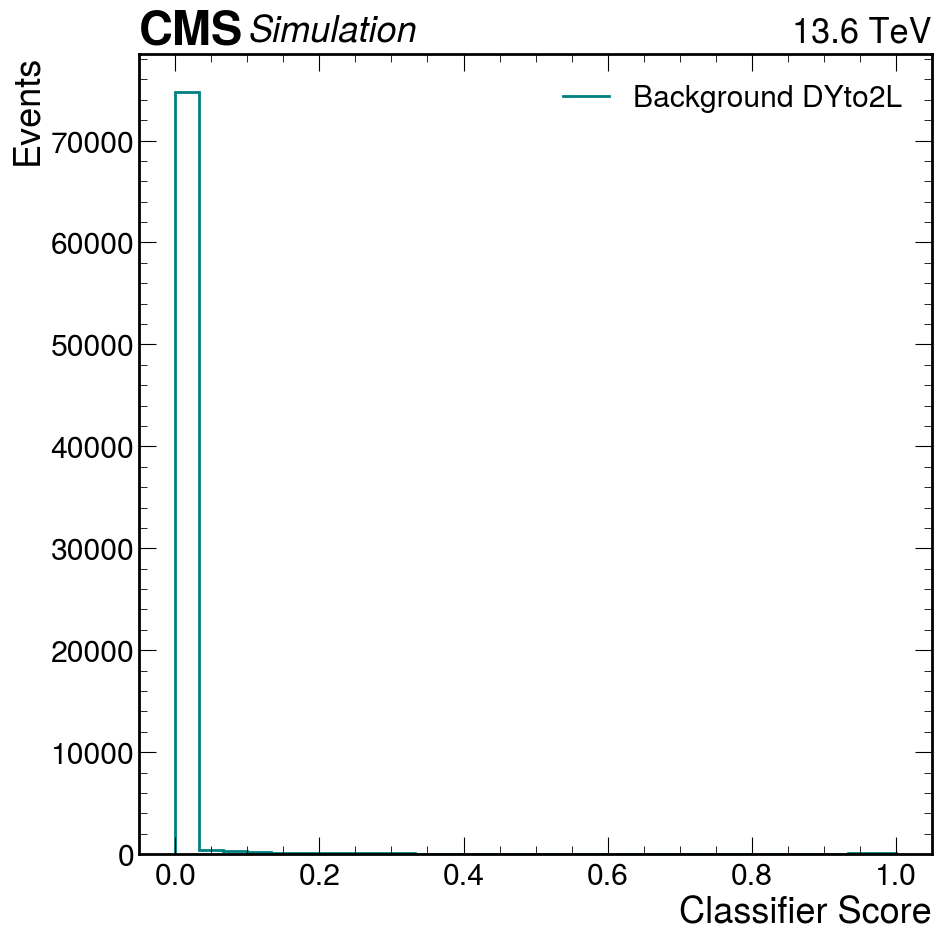

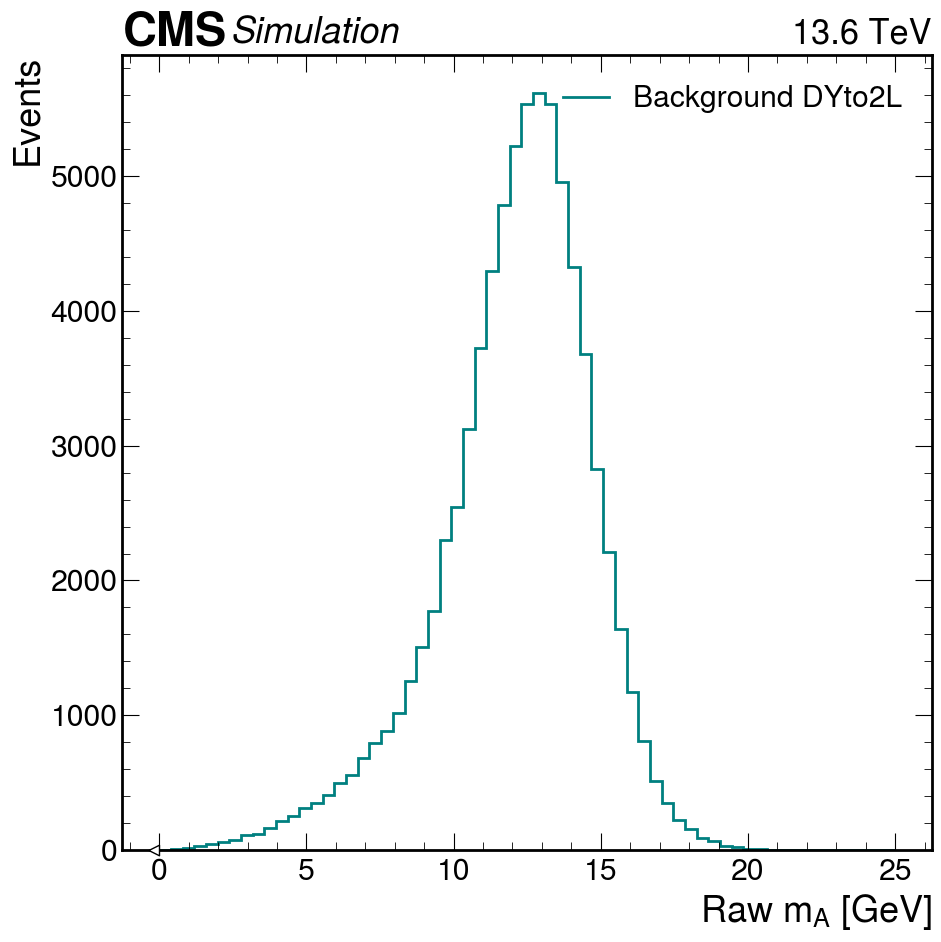

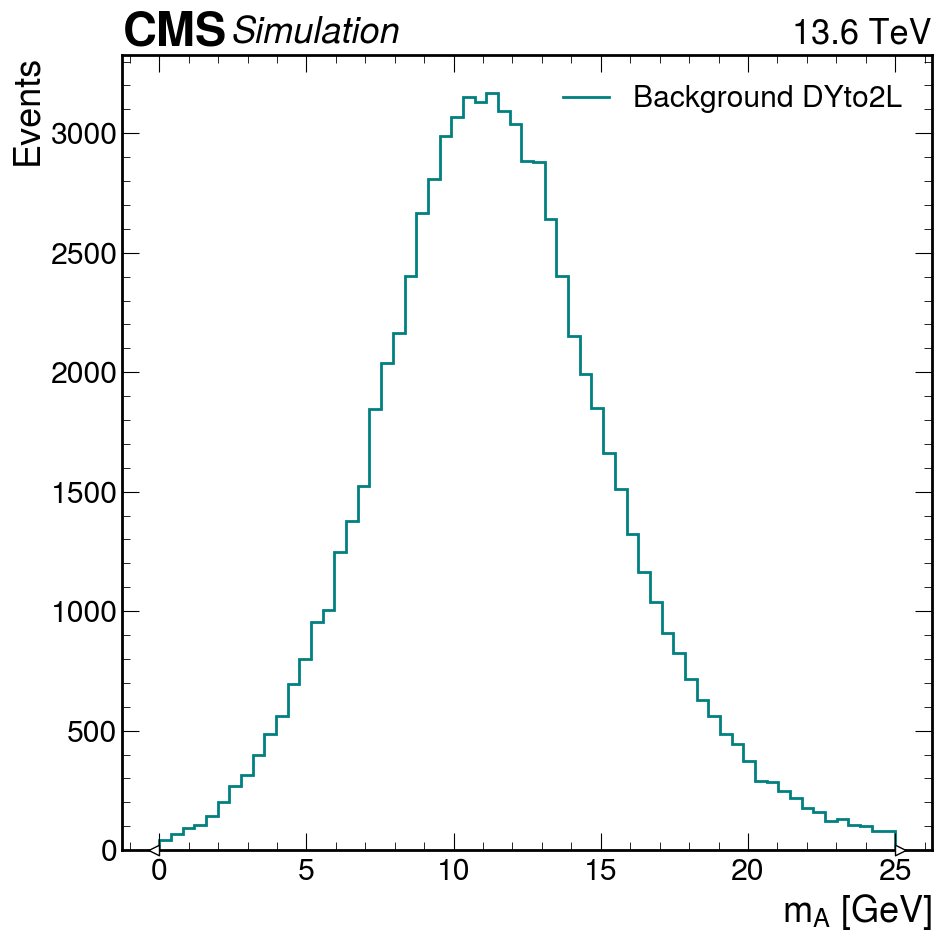

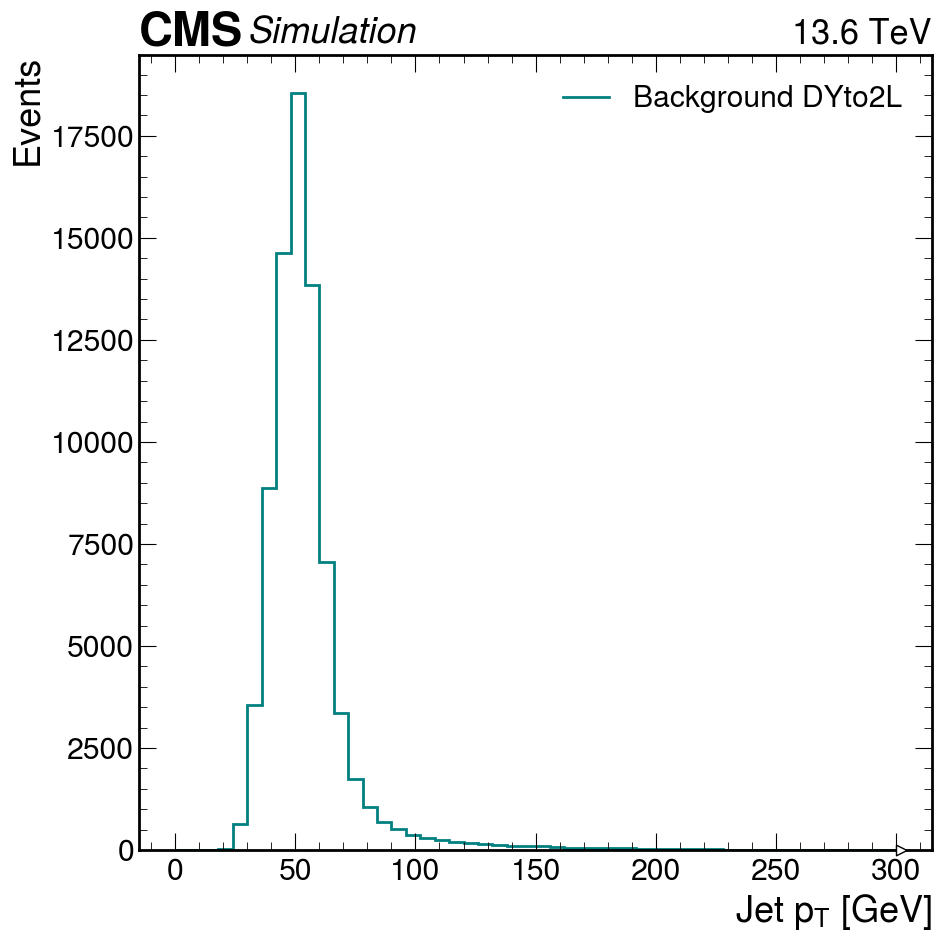

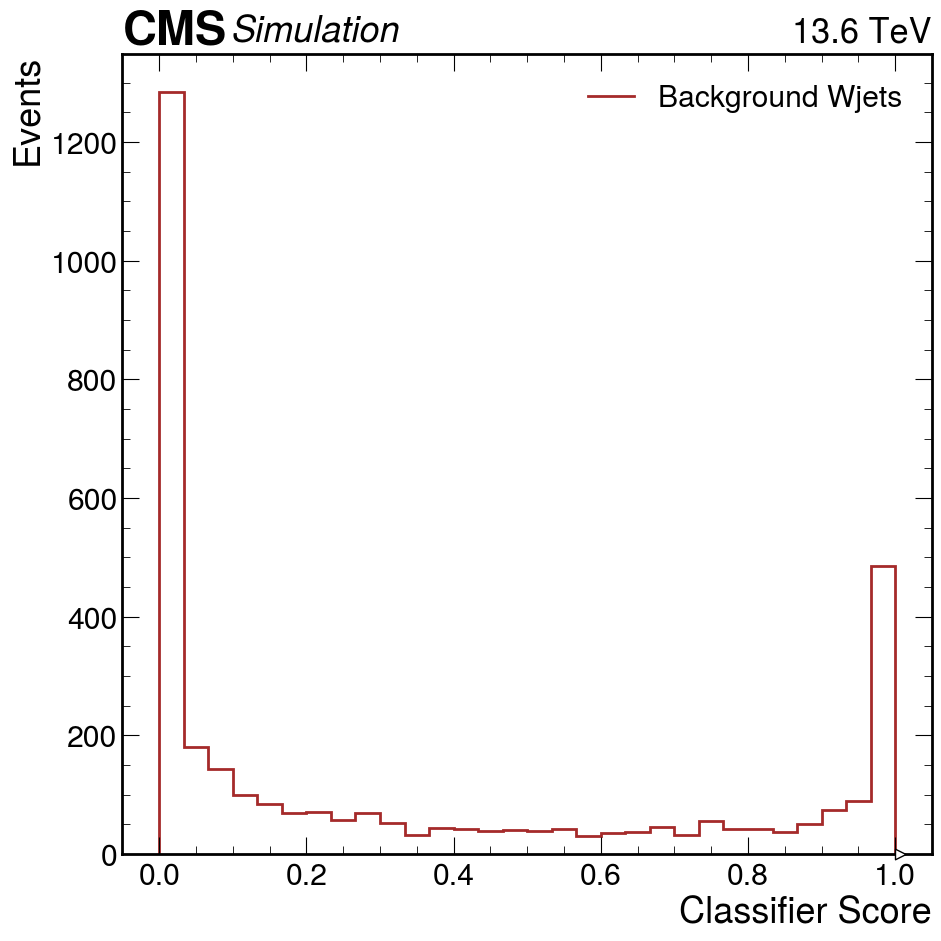

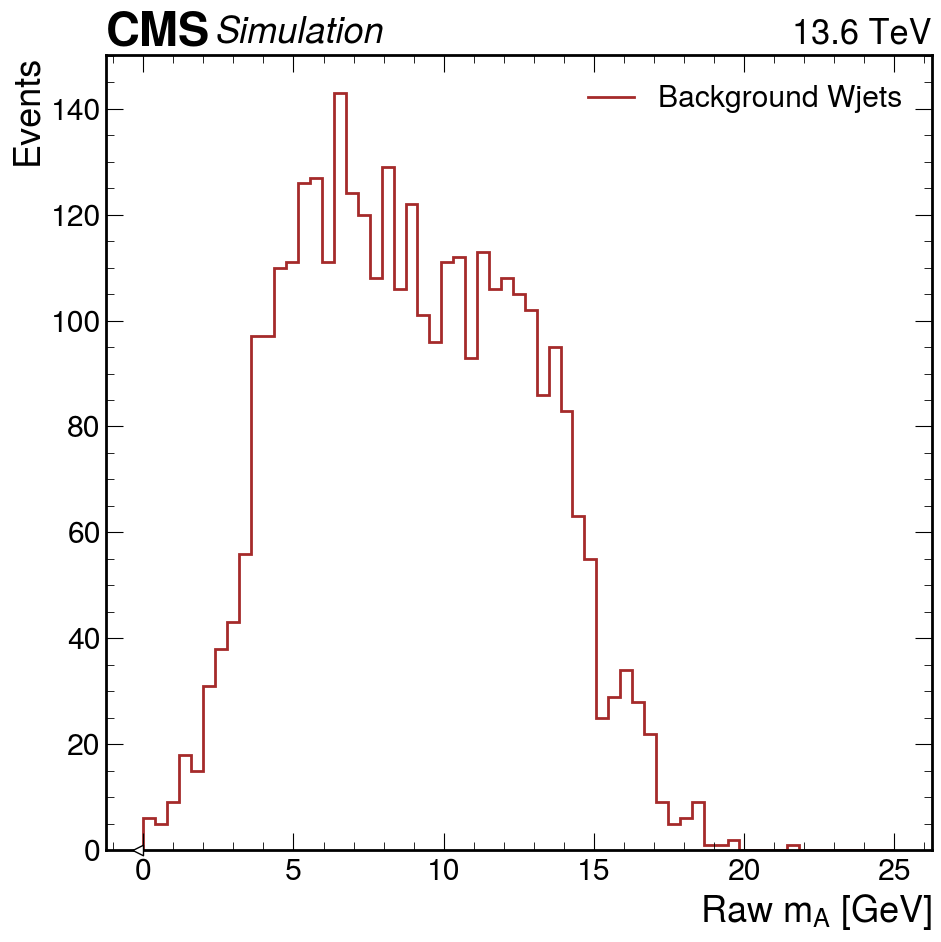

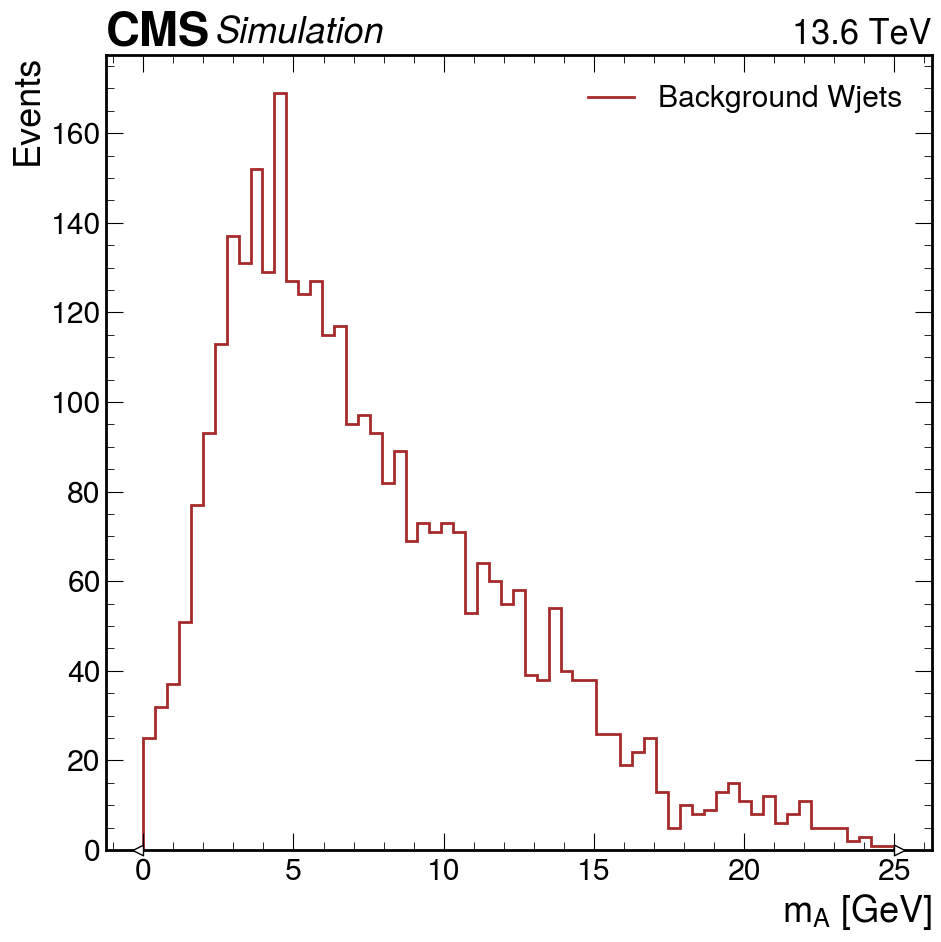

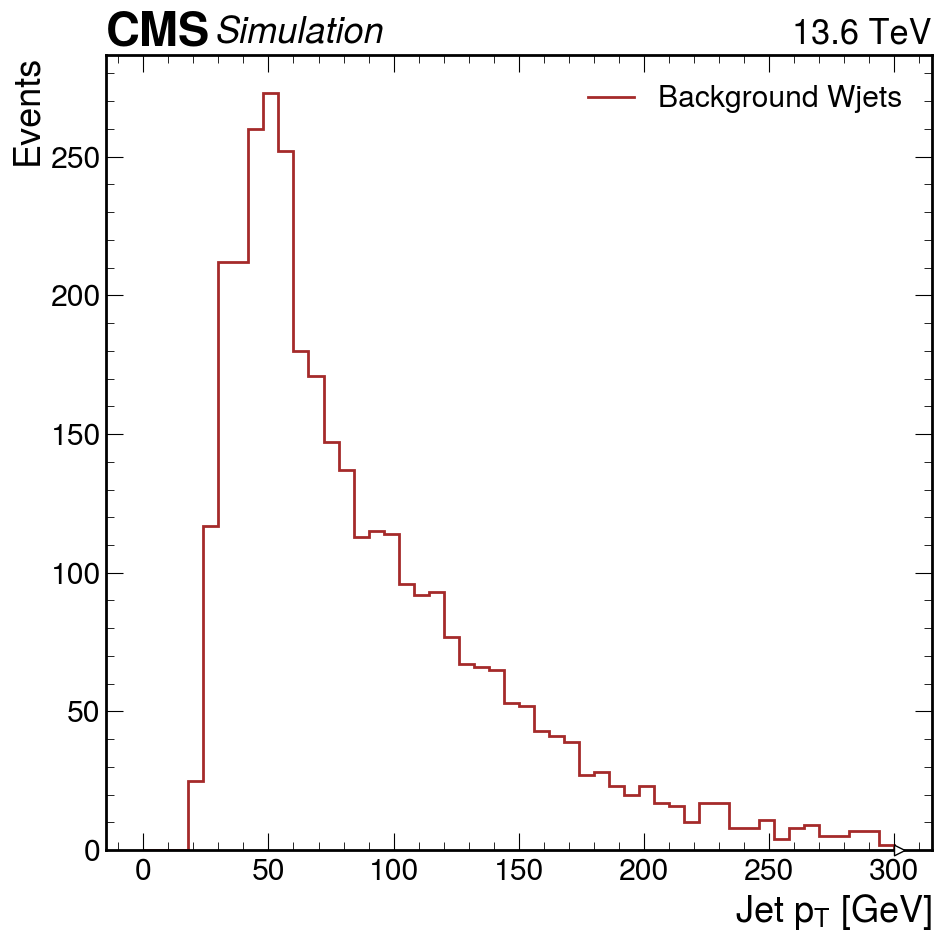

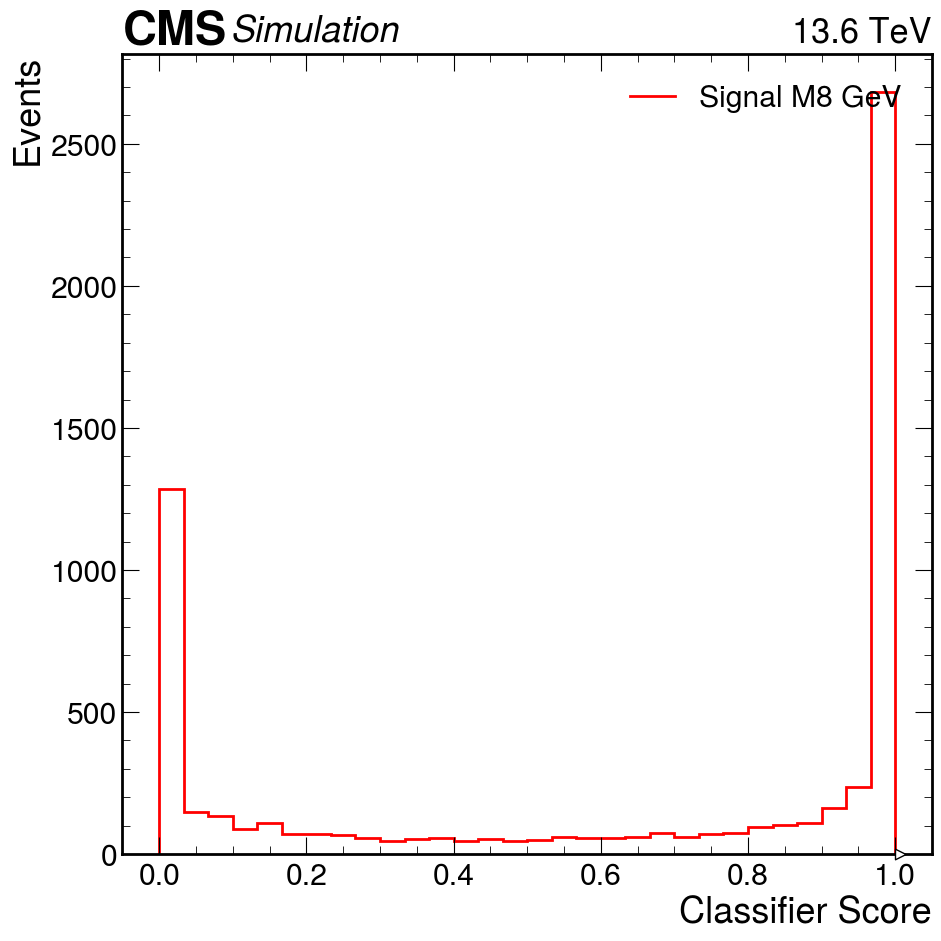

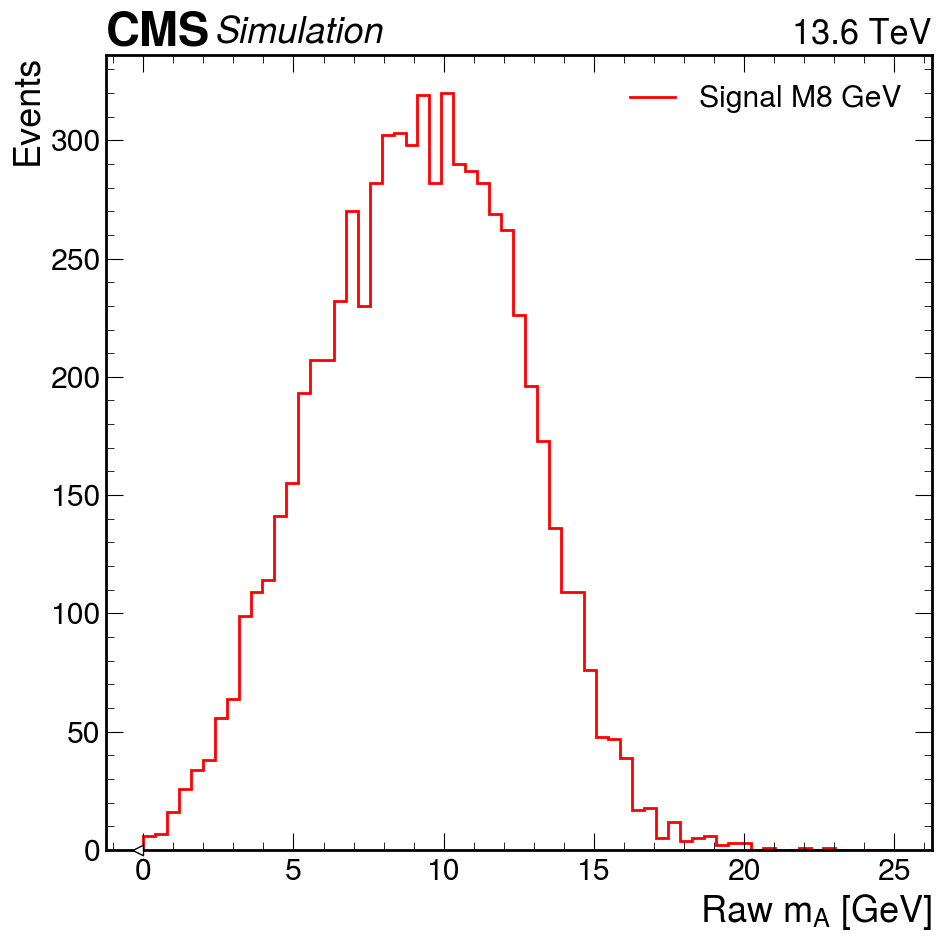

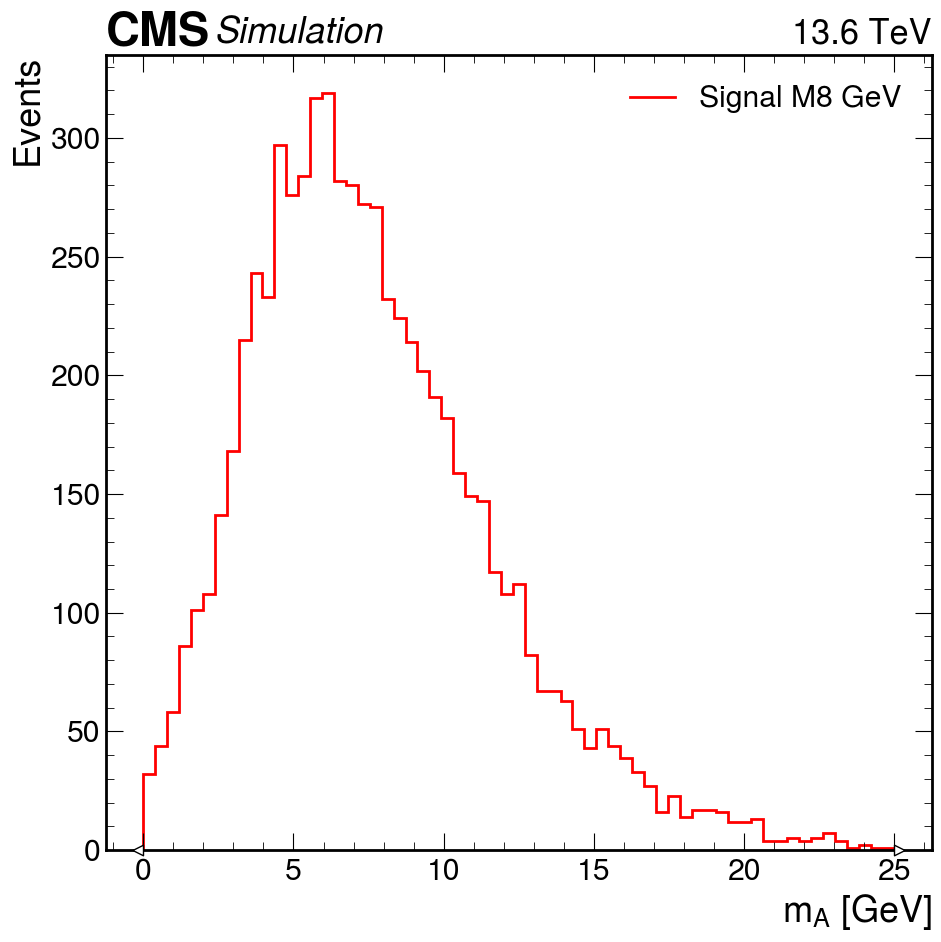

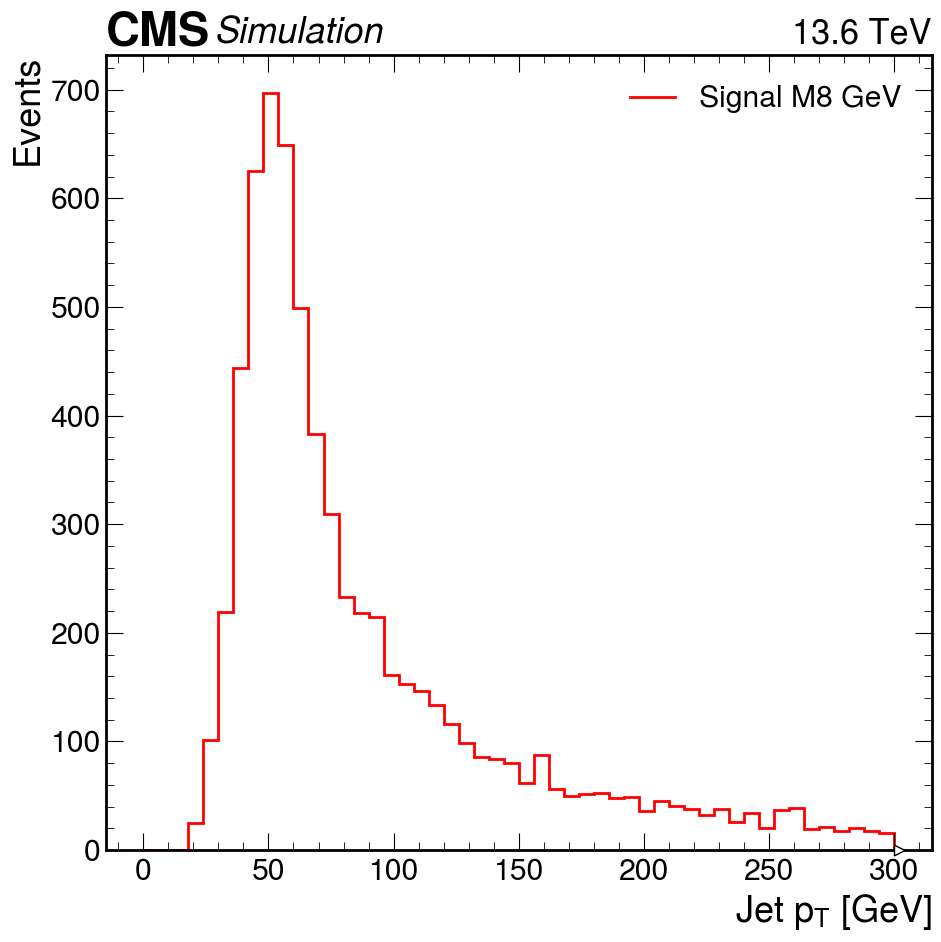

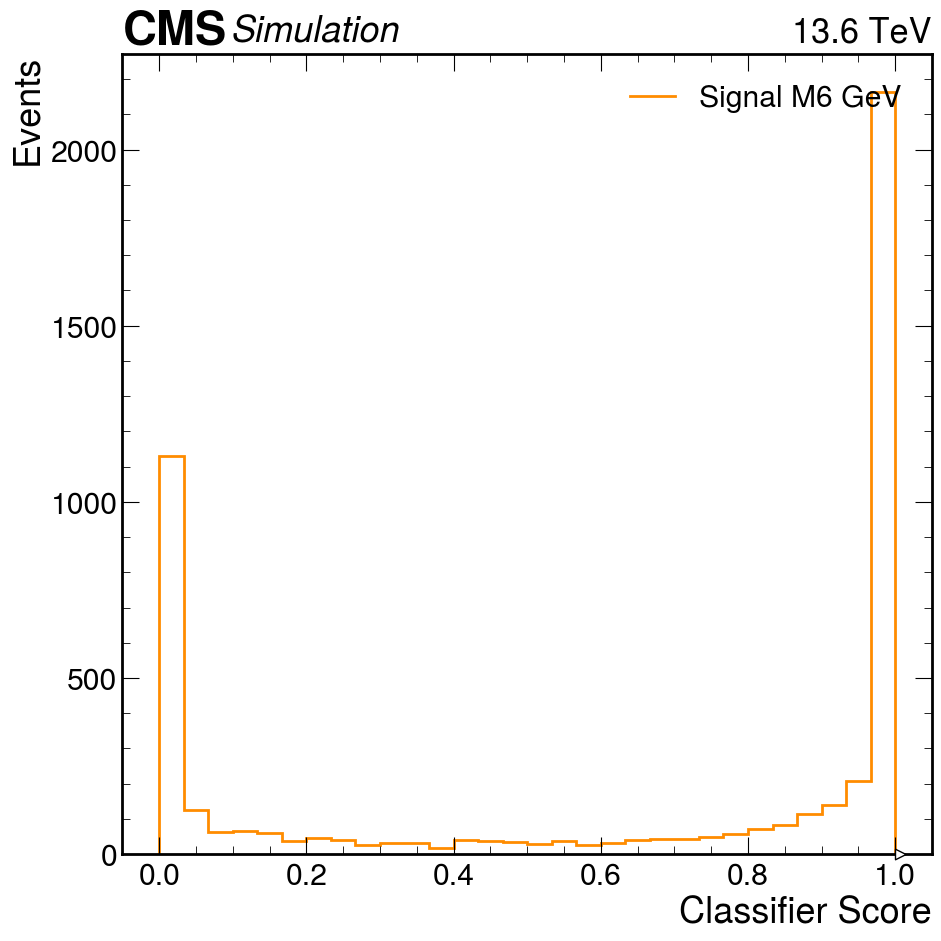

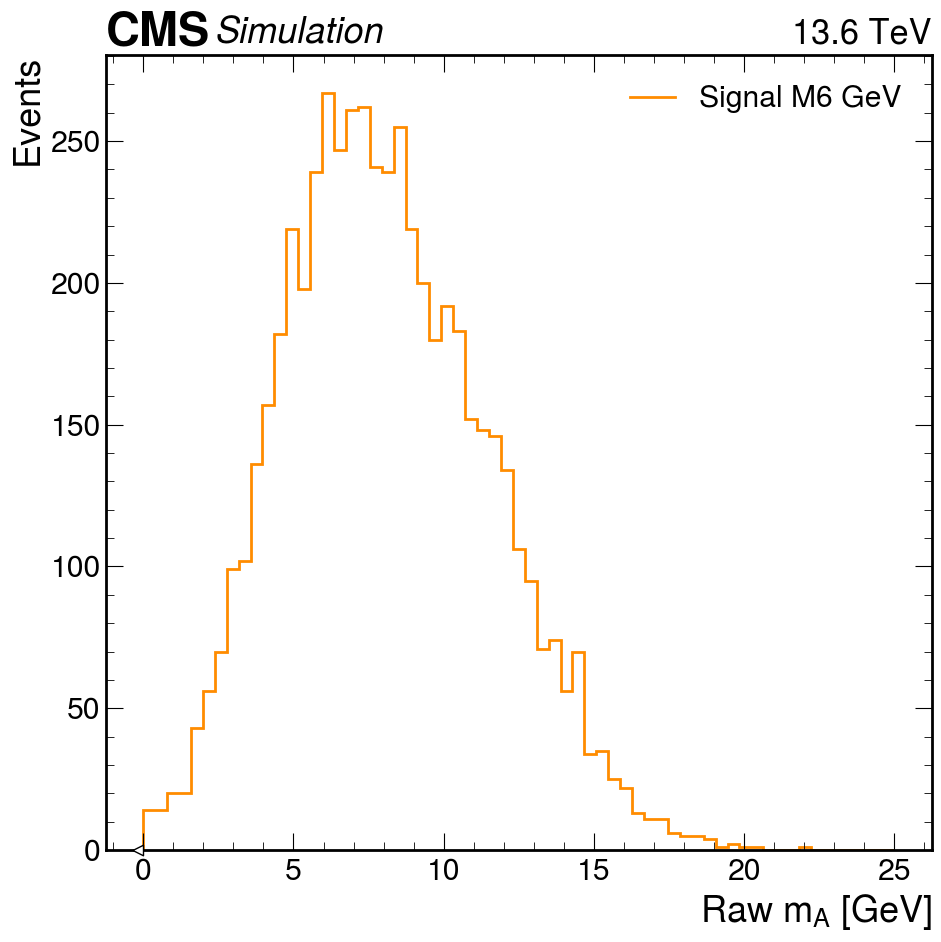

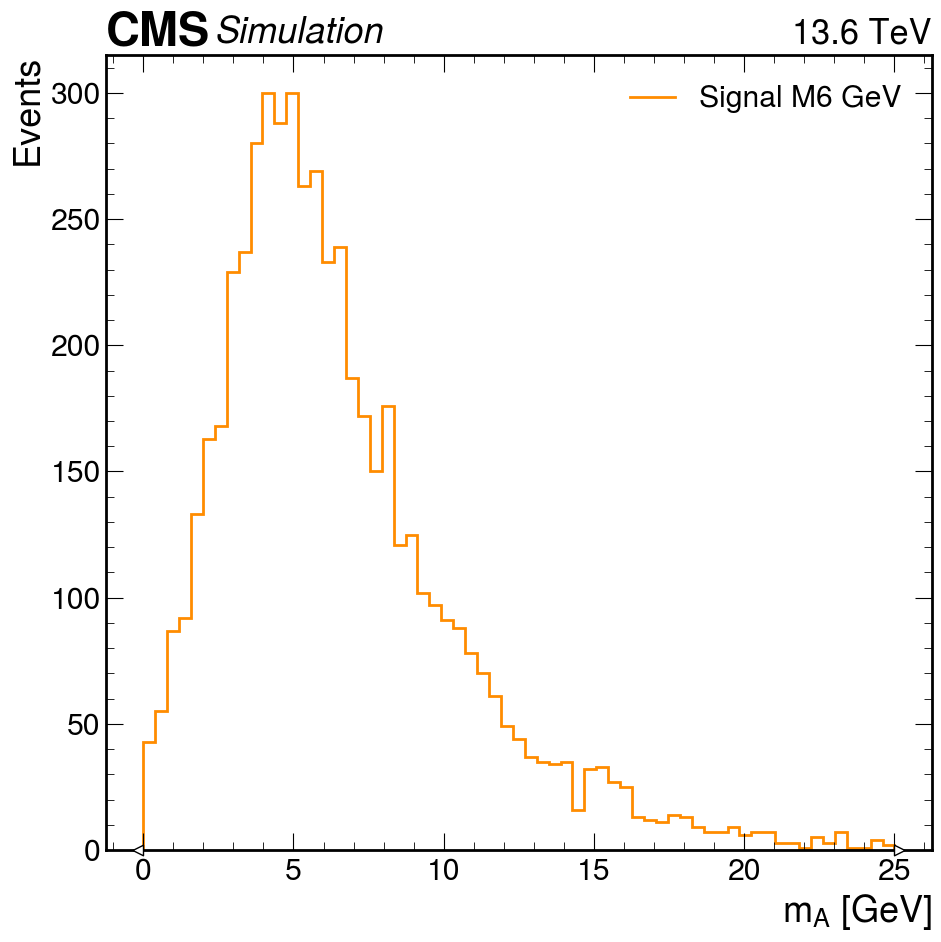

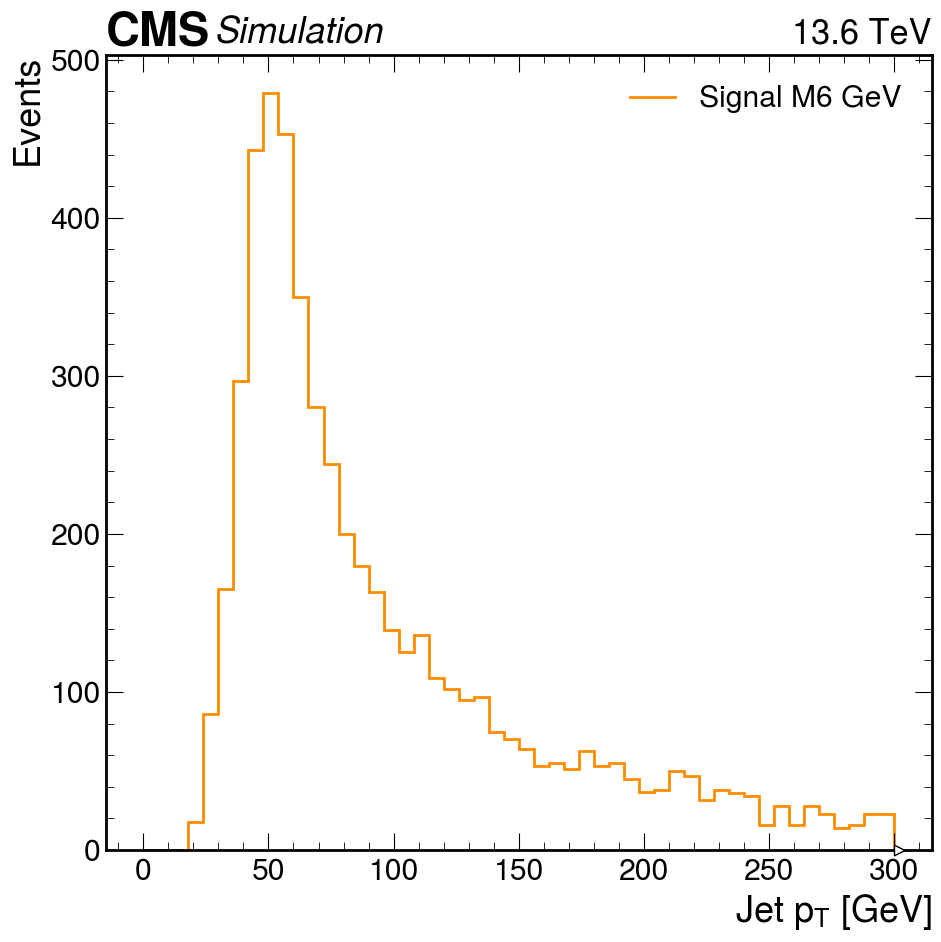

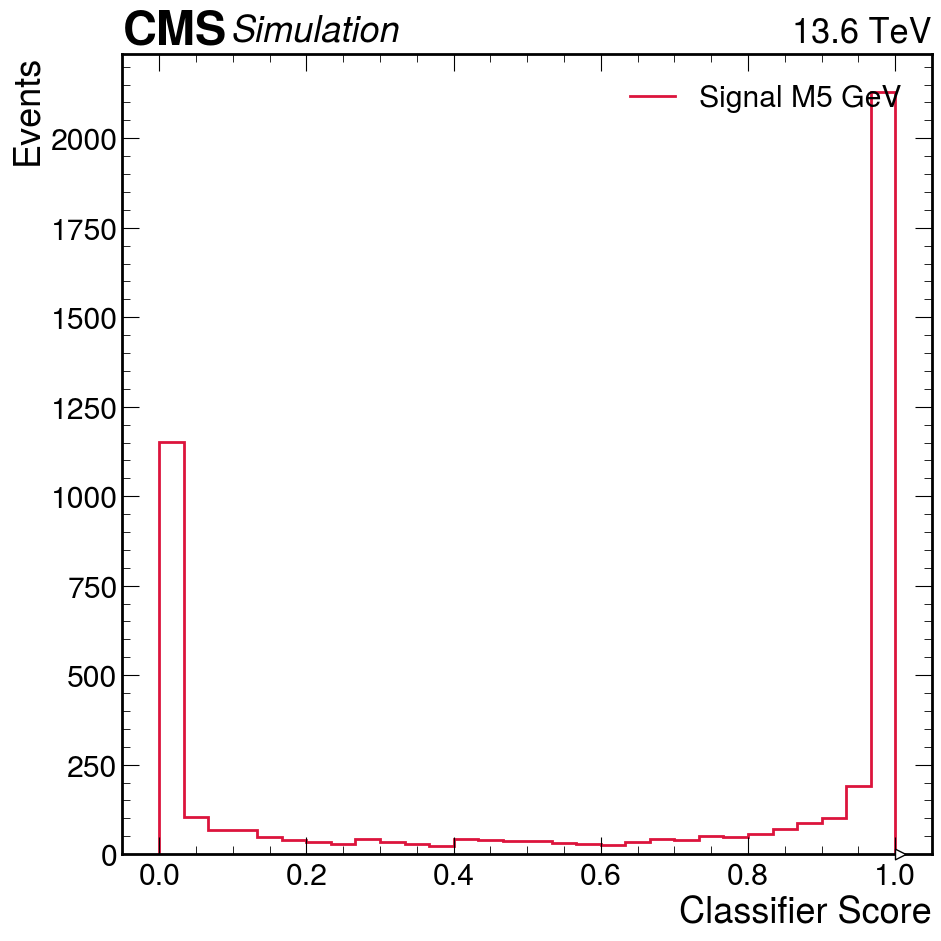

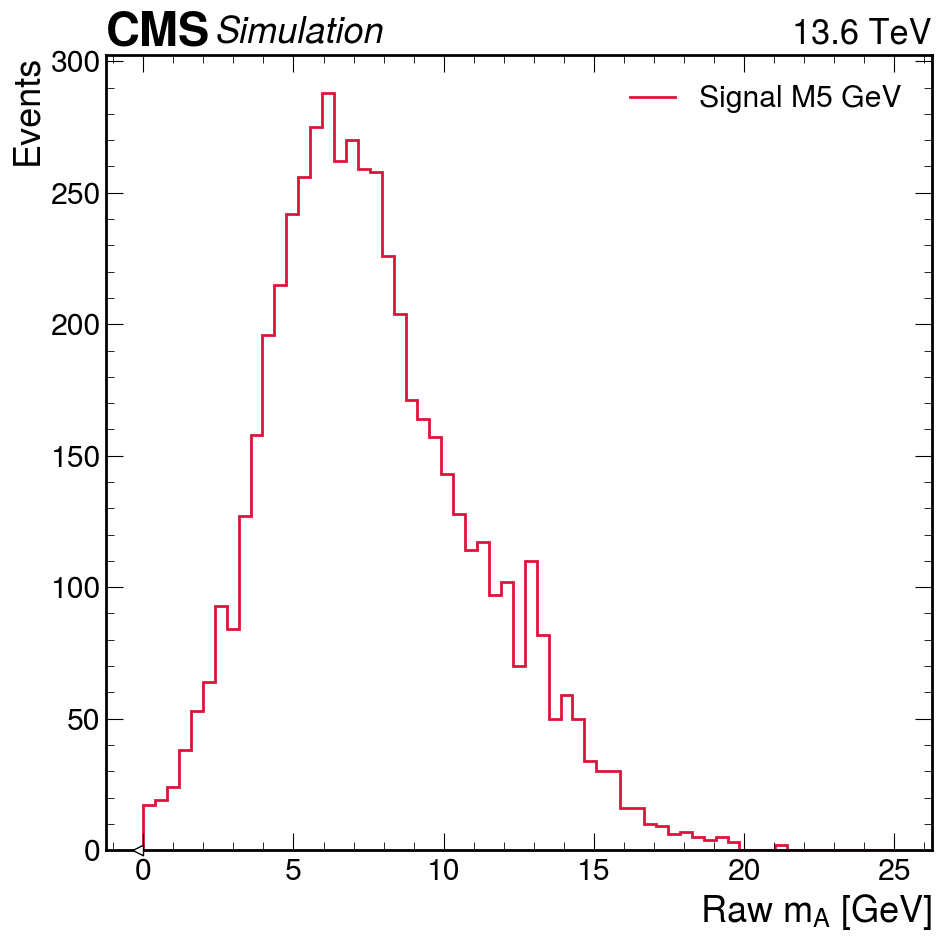

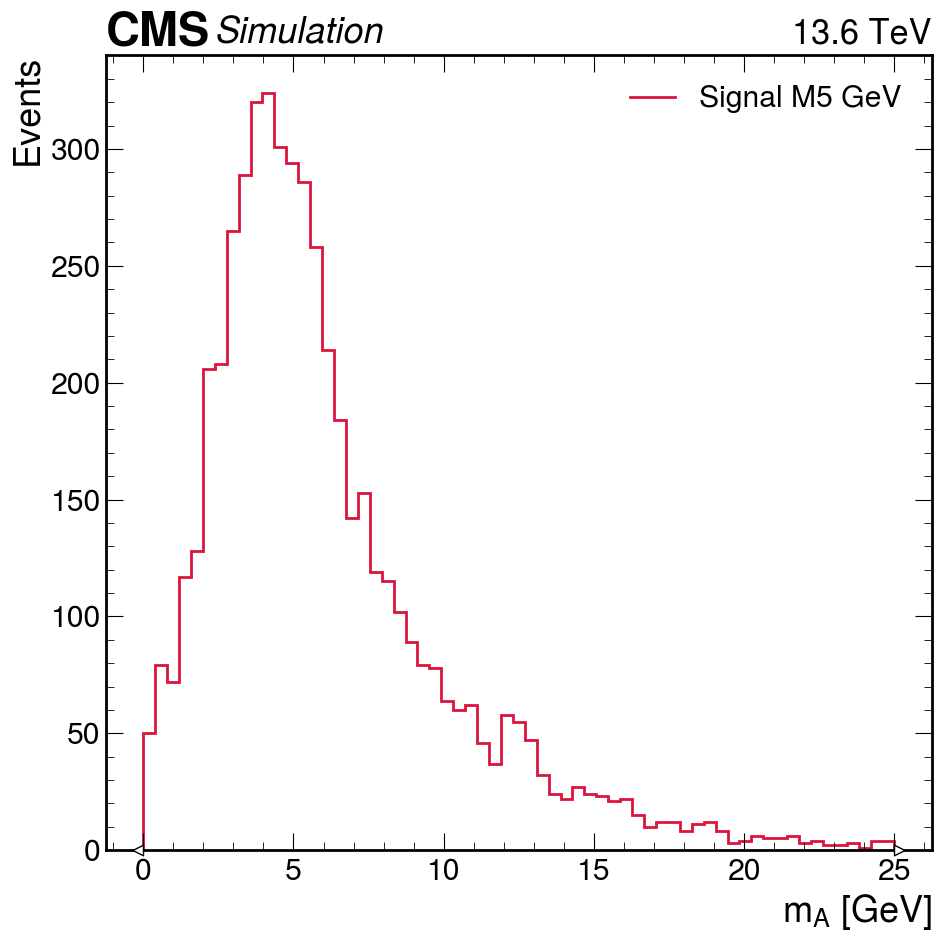

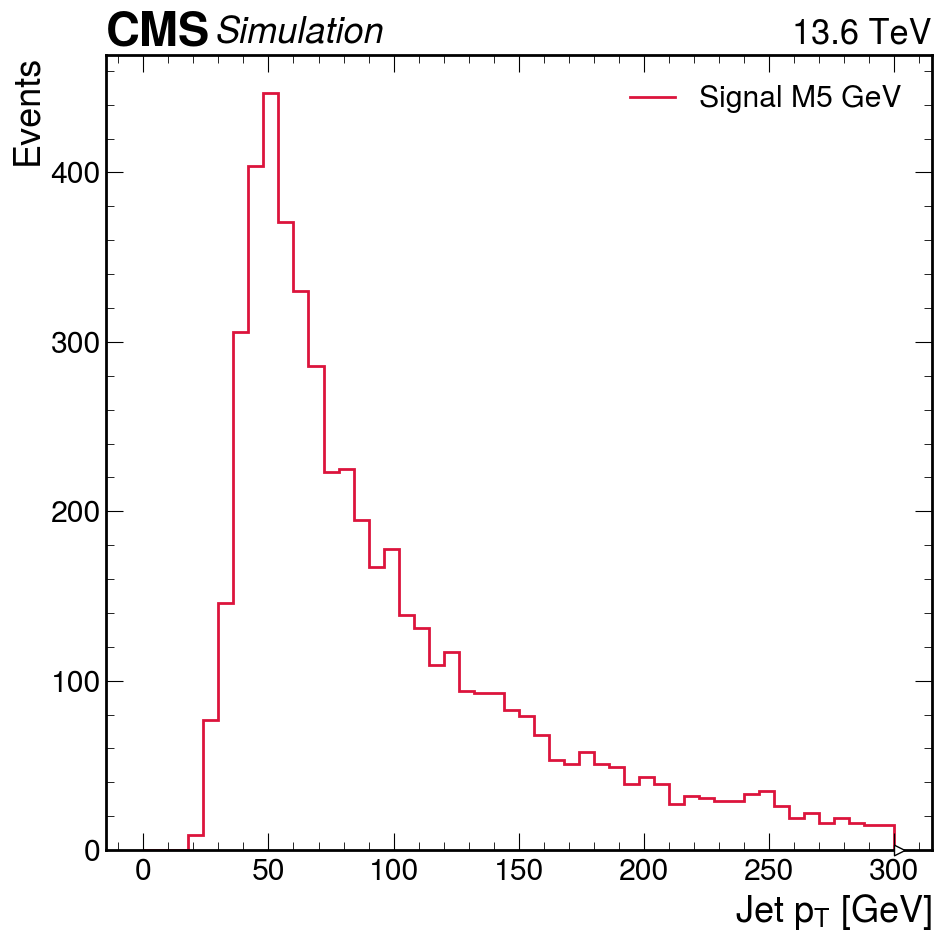

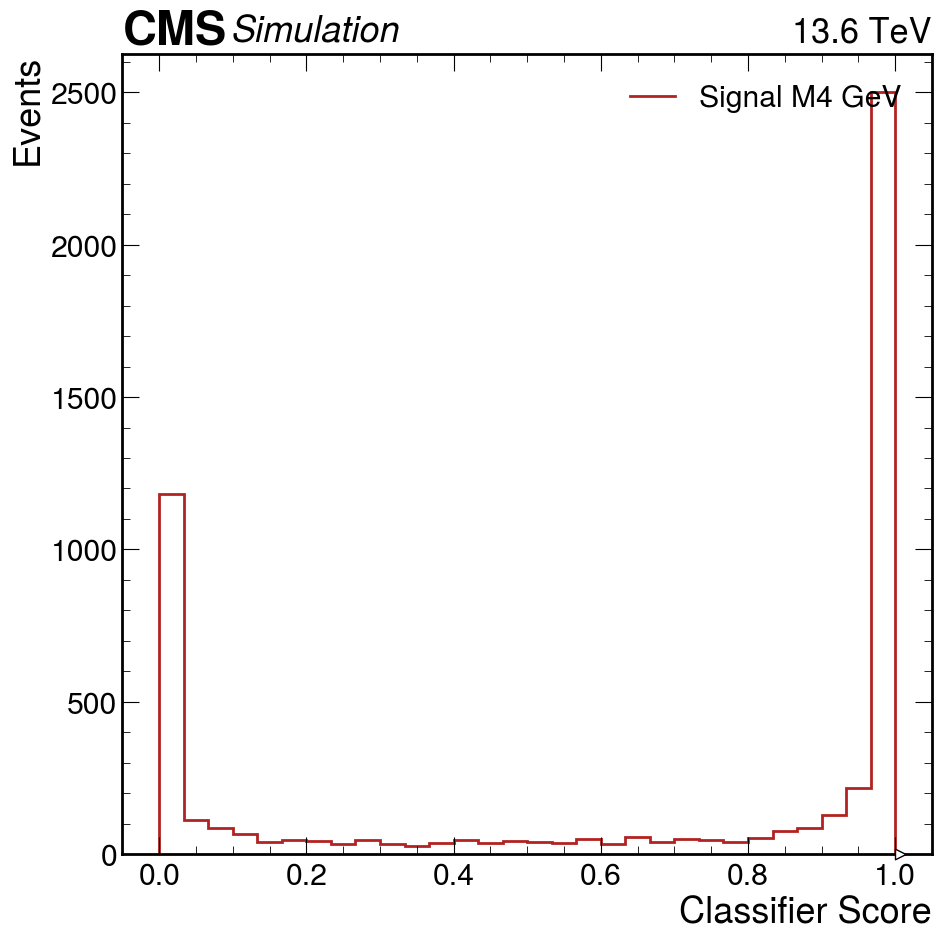

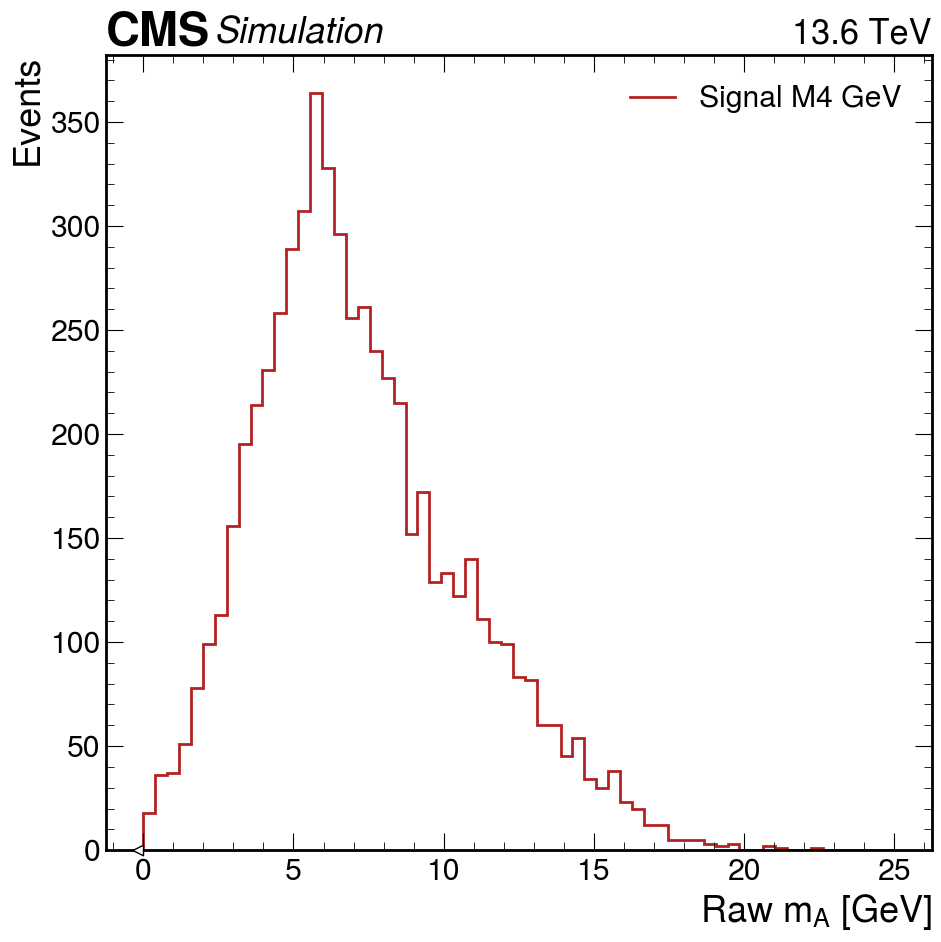

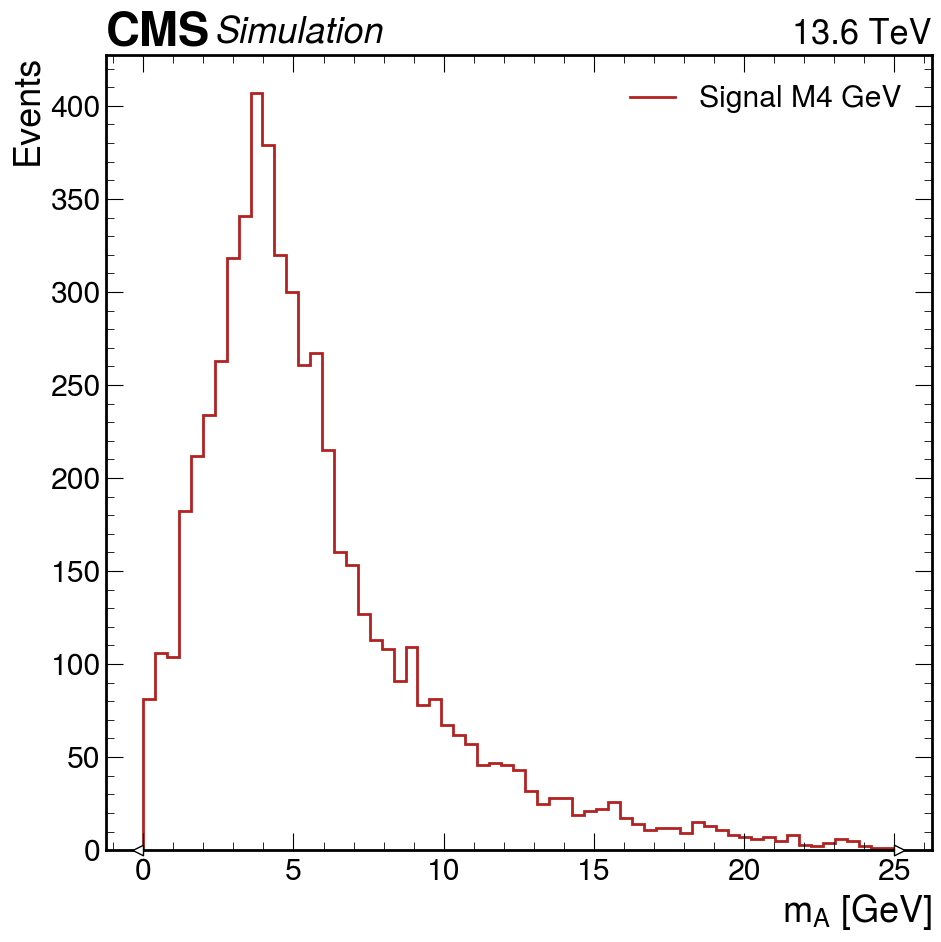

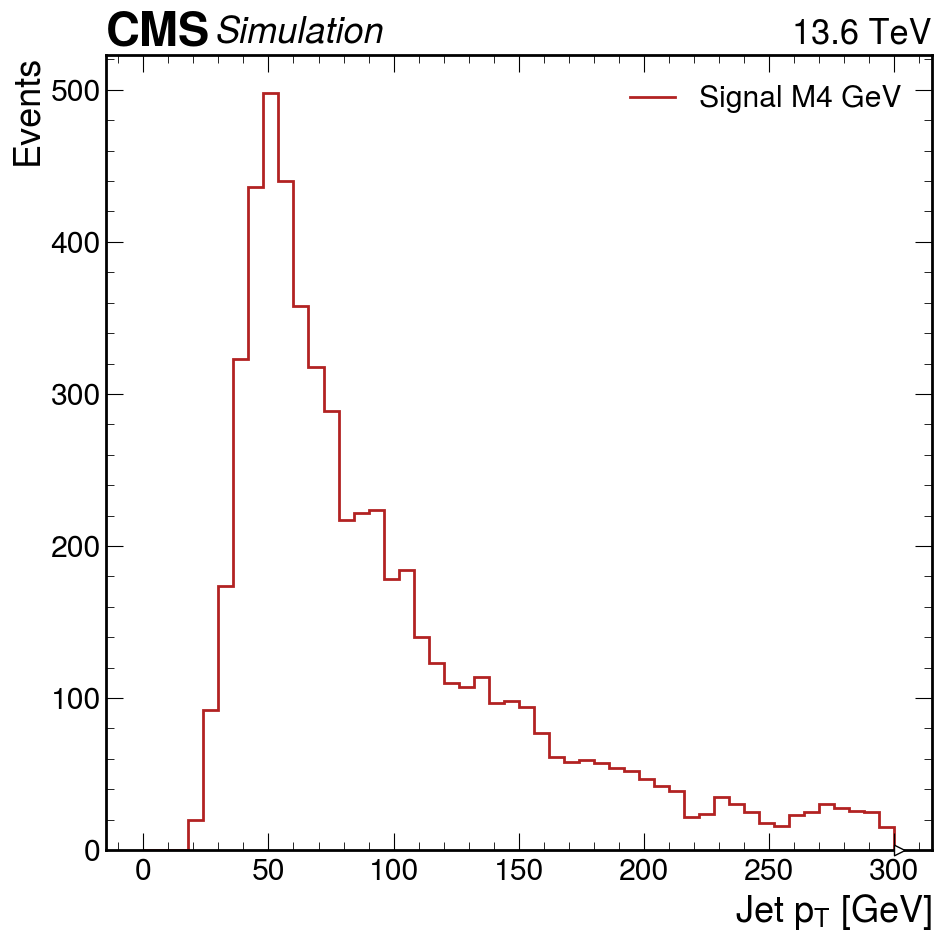

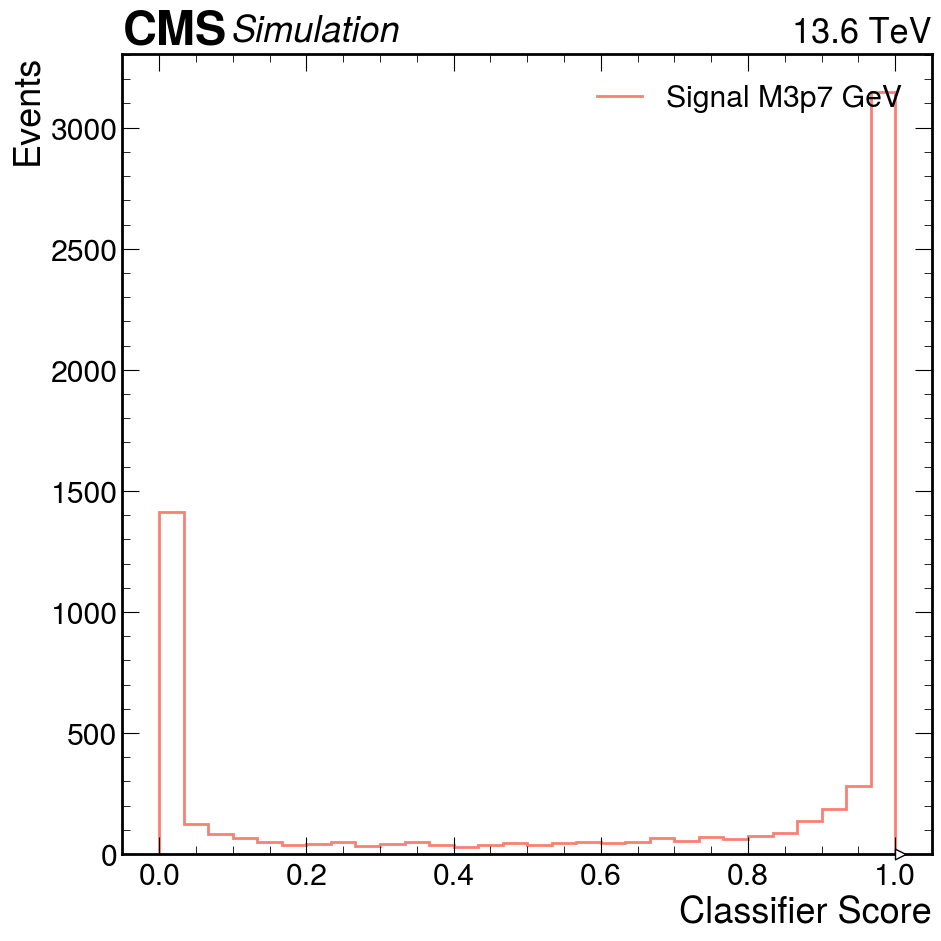

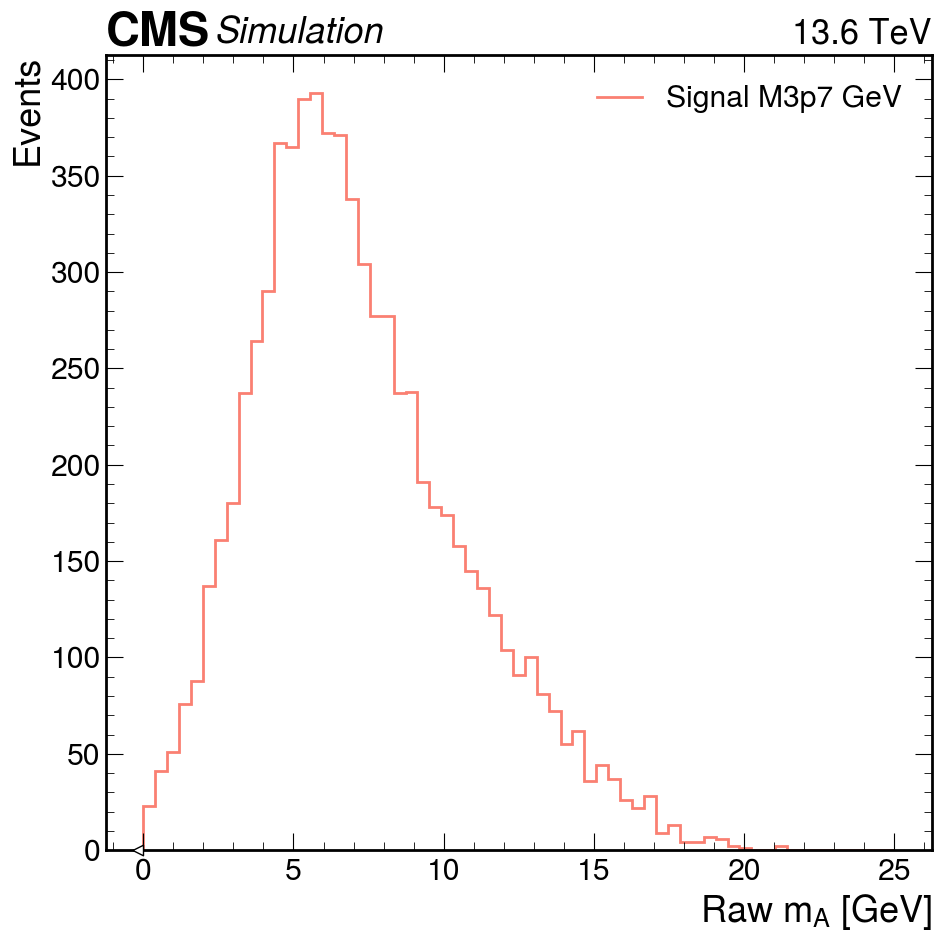

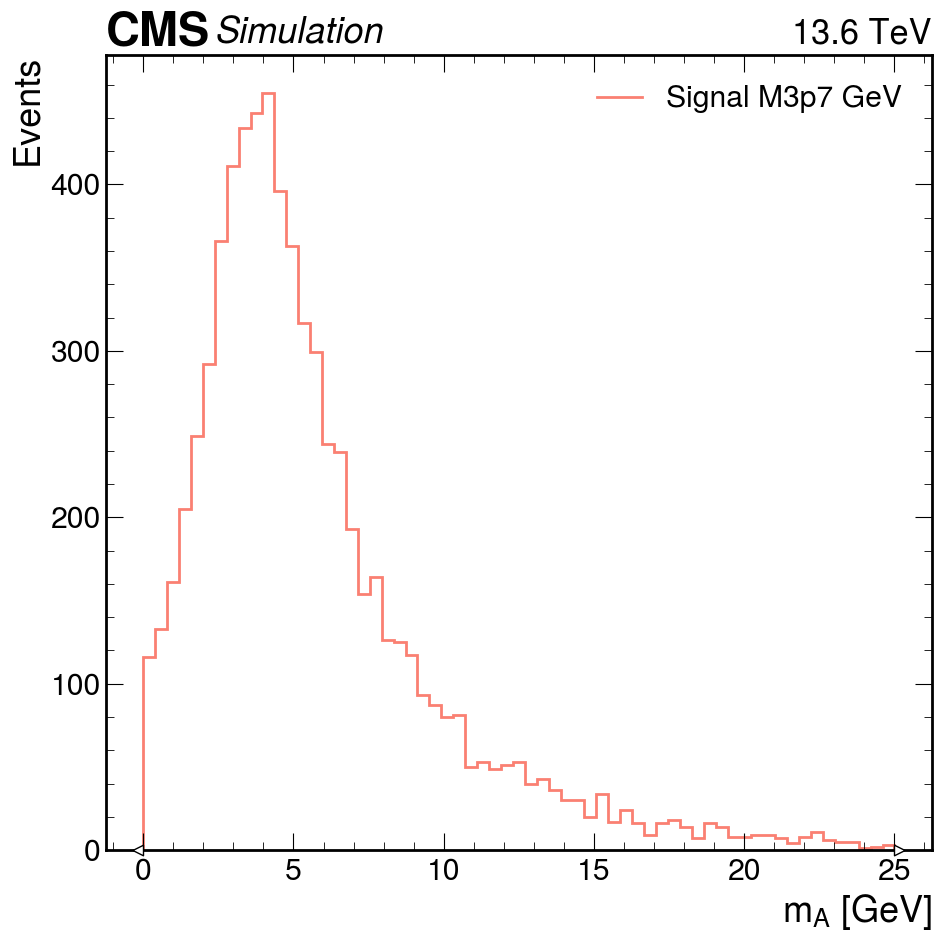

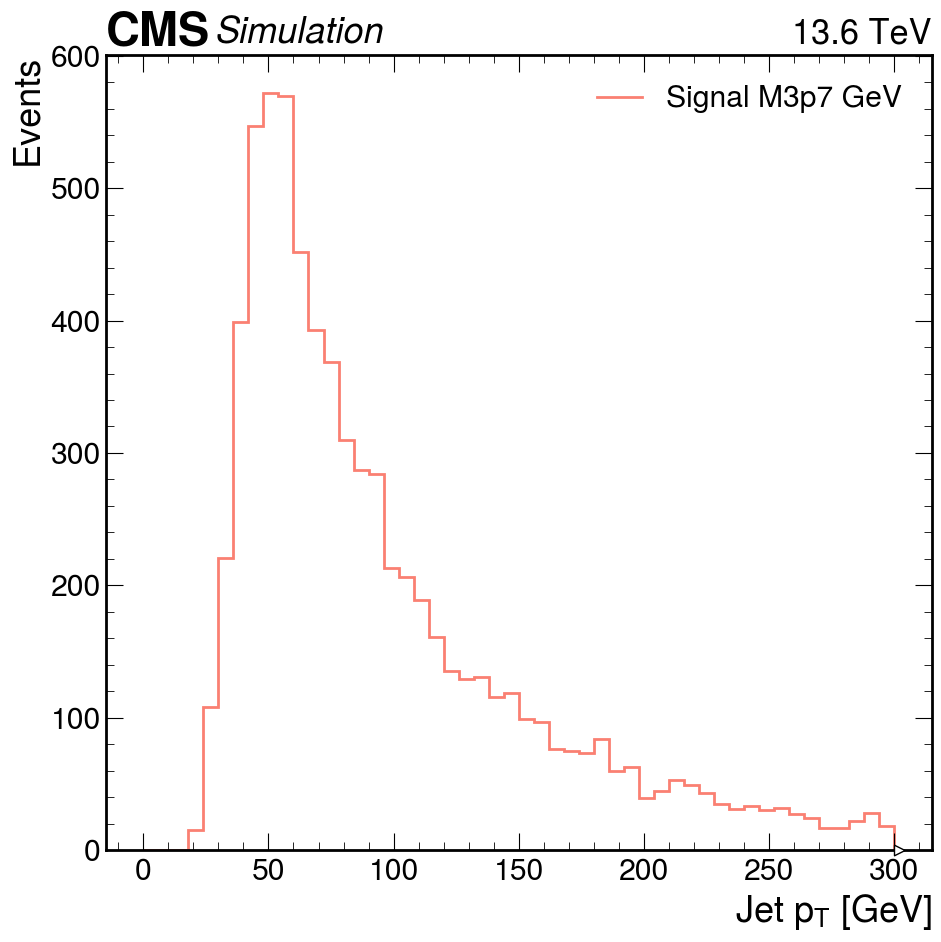

All plots saved under '../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check/', filenames encode dataset + histogram type.


In [52]:
plt.style.use(hep.style.CMS)
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check"
os.makedirs(outdir, exist_ok=True)

signal_colors = ["red", "darkorange", "crimson", "firebrick", "salmon", "tomato"]
background_colors = ["blue", "green", "purple", "teal", "brown", "magenta"]
sig_idx = 0
bkg_idx = 0

def clean_label(name):
    return name.replace("_with_mass_classifier_infernce_miniAOD_June15", "").replace("_", " ")

for dataset_name, dataset_output in out.items():
    is_data = dataset_name.startswith("data")

    if dataset_name.startswith("Signal"):
        color = signal_colors[sig_idx % len(signal_colors)]
        sig_idx += 1
        process_label = clean_label(dataset_name)
        dataset_tag = dataset_name.replace("_with_mass_classifier_infernce_miniAOD_June15", "")
    elif dataset_name.startswith("Background"):
        color = background_colors[bkg_idx % len(background_colors)]
        bkg_idx += 1
        process_label = clean_label(dataset_name)
        dataset_tag = dataset_name.replace("_with_mass_classifier_infernce_miniAOD_June15", "")
    elif is_data:
        color = "black"
        process_label = "Data"
        dataset_tag = "Data"
    else:
        color = "black"
        process_label = dataset_name
        dataset_tag = dataset_name

    for name, item in dataset_output.items():
        if not hasattr(item, "plot1d"):
            continue

        fig, ax = plt.subplots()

        item.plot1d(
            ax=ax,
            histtype="step",       # same style for everyone: step outline
            color=color,
            linewidth=2,
            rasterized=True,
            label=process_label,
        )

        ax.set_ylabel("Events")
        ax.legend(loc="upper right")
        hep.cms.label(data=is_data, rlabel="13.6 TeV", ax=ax)

        plt.tight_layout()
        outpath = os.path.join(outdir, f"{dataset_tag}_{name}.pdf")
        plt.savefig(outpath, dpi=300)
        plt.show()
        plt.close(fig)

print(f"All plots saved under '{outdir}/', filenames encode dataset + histogram type.")

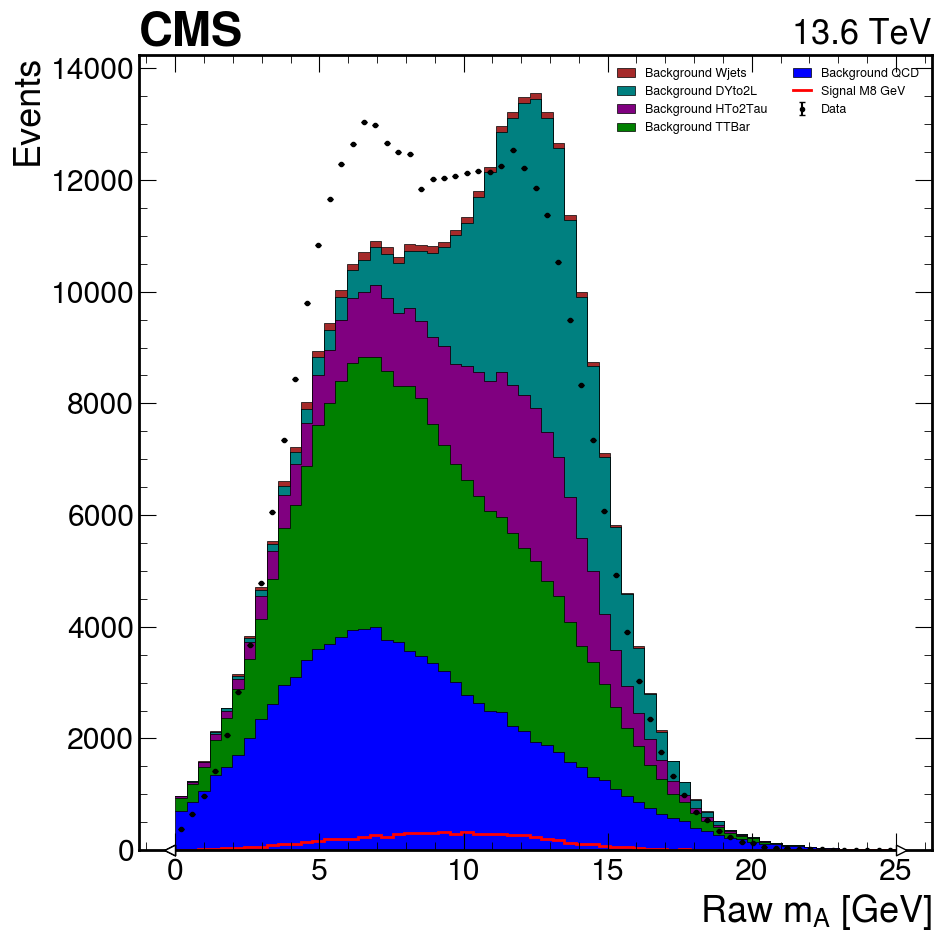

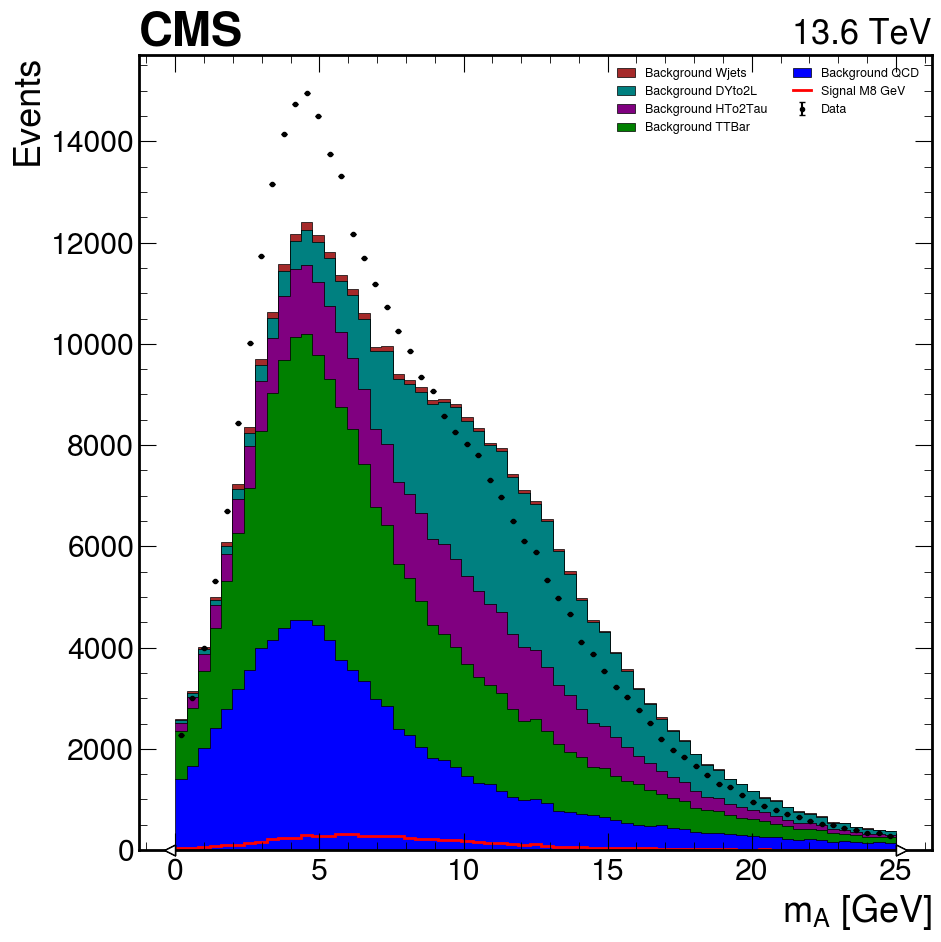

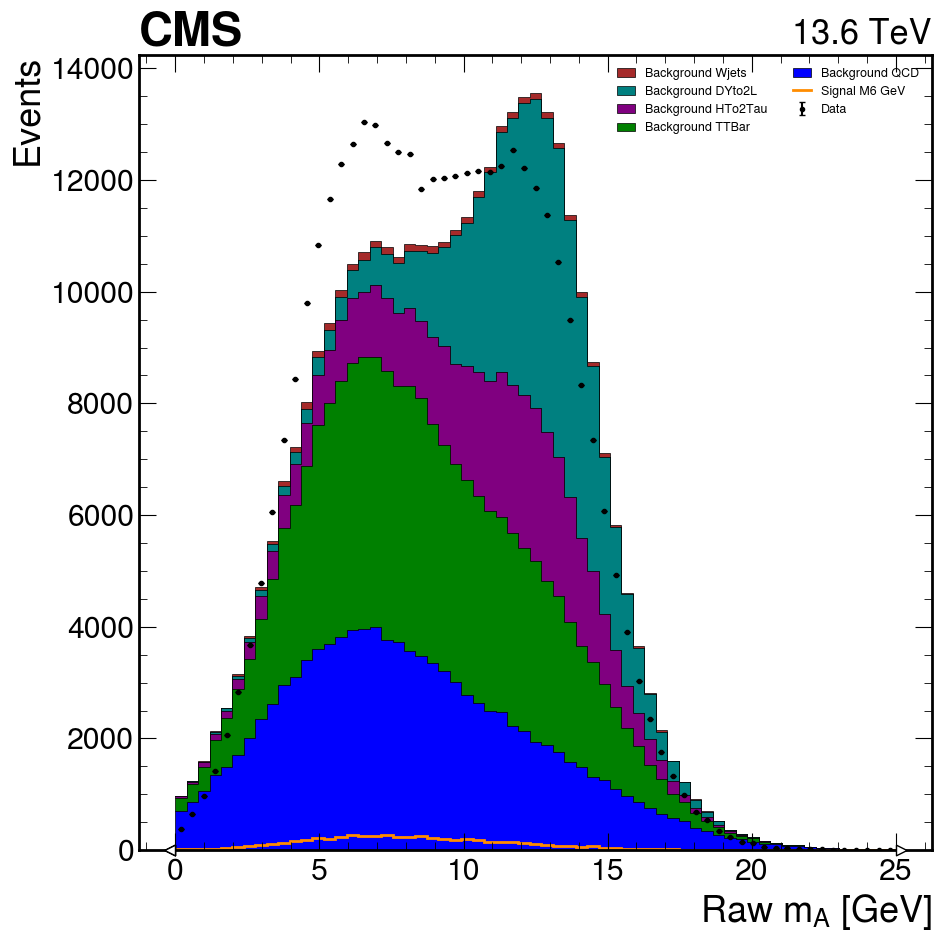

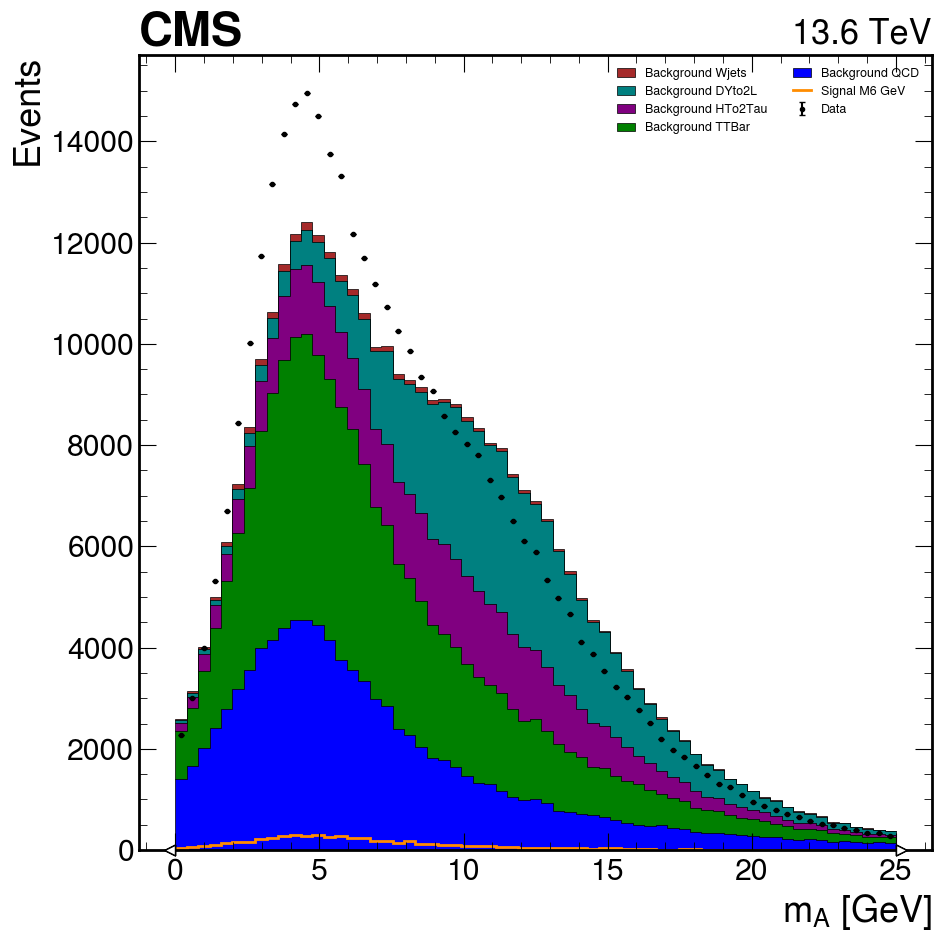

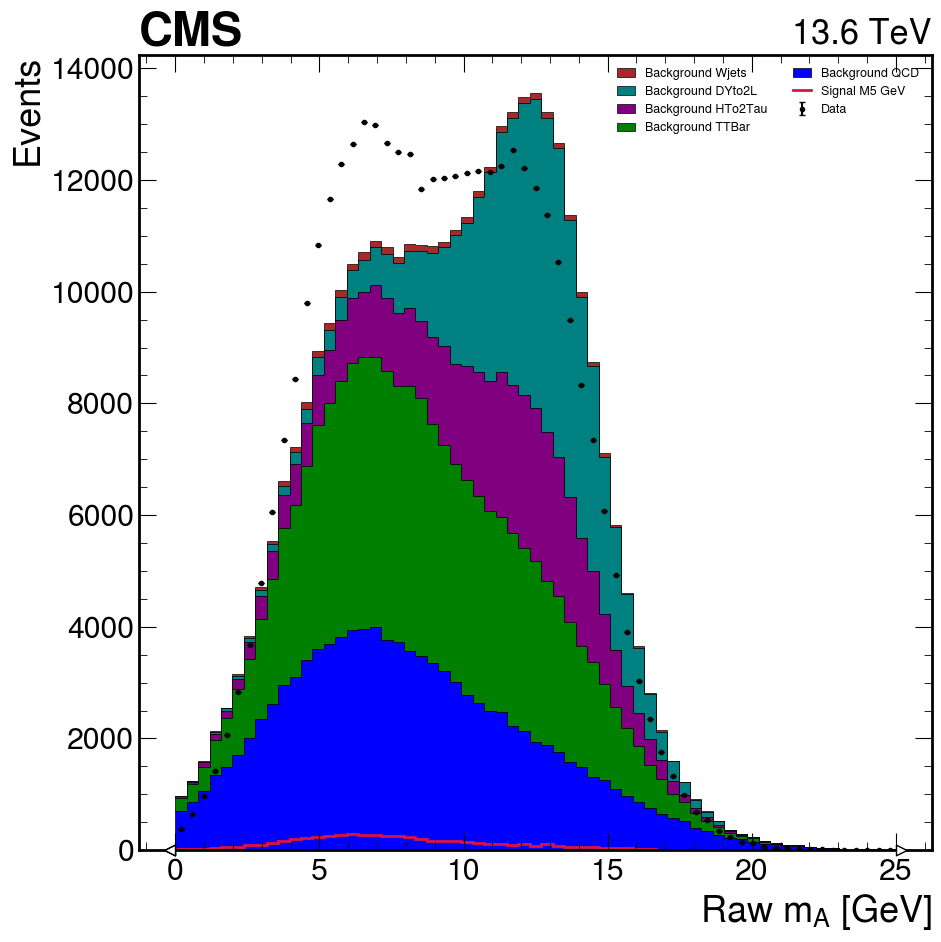

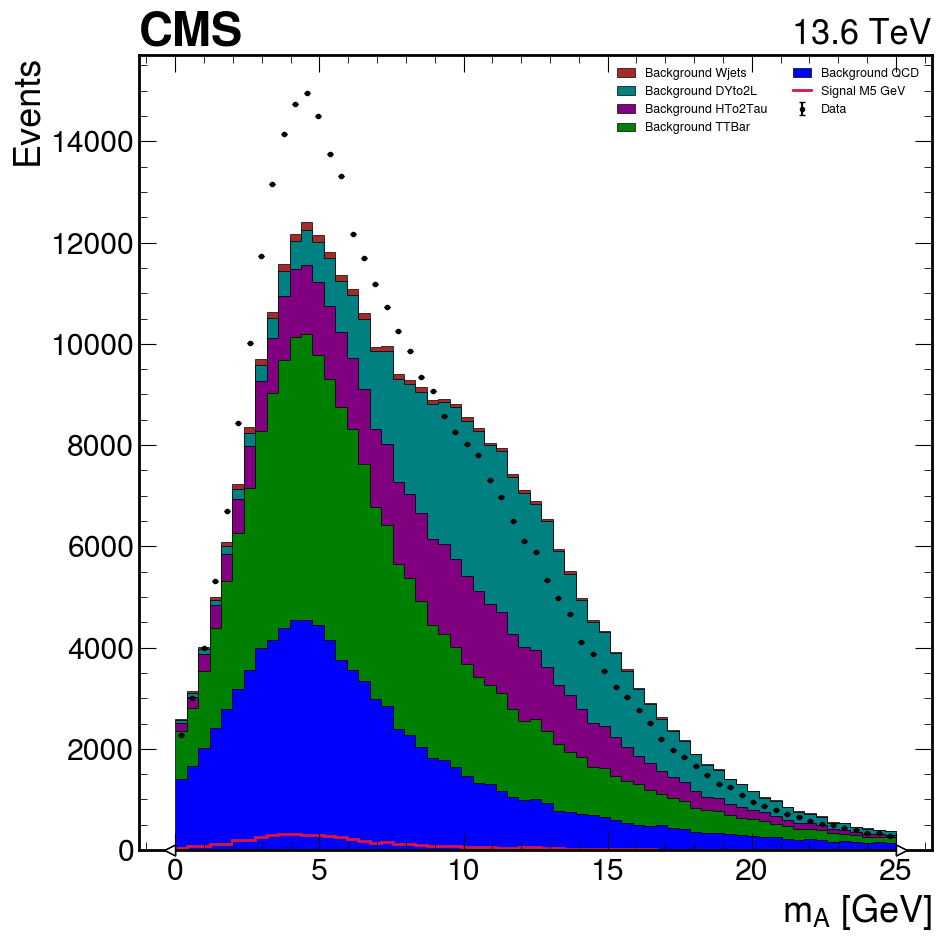

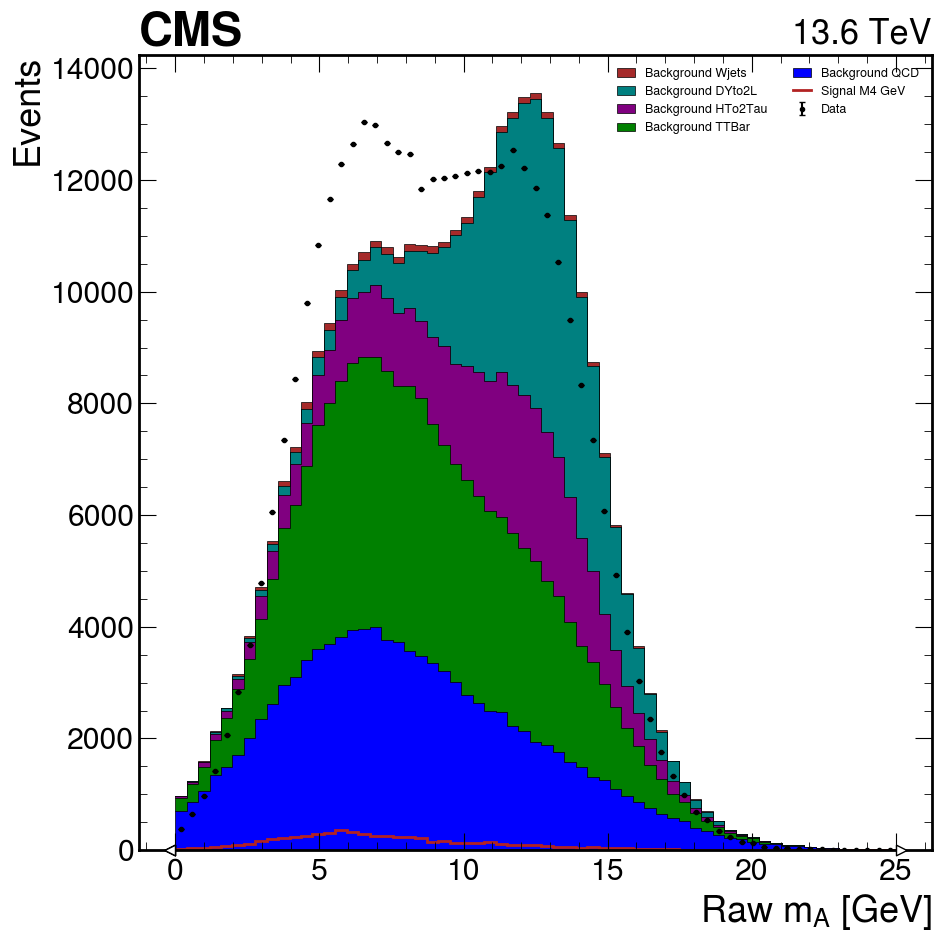

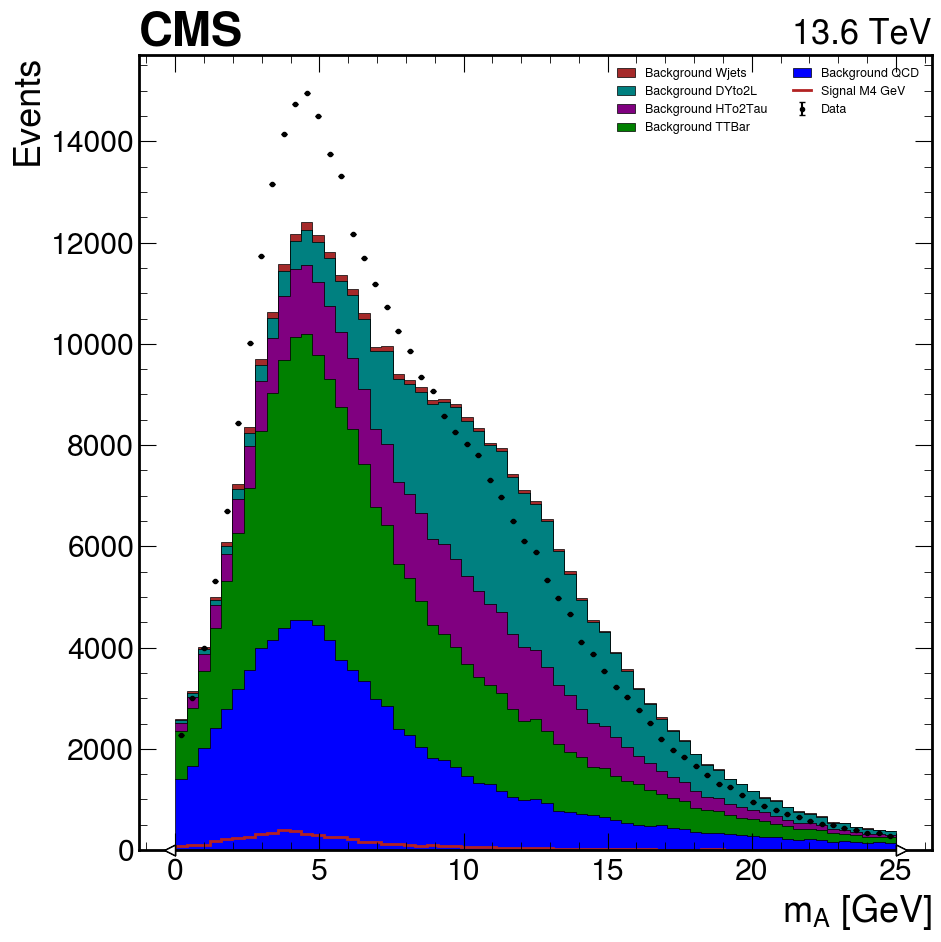

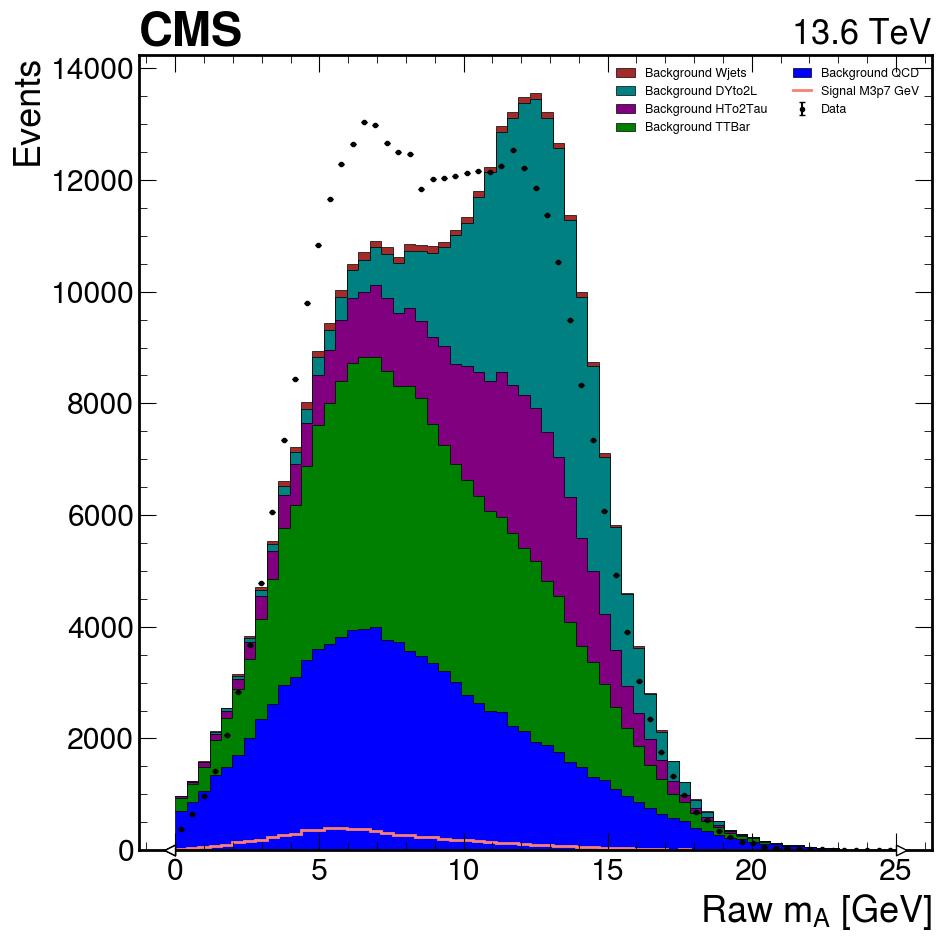

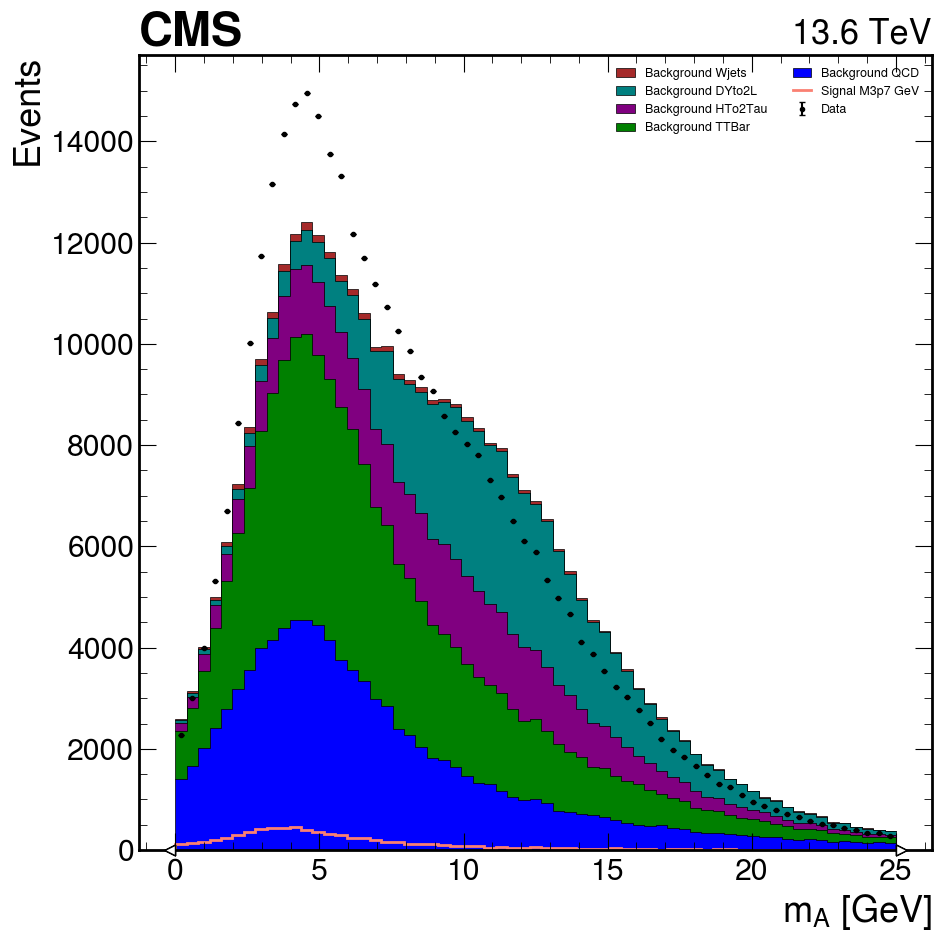

All per-signal Raw/A-mass plots saved under '../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check/'


In [54]:
plt.style.use(hep.style.CMS)
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check"
os.makedirs(outdir, exist_ok=True)

signal_colors = ["red", "darkorange", "crimson", "firebrick", "salmon", "tomato"]
background_colors = ["blue", "green", "purple", "teal", "brown", "magenta"]

def clean_label(name):
    return name.replace("_with_mass_classifier_infernce_miniAOD_June15", "").replace("_", " ")

# Classify datasets
data_keys = [k for k in out if k.startswith("data")]
signal_keys = [k for k in out if k.startswith("Signal")]
background_keys = [k for k in out if k.startswith("Background")]

# Only these two histograms
hist_names = ["mass_A_raw", "mass_A"]

bkg_colors = [background_colors[i % len(background_colors)] for i in range(len(background_keys))]
bkg_labels = [clean_label(k) for k in background_keys]

for sig_i, sig_key in enumerate(signal_keys):
    sig_color = signal_colors[sig_i % len(signal_colors)]
    sig_label = clean_label(sig_key)
    sig_tag = sig_key.replace("_with_mass_classifier_infernce_miniAOD_June15", "")

    for hist_name in hist_names:
        fig, ax = plt.subplots()

        # --- Backgrounds: stacked filled histograms ---
        bkg_hists = [out[k][hist_name] for k in background_keys]
        if bkg_hists:
            hep.histplot(
                bkg_hists,
                ax=ax,
                stack=True,
                histtype="fill",
                color=bkg_colors,
                label=bkg_labels,
                edgecolor="black",
                linewidth=0.5,
            )

        # --- This one signal: step outline, not stacked ---
        out[sig_key][hist_name].plot1d(
            ax=ax,
            histtype="step",
            color=sig_color,
            linewidth=2,
            label=sig_label,
        )

        # --- Data: points with error bars ---
        for k in data_keys:
            out[k][hist_name].plot1d(
                ax=ax,
                histtype="errorbar",
                color="black",
                markersize=6,
                elinewidth=1.5,
                capsize=2,
                label="Data",
            )

        ax.set_ylabel("Events")
        ax.legend(loc="upper right", fontsize=9, ncol=2)
        hep.cms.label(data=bool(data_keys), rlabel="13.6 TeV", ax=ax)

        plt.tight_layout()
        outpath = os.path.join(outdir, f"{sig_tag}_vs_bkg_data_{hist_name}.pdf")
        # plt.savefig(outpath, dpi=300)
        plt.show()
        plt.close(fig)

print(f"All per-signal Raw/A-mass plots saved under '{outdir}/'")